Connected to datasci (Python 3.13.5)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers

"""
....###.....######....######...########..########..######......###....########.########...
...##.##...##....##..##....##..##.....##.##.......##....##....##.##......##....##.........
..##...##..##........##........##.....##.##.......##.........##...##.....##....##.........
.##.....##.##...####.##...####.########..######...##...####.##.....##....##....######.....
.#########.##....##..##....##..##...##...##.......##....##..#########....##....##.........
.##.....##.##....##..##....##..##....##..##.......##....##..##.....##....##....##.........
.##.....##..######....######...##.....##.########..######...##.....##....##....########...
"""
colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"

"""
                                           d8,                         d8b
                           d8P            `8P           d8P            88P              d8P                              d8P
                        d888888P                     d888888P         d88            d888888P                         d888888P
  88bd88b d8888b .d888b,  ?88'    88bd88b  88b d8888b  ?88'       d888888   d888b8b    ?88'   d888b8b   .d888b, d8888b  ?88'
  88P'  `d8b_,dP ?8b,     88P     88P'  `  88Pd8P' `P  88P       d8P' ?88  d8P' ?88    88P   d8P' ?88   ?8b,   d8b_,dP  88P
 d88     88b       `?8b   88b    d88      d88 88b      88b       88b  ,88b 88b  ,88b   88b   88b  ,88b    `?8b 88b      88b
d88'     `?888P'`?888P'   `?8b  d88'     d88' `?888P'  `?8b      `?88P'`88b`?88P'`88b  `?8b  `?88P'`88b`?888P' `?888P'  `?8b



"""

df = pd.read_csv(cohort_file)


#Restrict training level
df = df[(df["training_level"] == 16)]

#Mask ABL 59 to 60dB
mask2 = df["ABL"] == 59
df.loc[mask2, "ABL"] = 60

#Mask lateralized sound as 50dB
mask3 = (df["training_level"] == 16) & (df["ABL"] == 25)
df.loc[mask3, "ABL"] = 50

#Restrict session number
df = df[df["session"]>=13] # restricting session!!

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)

df = df[mask_false]

#Restrict animals, sex, or genotype

"""

df_sel = DataHelpers.restrict_subjects(
    df, "sex_gen.csv",
    sex="female",
    genotypes="het",
    subject_col="animal",      # omit if you want auto-detect
    attach_meta=True
)


df_sel = DataHelpers.restrict_subjects(
    df, "sex_gen.csv",
    sex="female",
    subject_col="animal",      # omit if you want auto-detect
    attach_meta=True
)
"""
# ==== Who contributed? ====

# Overall (after your filtering)
contributors_overall = sorted(df[df["success"] == 1]["animal"].unique())
print(f"Overall contributors ({len(contributors_overall)}):", contributors_overall)

# By ABL (list + counts)
contributors_by_abl = (
    df[df["success"] != 0]
    .groupby("ABL")["animal"]
    .agg(lambda s: sorted(s.unique()))
    .to_dict()
)
print("\nContributors by ABL:")
for abl, subs in contributors_by_abl.items():
    print(f"  ABL {abl} (n={len(subs)}): {subs}")

# By box 
contributors_by_setup = (
    df[df["success"] == 1]
    .groupby(["box"])["animal"]
    .agg(subjects=lambda s: sorted(s.unique()),
         n_subjects=lambda s: s.nunique())
    .reset_index()
)
#print("\nContributors by setup:")
#print(contributors_by_setup.head())


# Step 1: compute RT per subject
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby(["animal", "ABL","ILD"])["timed_rt"]
    .agg(mean_rt="mean")
    .reset_index()
)

# Step 2: aggregate across subjects
meanRT_grouped = (
    meanRT_per_subject
    .groupby(["ABL","ILD"])["mean_rt"]
    .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)))
    .reset_index()
)

# Step 1: compute MT per subject
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby(["animal", "ABL","ILD"])["timed_mt"]
    .agg(mean_mt="mean")
    .reset_index()
)

# Step 2: aggregate across subjects
meanMT_grouped = (
    meanMT_per_subject
    .groupby(["ABL","ILD"])["mean_mt"]
    .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)))
    .reset_index()
)


# Step 1: compute PropRight per subject
all_subject_points = []

for subject, df_subj in df.groupby("animal"):
    
    results = Psychometric.compute_psychometrics_by_ABL(df_subj, model="erf_psycho")

    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_subject_points.append({
                "subject": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

# Step 2: Aggregate     
points_df = pd.DataFrame(all_subject_points)            

agg_points = (
    points_df.groupby(["ABL", "ILD"])["PropLeft"]
    .agg(
        mean="mean",
        sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))   # SEM across subjects
    )
    .reset_index()
)

# Step 3: Group fits

group_fits = {}

for abl in sorted(agg_points["ABL"].unique()):
    sub = agg_points[agg_points["ABL"] == abl]
    ILDs = DataHelpers.shift_ILD_for_ABL50(sub["ILD"]).values
    PropLeft_mean = sub["mean"].values
    n_trials = np.full_like(ILDs, 50)   # dummy n (you can put sum across subjects if you prefer)

    pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
        ILDs, PropLeft_mean,
        model="erf_psycho",
        n_trials=n_trials,
        show_plot=False
    )

    # get fitted curve
    xx = np.linspace(min(ILDs), max(ILDs), 200)
    #yy = Psychometric.predict_psychometric(pars, xx, model="erf_psycho")

    group_fits[abl] = {
        "ILDs": ILDs,
        "mean": PropLeft_mean,
        "sem": sub["sem"].values,
        "xx": xx,
        "yy": yy
    }


#---------- Plotting

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, abl in enumerate(sorted(meanRT_grouped["ABL"].unique())):
    sub = meanRT_grouped[meanRT_grouped["ABL"] == abl]

    axes[0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["sem"],
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )

axes[0].set_xlabel("ILD")
axes[0].set_ylabel("mean RT (s)")
axes[0].set_title("Mean RT (mean ± SEM across subjects)")
axes[0].legend()



for i, abl in enumerate(sorted(meanMT_grouped["ABL"].unique())):
    sub = meanMT_grouped[meanMT_grouped["ABL"] == abl]

    axes[1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["sem"],
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )

axes[1].set_xlabel("ILD")
axes[1].set_ylabel("mean MT (s)")
axes[1].set_title("Mean MT (mean ± SEM across subjects)")


skip_fit = {50}

for i, (abl, res) in enumerate(group_fits.items()):
    # error bars (mean ± SEM)
    axes[2].errorbar(res["ILDs"], res["mean"], yerr=res["sem"],
                fmt="o", color=colors[i], capsize=3, label=f"ABL {abl}")

    # fitted group-level curve
    if abl not in skip_fit and "xx" in res and "yy" in res:
        axes[2].plot(res["xx"], res["yy"], color=colors[i]) 

axes[2].set_xlabel("ILD")
axes[2].set_ylabel("Proportion Rightward")
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].set_title("Psychometric by ABL (mean ± SEM across subjects)")

for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)
 
plt.show()

<ipython-input-1-4ca7b55aa6fa>:37: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)


Overall contributors (14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']

Contributors by ABL:
  ABL 20.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 40.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 50.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 60.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']

ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.

AttributeError: 'numpy.ndarray' object has no attribute 'values'

<ipython-input-2-49ba99b06626>:37: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)


Overall contributors (14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']

Contributors by ABL:
  ABL 20.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 40.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 50.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 60.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']

ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.

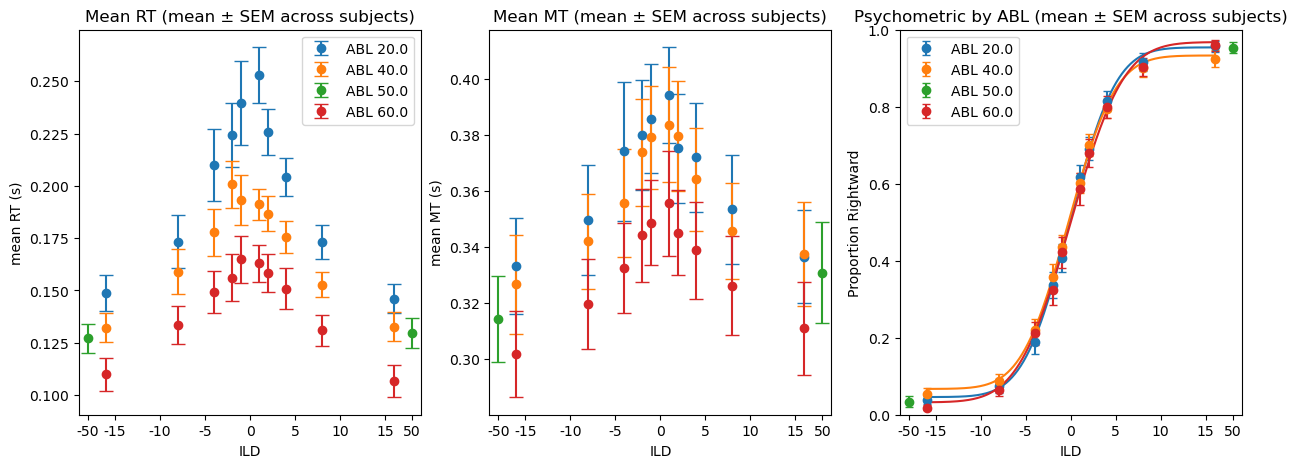

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers

"""
....###.....######....######...########..########..######......###....########.########...
...##.##...##....##..##....##..##.....##.##.......##....##....##.##......##....##.........
..##...##..##........##........##.....##.##.......##.........##...##.....##....##.........
.##.....##.##...####.##...####.########..######...##...####.##.....##....##....######.....
.#########.##....##..##....##..##...##...##.......##....##..#########....##....##.........
.##.....##.##....##..##....##..##....##..##.......##....##..##.....##....##....##.........
.##.....##..######....######...##.....##.########..######...##.....##....##....########...
"""
colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"

"""
                                           d8,                         d8b
                           d8P            `8P           d8P            88P              d8P                              d8P
                        d888888P                     d888888P         d88            d888888P                         d888888P
  88bd88b d8888b .d888b,  ?88'    88bd88b  88b d8888b  ?88'       d888888   d888b8b    ?88'   d888b8b   .d888b, d8888b  ?88'
  88P'  `d8b_,dP ?8b,     88P     88P'  `  88Pd8P' `P  88P       d8P' ?88  d8P' ?88    88P   d8P' ?88   ?8b,   d8b_,dP  88P
 d88     88b       `?8b   88b    d88      d88 88b      88b       88b  ,88b 88b  ,88b   88b   88b  ,88b    `?8b 88b      88b
d88'     `?888P'`?888P'   `?8b  d88'     d88' `?888P'  `?8b      `?88P'`88b`?88P'`88b  `?8b  `?88P'`88b`?888P' `?888P'  `?8b



"""

df = pd.read_csv(cohort_file)


#Restrict training level
df = df[(df["training_level"] == 16)]

#Mask ABL 59 to 60dB
mask2 = df["ABL"] == 59
df.loc[mask2, "ABL"] = 60

#Mask lateralized sound as 50dB
mask3 = (df["training_level"] == 16) & (df["ABL"] == 25)
df.loc[mask3, "ABL"] = 50

#Restrict session number
df = df[df["session"]>=13] # restricting session!!

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)

df = df[mask_false]

#Restrict animals, sex, or genotype

"""

df_sel = DataHelpers.restrict_subjects(
    df, "sex_gen.csv",
    sex="female",
    genotypes="het",
    subject_col="animal",      # omit if you want auto-detect
    attach_meta=True
)


df_sel = DataHelpers.restrict_subjects(
    df, "sex_gen.csv",
    sex="female",
    subject_col="animal",      # omit if you want auto-detect
    attach_meta=True
)
"""
# ==== Who contributed? ====

# Overall (after your filtering)
contributors_overall = sorted(df[df["success"] == 1]["animal"].unique())
print(f"Overall contributors ({len(contributors_overall)}):", contributors_overall)

# By ABL (list + counts)
contributors_by_abl = (
    df[df["success"] != 0]
    .groupby("ABL")["animal"]
    .agg(lambda s: sorted(s.unique()))
    .to_dict()
)
print("\nContributors by ABL:")
for abl, subs in contributors_by_abl.items():
    print(f"  ABL {abl} (n={len(subs)}): {subs}")

# By box 
contributors_by_setup = (
    df[df["success"] == 1]
    .groupby(["box"])["animal"]
    .agg(subjects=lambda s: sorted(s.unique()),
         n_subjects=lambda s: s.nunique())
    .reset_index()
)
#print("\nContributors by setup:")
#print(contributors_by_setup.head())


# Step 1: compute RT per subject
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby(["animal", "ABL","ILD"])["timed_rt"]
    .agg(mean_rt="mean")
    .reset_index()
)

# Step 2: aggregate across subjects
meanRT_grouped = (
    meanRT_per_subject
    .groupby(["ABL","ILD"])["mean_rt"]
    .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)))
    .reset_index()
)

# Step 1: compute MT per subject
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby(["animal", "ABL","ILD"])["timed_mt"]
    .agg(mean_mt="mean")
    .reset_index()
)

# Step 2: aggregate across subjects
meanMT_grouped = (
    meanMT_per_subject
    .groupby(["ABL","ILD"])["mean_mt"]
    .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)))
    .reset_index()
)


# Step 1: compute PropRight per subject
all_subject_points = []

for subject, df_subj in df.groupby("animal"):
    
    results = Psychometric.compute_psychometrics_by_ABL(df_subj, model="erf_psycho")

    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_subject_points.append({
                "subject": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

# Step 2: Aggregate     
points_df = pd.DataFrame(all_subject_points)            

agg_points = (
    points_df.groupby(["ABL", "ILD"])["PropLeft"]
    .agg(
        mean="mean",
        sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))   # SEM across subjects
    )
    .reset_index()
)

# Step 3: Group fits

group_fits = {}

for abl in sorted(agg_points["ABL"].unique()):
    sub = agg_points[agg_points["ABL"] == abl]
    ILDs = DataHelpers.shift_ILD_for_ABL50(sub["ILD"])
    PropLeft_mean = sub["mean"].values
    n_trials = np.full_like(ILDs, 50)   # dummy n (you can put sum across subjects if you prefer)

    pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
        ILDs, PropLeft_mean,
        model="erf_psycho",
        n_trials=n_trials,
        show_plot=False
    )

    # get fitted curve
    xx = np.linspace(min(ILDs), max(ILDs), 200)
    #yy = Psychometric.predict_psychometric(pars, xx, model="erf_psycho")

    group_fits[abl] = {
        "ILDs": ILDs,
        "mean": PropLeft_mean,
        "sem": sub["sem"].values,
        "xx": xx,
        "yy": yy
    }


#---------- Plotting

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, abl in enumerate(sorted(meanRT_grouped["ABL"].unique())):
    sub = meanRT_grouped[meanRT_grouped["ABL"] == abl]

    axes[0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["sem"],
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )

axes[0].set_xlabel("ILD")
axes[0].set_ylabel("mean RT (s)")
axes[0].set_title("Mean RT (mean ± SEM across subjects)")
axes[0].legend()



for i, abl in enumerate(sorted(meanMT_grouped["ABL"].unique())):
    sub = meanMT_grouped[meanMT_grouped["ABL"] == abl]

    axes[1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["sem"],
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )

axes[1].set_xlabel("ILD")
axes[1].set_ylabel("mean MT (s)")
axes[1].set_title("Mean MT (mean ± SEM across subjects)")


skip_fit = {50}

for i, (abl, res) in enumerate(group_fits.items()):
    # error bars (mean ± SEM)
    axes[2].errorbar(res["ILDs"], res["mean"], yerr=res["sem"],
                fmt="o", color=colors[i], capsize=3, label=f"ABL {abl}")

    # fitted group-level curve
    if abl not in skip_fit and "xx" in res and "yy" in res:
        axes[2].plot(res["xx"], res["yy"], color=colors[i]) 

axes[2].set_xlabel("ILD")
axes[2].set_ylabel("Proportion Rightward")
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].set_title("Psychometric by ABL (mean ± SEM across subjects)")

for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)
 
plt.show()

<ipython-input-3-08b33c90da39>:49: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

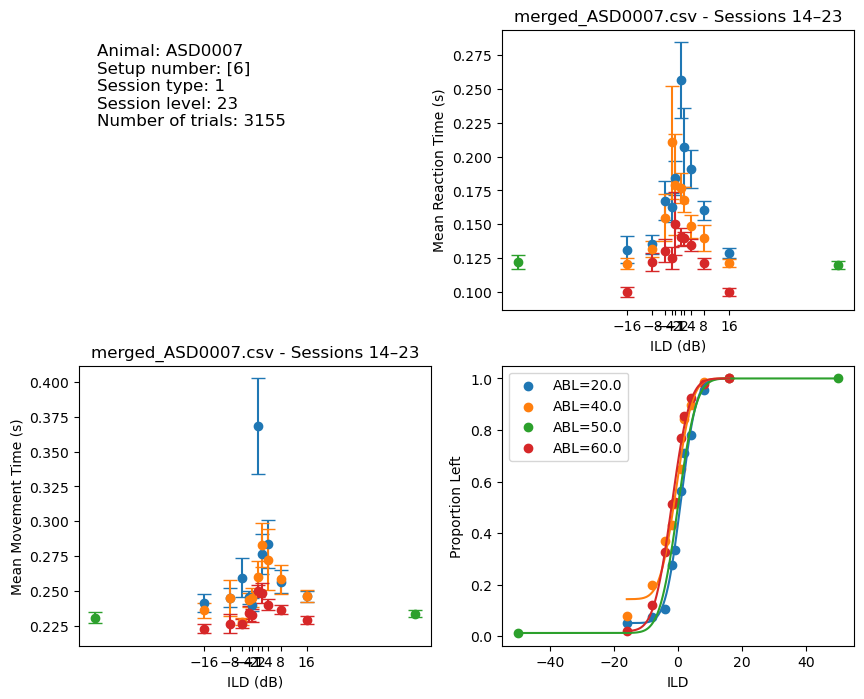

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers

"""
.########..########.########.....########.....###....########
.##.....##.##.......##.....##....##.....##...##.##......##...
.##.....##.##.......##.....##....##.....##..##...##.....##...
.########..######...########.....########..##.....##....##...
.##........##.......##...##......##...##...#########....##...
.##........##.......##....##.....##....##..##.....##....##...
.##........########.##.....##....##.....##.##.....##....##...
"""


colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# keep in mind level is commented

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P
"""
df = pd.read_csv(subject_file)
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2


#Restrict training level
df = df[(df["training_level"] == 16)]

#Mask ABL 59 to 60dB
mask2 = df["ABL"] == 59
df.loc[mask2, "ABL"] = 60

#Mask lateralized sound as 50dB
mask3 = (df["training_level"] == 16) & (df["ABL"] == 25)
df.loc[mask3, "ABL"] = 50

#Restrict session number
df = df[df["session"]>=13] # restricting session!!

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)

df = df[mask_false]

# --- Prep session(s) data

df_last,last_sessions = DataHelpers.get_last_n_sessions(df, 33)
#df_last = df_last[df_last["training_level"] == 16]

n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]   # example, adapt to your df
session_number = df_last["session"].max()

setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# --- RT
meanRT = (
df_last[df_last["success"] == 1]        # keep only successful trials
.groupby(["ABL", "ILD"])["timed_rt"]
.agg(["mean", "std", "count"])
.reset_index()
)

# --- MT
meanMT = (
df_last[df_last["success"] == 1]        # keep only successful trials
.groupby(["ABL", "ILD"])["timed_mt"]
.agg(["mean", "std", "count"])
.reset_index()
)

# --- Psychometric
results = Psychometric.compute_psychometrics_by_ABL(df_last)

# --- Plotting
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax_text = axes[0,0] # pick one axes for text (index 1 - info)
ax_text.axis("off")  # clear axis so no ticks/grid

info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(0.05, 0.95, info, fontsize=12, va="top")

# First panel (index 1 - RT)

for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]

    axes[0,1].errorbar(
        sub["ILD"], sub["mean"],
        yerr=sub["std"] / sub["count"]**0.5,  # SEM = std / sqrt(n)
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )
axes[0,1].set_xlabel("ILD (dB)")
axes[0,1].set_ylabel("Mean Reaction Time (s)")
axes[0,1].set_title(f"{os.path.basename(subject_file)} - Sessions {last_sessions[0]}–{last_sessions[-1]}")
axes[0,1].set_xticks([-16, -8, -4, -2, -1, 1, 2,4,8, 16])

# Second panel (index 2 - MT)
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]

    axes[1,0].errorbar(
        sub["ILD"], sub["mean"],
        yerr=sub["std"] / sub["count"]**0.5,  # SEM = std / sqrt(n)
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )
axes[1,0].set_xlabel("ILD (dB)")
axes[1,0].set_ylabel("Mean Movement Time (s)")
axes[1,0].set_title(f"{os.path.basename(subject_file)} - Sessions {last_sessions[0]}–{last_sessions[-1]}")
axes[1,0].set_xticks([-16, -8, -4, -2, -1, 1, 2,4,8, 16])

# Third panel (index 3 - Psychometric by ABL)

for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(res["ILDs"], res["PropLeft"], label=f"ABL={abl}", color=color)
    axes[1,1].plot(res["xx"], res["yy"], color=color)

axes[1,1].set_xlabel("ILD")
axes[1,1].set_ylabel("Proportion Left")
axes[1,1].legend()
plt.show()

<ipython-input-4-3eeb02a9fc5e>:49: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

AttributeError: 'numpy.ndarray' object has no attribute 'errorbar'

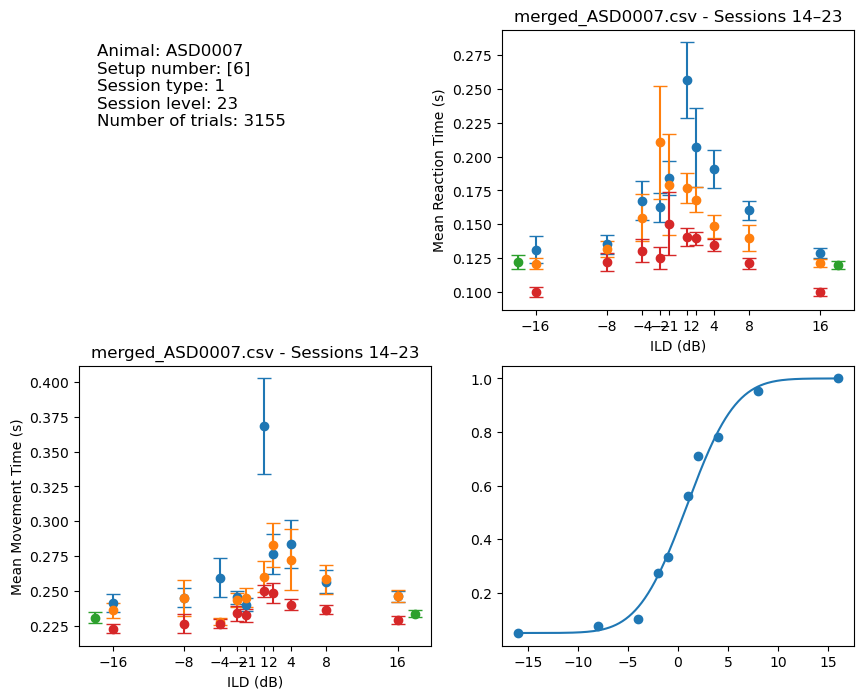

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers

"""
.########..########.########.....########.....###....########
.##.....##.##.......##.....##....##.....##...##.##......##...
.##.....##.##.......##.....##....##.....##..##...##.....##...
.########..######...########.....########..##.....##....##...
.##........##.......##...##......##...##...#########....##...
.##........##.......##....##.....##....##..##.....##....##...
.##........########.##.....##....##.....##.##.....##....##...
"""


colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# keep in mind level is commented

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P
"""
df = pd.read_csv(subject_file)
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2


#Restrict training level
df = df[(df["training_level"] == 16)]

#Mask ABL 59 to 60dB
mask2 = df["ABL"] == 59
df.loc[mask2, "ABL"] = 60

#Mask lateralized sound as 50dB
mask3 = (df["training_level"] == 16) & (df["ABL"] == 25)
df.loc[mask3, "ABL"] = 50

#Restrict session number
df = df[df["session"]>=13] # restricting session!!

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)

df = df[mask_false]

# --- Prep session(s) data

df_last,last_sessions = DataHelpers.get_last_n_sessions(df, 33)
#df_last = df_last[df_last["training_level"] == 16]

n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]   # example, adapt to your df
session_number = df_last["session"].max()

setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# --- RT
meanRT = (
df_last[df_last["success"] == 1]        # keep only successful trials
.groupby(["ABL", "ILD"])["timed_rt"]
.agg(["mean", "std", "count"])
.reset_index()
)

# --- MT
meanMT = (
df_last[df_last["success"] == 1]        # keep only successful trials
.groupby(["ABL", "ILD"])["timed_mt"]
.agg(["mean", "std", "count"])
.reset_index()
)

# --- Psychometric
results = Psychometric.compute_psychometrics_by_ABL(df_last)

# --- Plotting
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax_text = axes[0,0] # pick one axes for text (index 1 - info)
ax_text.axis("off")  # clear axis so no ticks/grid

info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(0.05, 0.95, info, fontsize=12, va="top")

# First panel (index 1 - RT)

for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]

    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / sub["count"]**0.5,  # SEM = std / sqrt(n)
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )
axes[0,1].set_xlabel("ILD (dB)")
axes[0,1].set_ylabel("Mean Reaction Time (s)")
axes[0,1].set_title(f"{os.path.basename(subject_file)} - Sessions {last_sessions[0]}–{last_sessions[-1]}")
axes[0,1].set_xticks([-16, -8, -4, -2, -1, 1, 2,4,8, 16])

# Second panel (index 2 - MT)
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]

    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / sub["count"]**0.5,  # SEM = std / sqrt(n)
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )
axes[1,0].set_xlabel("ILD (dB)")
axes[1,0].set_ylabel("Mean Movement Time (s)")
axes[1,0].set_title(f"{os.path.basename(subject_file)} - Sessions {last_sessions[0]}–{last_sessions[-1]}")
axes[1,0].set_xticks([-16, -8, -4, -2, -1, 1, 2,4,8, 16])

# Third panel (index 3 - Psychometric by ABL)

for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(res["ILDs"], res["PropLeft"], label=f"ABL={abl}", color=color)
    axes[1,1].plot(res["xx"], res["yy"], color=color)

    axes[0].errorbar(
    DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
    yerr=sub["sem"],
    label=f"ABL {abl}",
    color=colors[i % len(colors)],
    linestyle="none",
    marker="o", capsize=5
)


axes[1,1].set_xlabel("ILD")
axes[1,1].set_ylabel("Proportion Left")
axes[1,1].legend()
plt.show()

<ipython-input-5-b2e968810388>:49: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

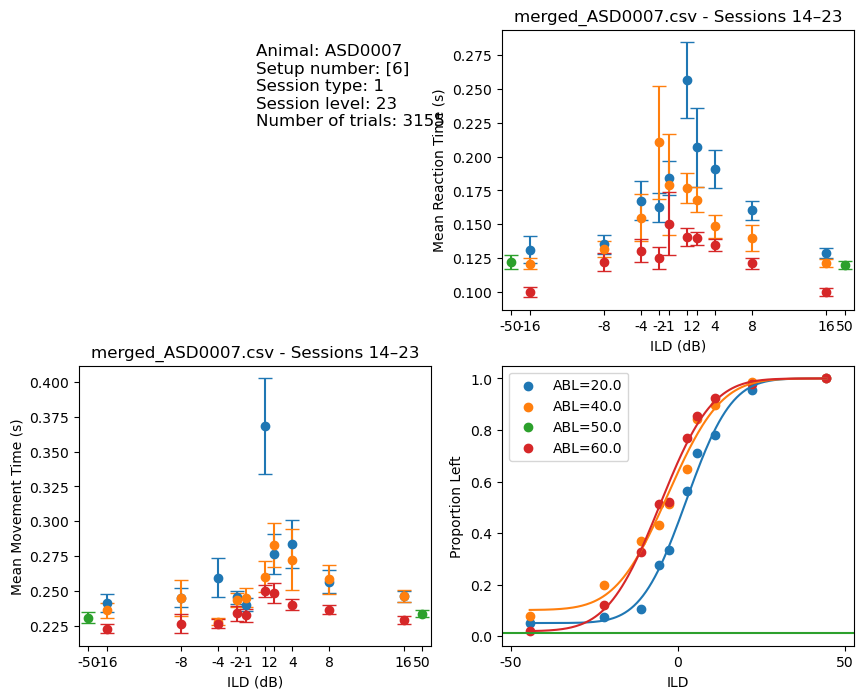

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers

"""
.########..########.########.....########.....###....########
.##.....##.##.......##.....##....##.....##...##.##......##...
.##.....##.##.......##.....##....##.....##..##...##.....##...
.########..######...########.....########..##.....##....##...
.##........##.......##...##......##...##...#########....##...
.##........##.......##....##.....##....##..##.....##....##...
.##........########.##.....##....##.....##.##.....##....##...
"""


colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# keep in mind level is commented

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P
"""
df = pd.read_csv(subject_file)
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2


#Restrict training level
df = df[(df["training_level"] == 16)]

#Mask ABL 59 to 60dB
mask2 = df["ABL"] == 59
df.loc[mask2, "ABL"] = 60

#Mask lateralized sound as 50dB
mask3 = (df["training_level"] == 16) & (df["ABL"] == 25)
df.loc[mask3, "ABL"] = 50

#Restrict session number
df = df[df["session"]>=13] # restricting session!!

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)

df = df[mask_false]

# --- Prep session(s) data

df_last,last_sessions = DataHelpers.get_last_n_sessions(df, 33)
#df_last = df_last[df_last["training_level"] == 16]

n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]   # example, adapt to your df
session_number = df_last["session"].max()

setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# --- RT
meanRT = (
df_last[df_last["success"] == 1]        # keep only successful trials
.groupby(["ABL", "ILD"])["timed_rt"]
.agg(["mean", "std", "count"])
.reset_index()
)

# --- MT
meanMT = (
df_last[df_last["success"] == 1]        # keep only successful trials
.groupby(["ABL", "ILD"])["timed_mt"]
.agg(["mean", "std", "count"])
.reset_index()
)

# --- Psychometric
results = Psychometric.compute_psychometrics_by_ABL(df_last)

# --- Plotting
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax_text = axes[0,0] # pick one axes for text (index 1 - info)
ax_text.axis("off")  # clear axis so no ticks/grid

info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(0.05, 0.95, info, fontsize=12, va="top")

# First panel (index 1 - RT)

for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]

    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / sub["count"]**0.5,  # SEM = std / sqrt(n)
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )
axes[0,1].set_xlabel("ILD (dB)")
axes[0,1].set_ylabel("Mean Reaction Time (s)")
axes[0,1].set_title(f"{os.path.basename(subject_file)} - Sessions {last_sessions[0]}–{last_sessions[-1]}")
axes[0,1].set_xticks([-16, -8, -4, -2, -1, 1, 2,4,8, 16])

# Second panel (index 2 - MT)
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]

    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / sub["count"]**0.5,  # SEM = std / sqrt(n)
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )
axes[1,0].set_xlabel("ILD (dB)")
axes[1,0].set_ylabel("Mean Movement Time (s)")
axes[1,0].set_title(f"{os.path.basename(subject_file)} - Sessions {last_sessions[0]}–{last_sessions[-1]}")
axes[1,0].set_xticks([-16, -8, -4, -2, -1, 1, 2,4,8, 16])

# Third panel (index 3 - Psychometric by ABL)

for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(res["ILDs"], res["PropLeft"], label=f"ABL={abl}", color=color)
    axes[1,1].plot(res["xx"], res["yy"], color=color)


for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)


axes[1,1].set_xlabel("ILD")
axes[1,1].set_ylabel("Proportion Left")
axes[1,1].legend()
plt.show()

In [ ]:
print(sorted(df["ILD"].unique()))

[np.float64(-50.0), np.float64(-16.0), np.float64(-8.0), np.float64(-4.0), np.float64(-2.0), np.float64(-1.0), np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(50.0)]


In [ ]:
for abl, res in results.items():
    print(f"\nABL {abl}")
    print("ILDs in result:", res["ILDs"])


ABL 20.0
ILDs in result: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]

ABL 40.0
ILDs in result: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]

ABL 50.0
ILDs in result: [-50.  50.]

ABL 60.0
ILDs in result: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]


<ipython-input-8-342482602b01>:66: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

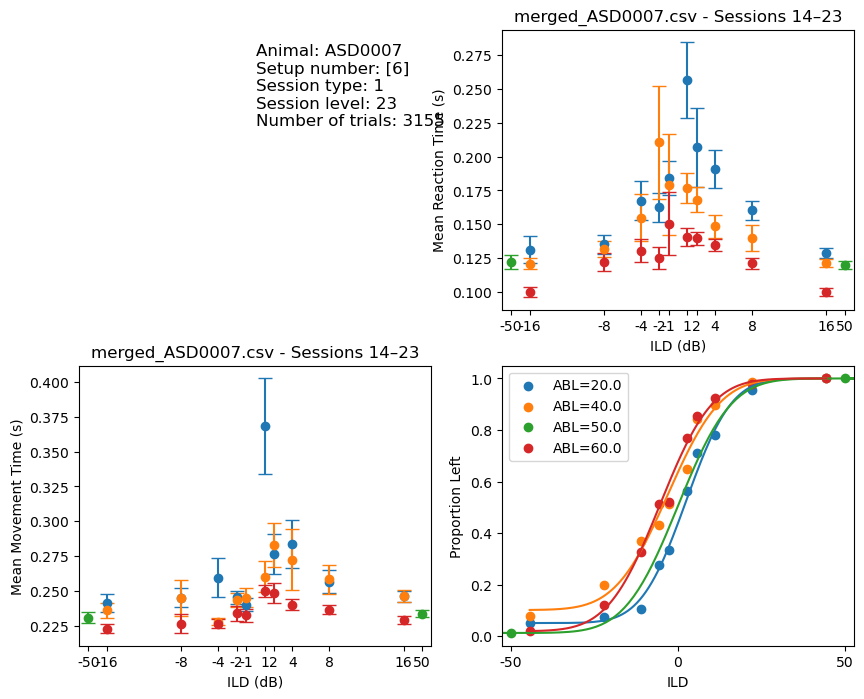

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers

def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, fontsize=20, pad=16)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=16, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=16, color="black")
    ax.tick_params(axis="both", which="major", labelsize=14,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_box_aspect(1)


"""
.########..########.########.....########.....###....########
.##.....##.##.......##.....##....##.....##...##.##......##...
.##.....##.##.......##.....##....##.....##..##...##.....##...
.########..######...########.....########..##.....##....##...
.##........##.......##...##......##...##...#########....##...
.##........##.......##....##.....##....##..##.....##....##...
.##........########.##.....##....##.....##.##.....##....##...
"""


colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# keep in mind level is commented

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P
"""
df = pd.read_csv(subject_file)
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2


#Restrict training level
df = df[(df["training_level"] == 16)]

#Mask ABL 59 to 60dB
mask2 = df["ABL"] == 59
df.loc[mask2, "ABL"] = 60

#Mask lateralized sound as 50dB
mask3 = (df["training_level"] == 16) & (df["ABL"] == 25)
df.loc[mask3, "ABL"] = 50

#Restrict session number
df = df[df["session"]>=13] # restricting session!!

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)

df = df[mask_false]

# --- Prep session(s) data

df_last,last_sessions = DataHelpers.get_last_n_sessions(df, 33)
#df_last = df_last[df_last["training_level"] == 16]

n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]   # example, adapt to your df
session_number = df_last["session"].max()

setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# --- RT
meanRT = (
df_last[df_last["success"] == 1]        # keep only successful trials
.groupby(["ABL", "ILD"])["timed_rt"]
.agg(["mean", "std", "count"])
.reset_index()
)

# --- MT
meanMT = (
df_last[df_last["success"] == 1]        # keep only successful trials
.groupby(["ABL", "ILD"])["timed_mt"]
.agg(["mean", "std", "count"])
.reset_index()
)

# --- Psychometric
results = Psychometric.compute_psychometrics_by_ABL(df_last)

# --- Plotting
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax_text = axes[0,0] # pick one axes for text (index 1 - info)
ax_text.axis("off")  # clear axis so no ticks/grid

info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(0.05, 0.95, info, fontsize=12, va="top")

# First panel (index 1 - RT)

for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]

    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / sub["count"]**0.5,  # SEM = std / sqrt(n)
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )
axes[0,1].set_xlabel("ILD (dB)")
axes[0,1].set_ylabel("Mean Reaction Time (s)")
axes[0,1].set_title(f"{os.path.basename(subject_file)} - Sessions {last_sessions[0]}–{last_sessions[-1]}")
axes[0,1].set_xticks([-16, -8, -4, -2, -1, 1, 2,4,8, 16])

# Second panel (index 2 - MT)
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]

    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / sub["count"]**0.5,  # SEM = std / sqrt(n)
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )
axes[1,0].set_xlabel("ILD (dB)")
axes[1,0].set_ylabel("Mean Movement Time (s)")
axes[1,0].set_title(f"{os.path.basename(subject_file)} - Sessions {last_sessions[0]}–{last_sessions[-1]}")
axes[1,0].set_xticks([-16, -8, -4, -2, -1, 1, 2,4,8, 16])

# Third panel (index 3 - Psychometric by ABL)

for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
    DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
    res["PropLeft"],
    label=f"ABL={abl}",
    color=color
    )

    axes[1,1].plot(
        DataHelpers.shift_ILD_for_ABL50(res["xx"]),
        res["yy"],
        color=color
    )



for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)


axes[1,1].set_xlabel("ILD")
axes[1,1].set_ylabel("Proportion Left")
axes[1,1].legend()
plt.show()

<ipython-input-9-2de43e4d54e8>:66: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

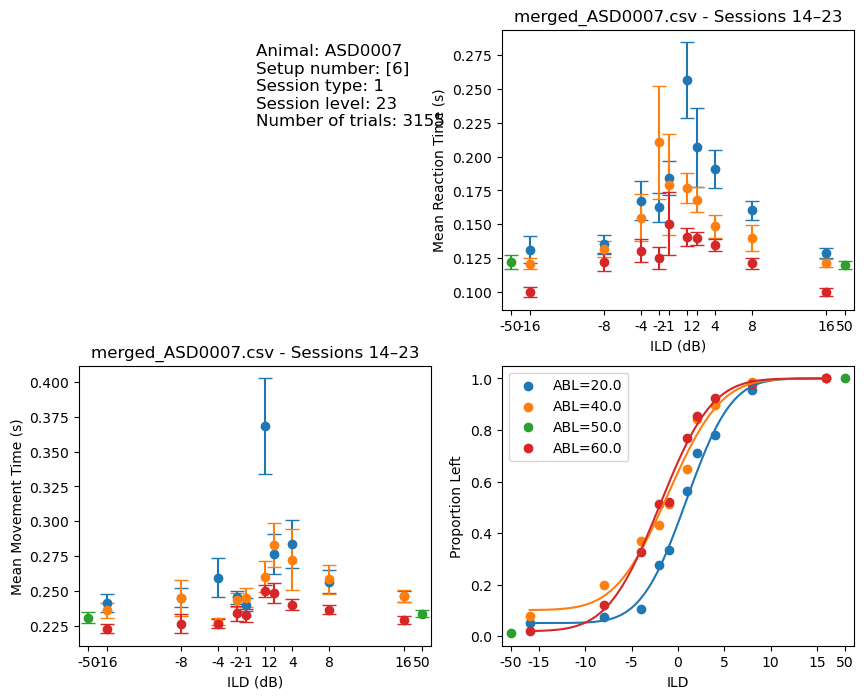

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers

def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, fontsize=20, pad=16)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=16, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=16, color="black")
    ax.tick_params(axis="both", which="major", labelsize=14,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_box_aspect(1)


"""
.########..########.########.....########.....###....########
.##.....##.##.......##.....##....##.....##...##.##......##...
.##.....##.##.......##.....##....##.....##..##...##.....##...
.########..######...########.....########..##.....##....##...
.##........##.......##...##......##...##...#########....##...
.##........##.......##....##.....##....##..##.....##....##...
.##........########.##.....##....##.....##.##.....##....##...
"""


colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# keep in mind level is commented

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P
"""
df = pd.read_csv(subject_file)
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2


#Restrict training level
df = df[(df["training_level"] == 16)]

#Mask ABL 59 to 60dB
mask2 = df["ABL"] == 59
df.loc[mask2, "ABL"] = 60

#Mask lateralized sound as 50dB
mask3 = (df["training_level"] == 16) & (df["ABL"] == 25)
df.loc[mask3, "ABL"] = 50

#Restrict session number
df = df[df["session"]>=13] # restricting session!!

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)

df = df[mask_false]

# --- Prep session(s) data

df_last,last_sessions = DataHelpers.get_last_n_sessions(df, 33)
#df_last = df_last[df_last["training_level"] == 16]

n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]   # example, adapt to your df
session_number = df_last["session"].max()

setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# --- RT
meanRT = (
df_last[df_last["success"] == 1]        # keep only successful trials
.groupby(["ABL", "ILD"])["timed_rt"]
.agg(["mean", "std", "count"])
.reset_index()
)

# --- MT
meanMT = (
df_last[df_last["success"] == 1]        # keep only successful trials
.groupby(["ABL", "ILD"])["timed_mt"]
.agg(["mean", "std", "count"])
.reset_index()
)

# --- Psychometric
results = Psychometric.compute_psychometrics_by_ABL(df_last)

# --- Plotting
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax_text = axes[0,0] # pick one axes for text (index 1 - info)
ax_text.axis("off")  # clear axis so no ticks/grid

info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(0.05, 0.95, info, fontsize=12, va="top")

# First panel (index 1 - RT)

for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]

    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / sub["count"]**0.5,  # SEM = std / sqrt(n)
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )
axes[0,1].set_xlabel("ILD (dB)")
axes[0,1].set_ylabel("Mean Reaction Time (s)")
axes[0,1].set_title(f"{os.path.basename(subject_file)} - Sessions {last_sessions[0]}–{last_sessions[-1]}")
axes[0,1].set_xticks([-16, -8, -4, -2, -1, 1, 2,4,8, 16])

# Second panel (index 2 - MT)
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]

    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / sub["count"]**0.5,  # SEM = std / sqrt(n)
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none",
        marker="o", capsize=5
    )
axes[1,0].set_xlabel("ILD (dB)")
axes[1,0].set_ylabel("Mean Movement Time (s)")
axes[1,0].set_title(f"{os.path.basename(subject_file)} - Sessions {last_sessions[0]}–{last_sessions[-1]}")
axes[1,0].set_xticks([-16, -8, -4, -2, -1, 1, 2,4,8, 16])

# Third panel (index 3 - Psychometric by ABL)

for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
    DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
    res["PropLeft"],
    label=f"ABL={abl}",
    color=color
    )

    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color
        )



for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)


axes[1,1].set_xlabel("ILD")
axes[1,1].set_ylabel("Proportion Left")
axes[1,1].legend()
plt.show()

<ipython-input-10-77ada45a2bd4>:94: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

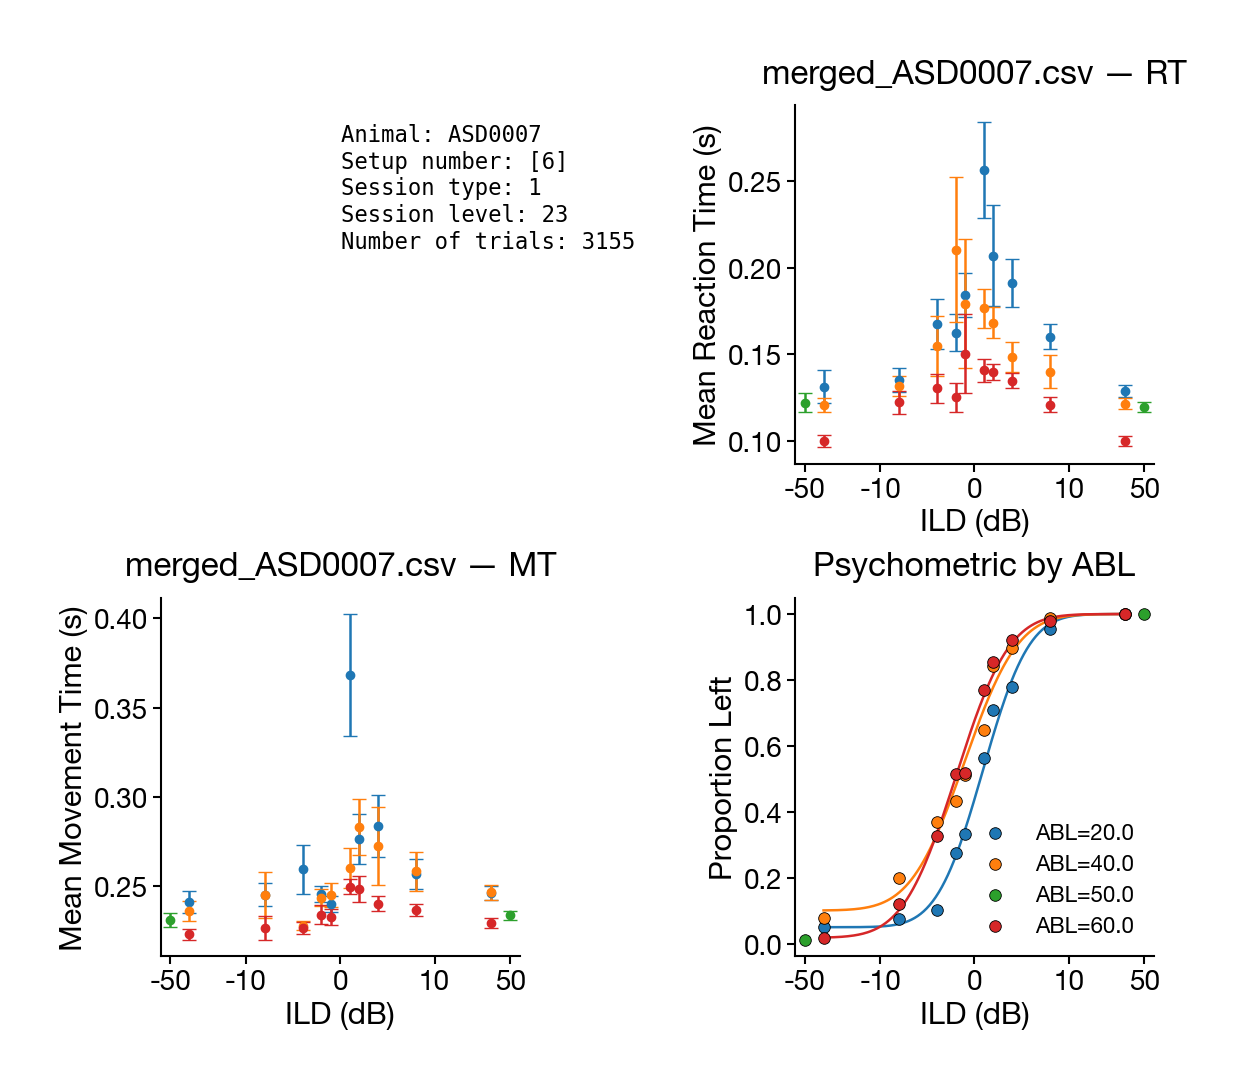

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)
n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]
session_number = df_last["session"].max()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(0.05, 0.95, info, fontsize=16, va="top", family="monospace")

# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title=f"{os.path.basename(subject_file)} — RT",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title=f"{os.path.basename(subject_file)} — MT",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-11-f624b9a02cfb>:94: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

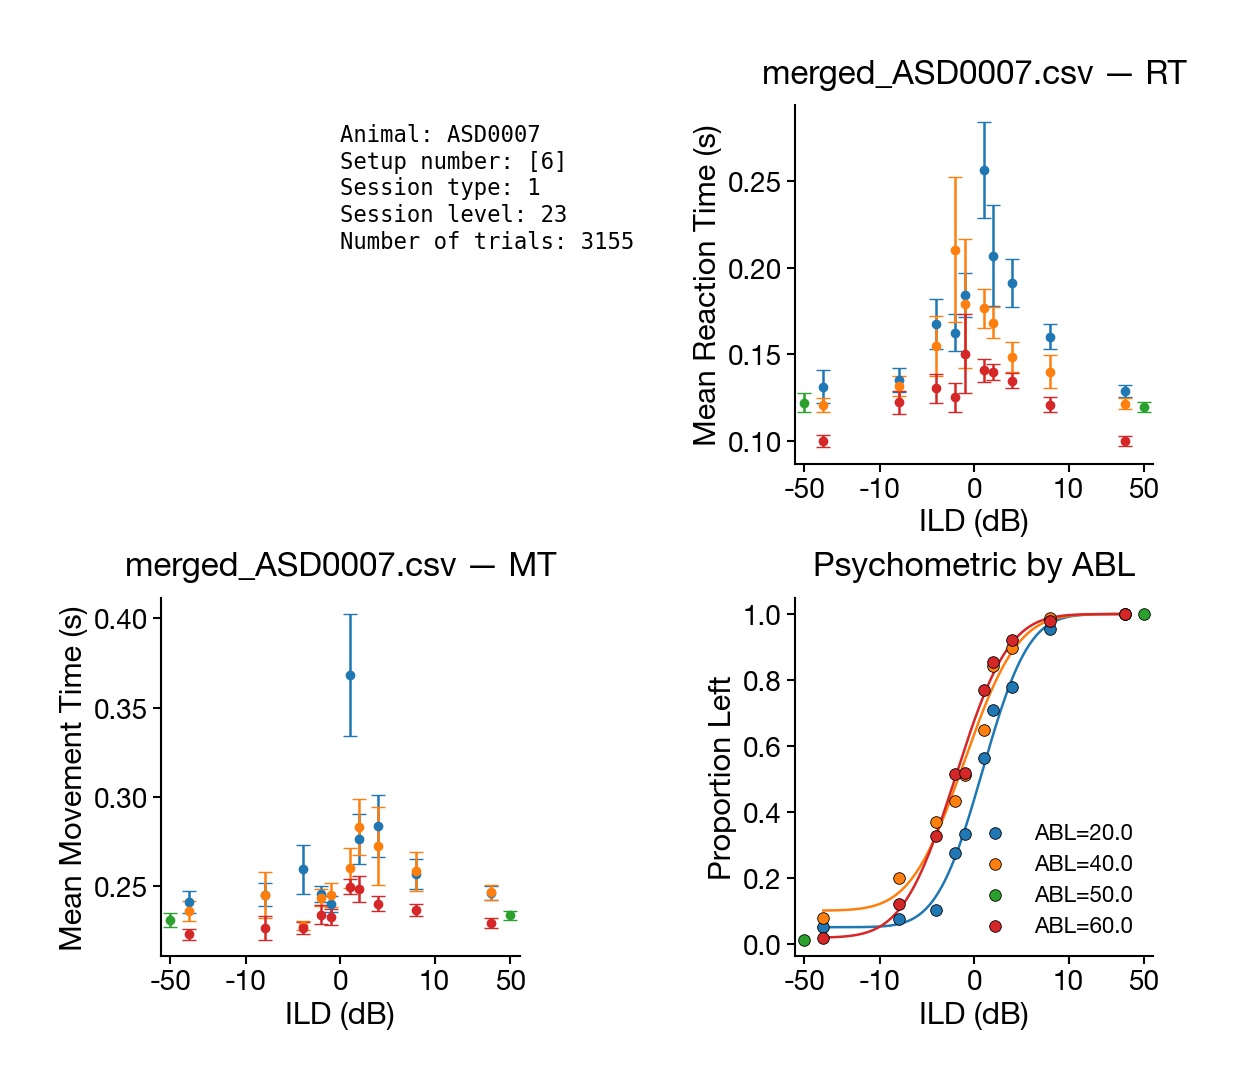

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)
n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]
session_number = df_last["session"].max()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(0, 0.95, info, fontsize=16, va="top", family="monospace")

# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title=f"{os.path.basename(subject_file)} — RT",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title=f"{os.path.basename(subject_file)} — MT",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-12-1563a5310be6>:94: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

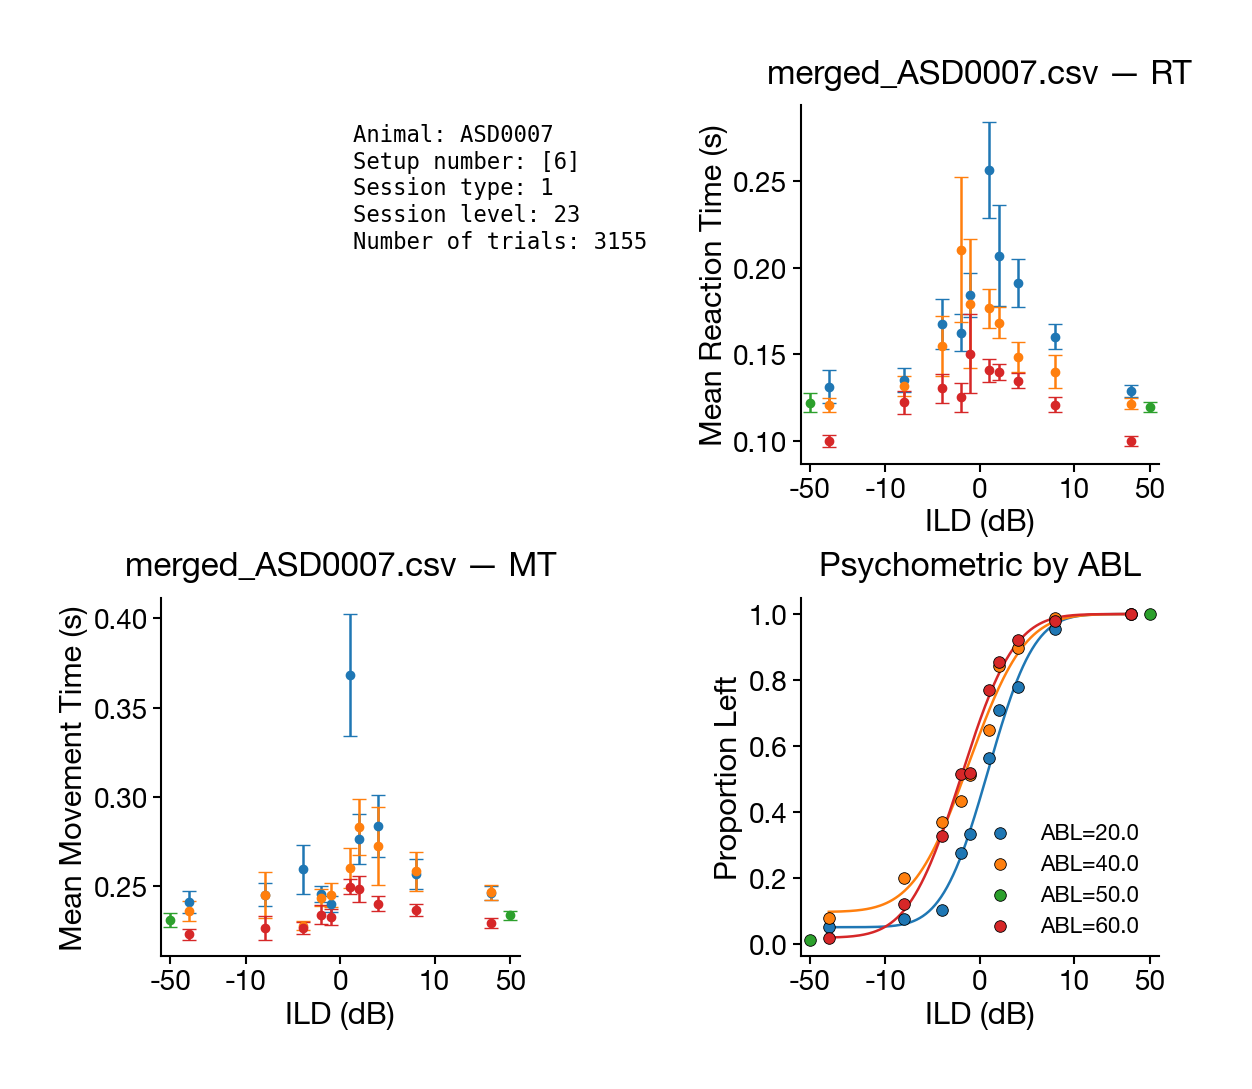

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)
n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]
session_number = df_last["session"].max()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(1, 0.95, info, fontsize=16, va="top", family="monospace")

# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title=f"{os.path.basename(subject_file)} — RT",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title=f"{os.path.basename(subject_file)} — MT",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-13-da1b14efacca>:94: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

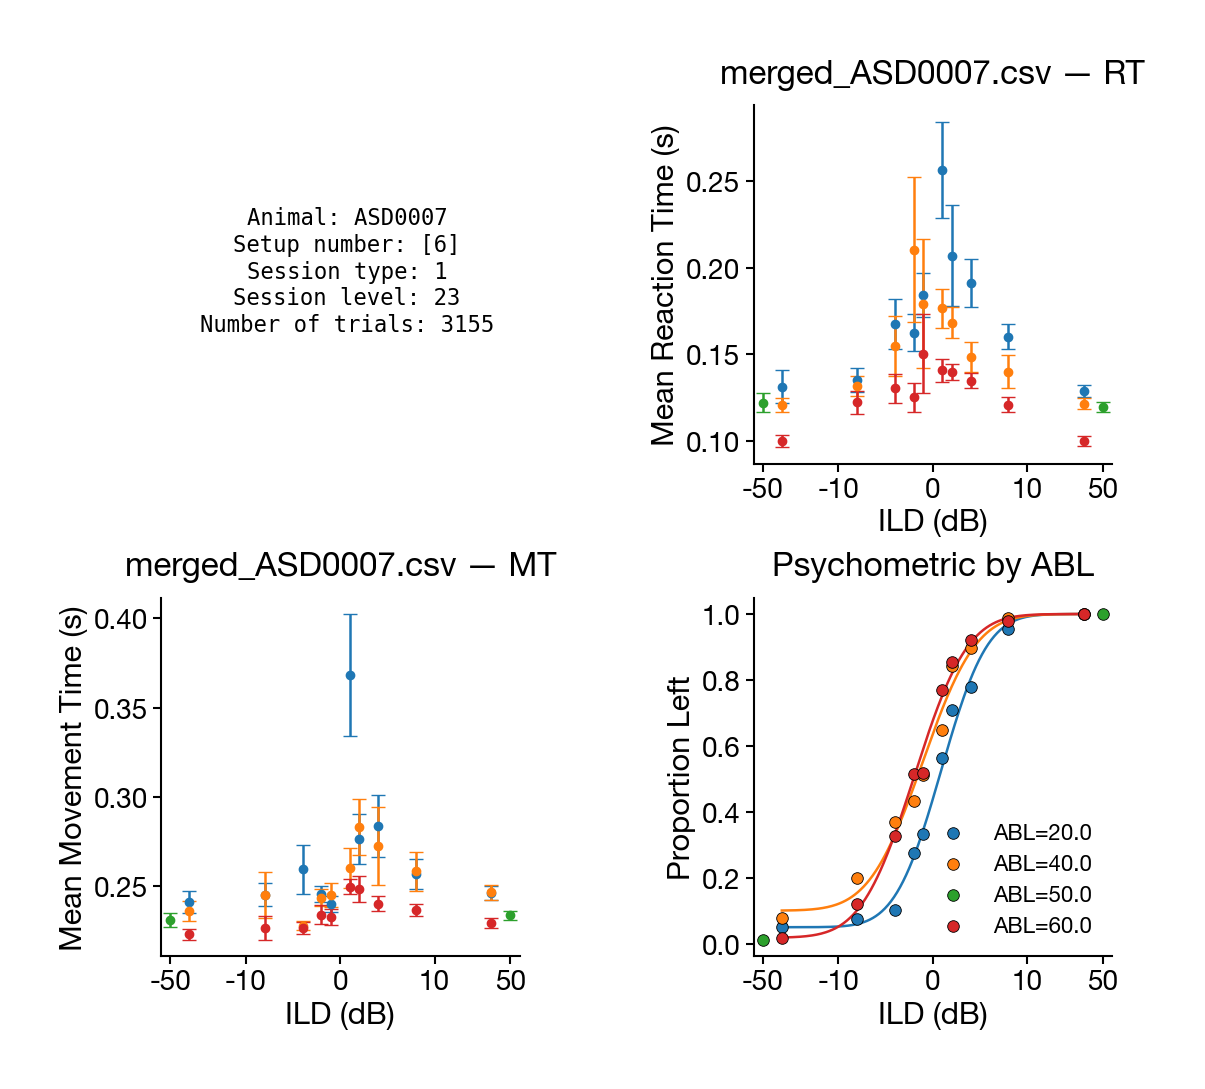

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)
n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]
session_number = df_last["session"].max()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title=f"{os.path.basename(subject_file)} — RT",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title=f"{os.path.basename(subject_file)} — MT",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-14-91e3a4fa0a1b>:94: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

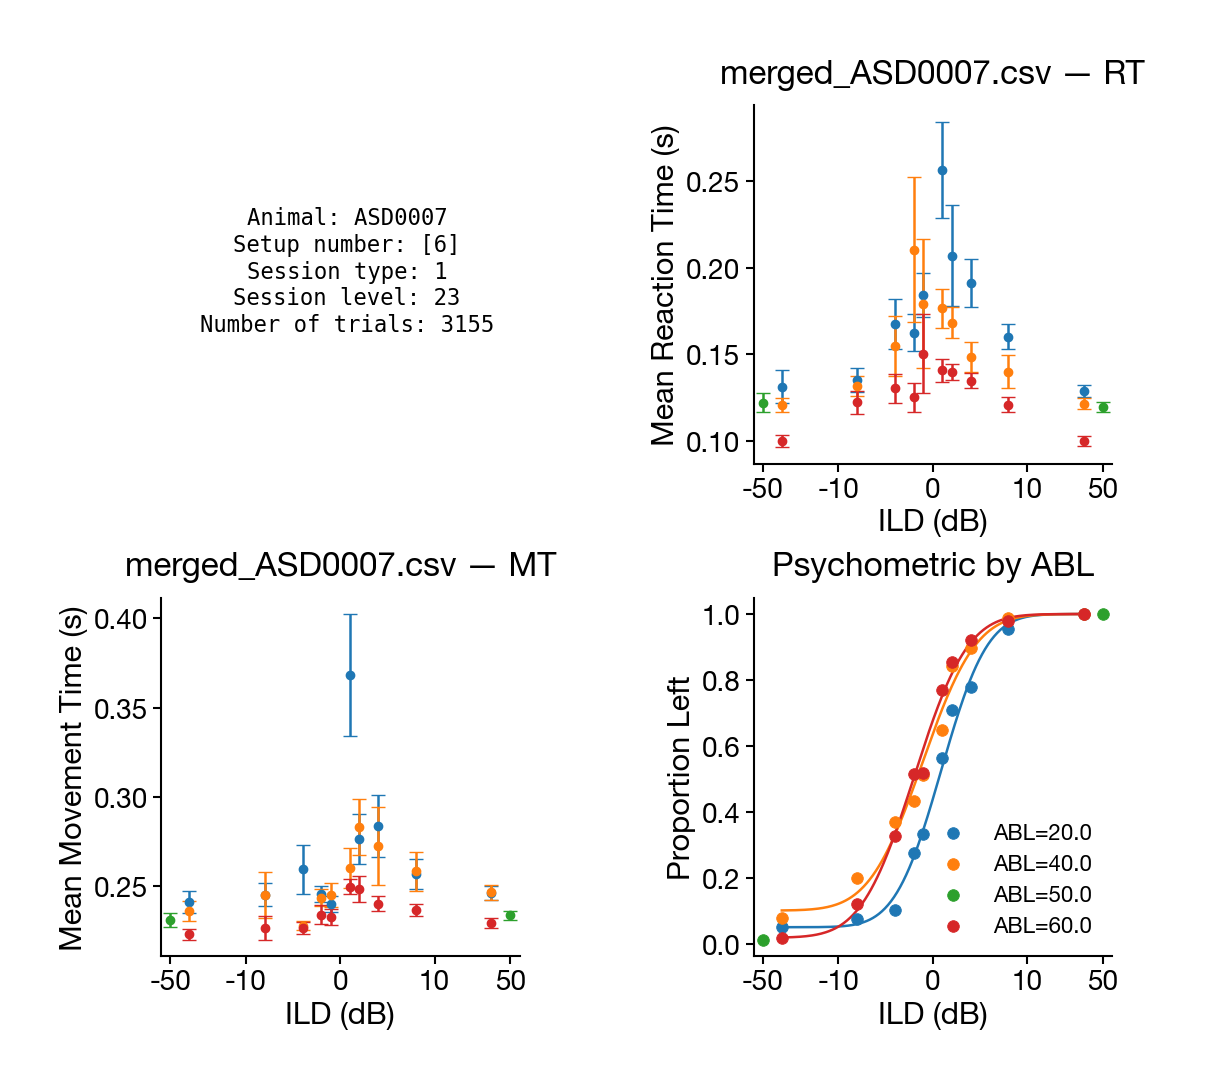

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)
n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]
session_number = df_last["session"].max()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title=f"{os.path.basename(subject_file)} — RT",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title=f"{os.path.basename(subject_file)} — MT",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-15-3accacc91bba>:94: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

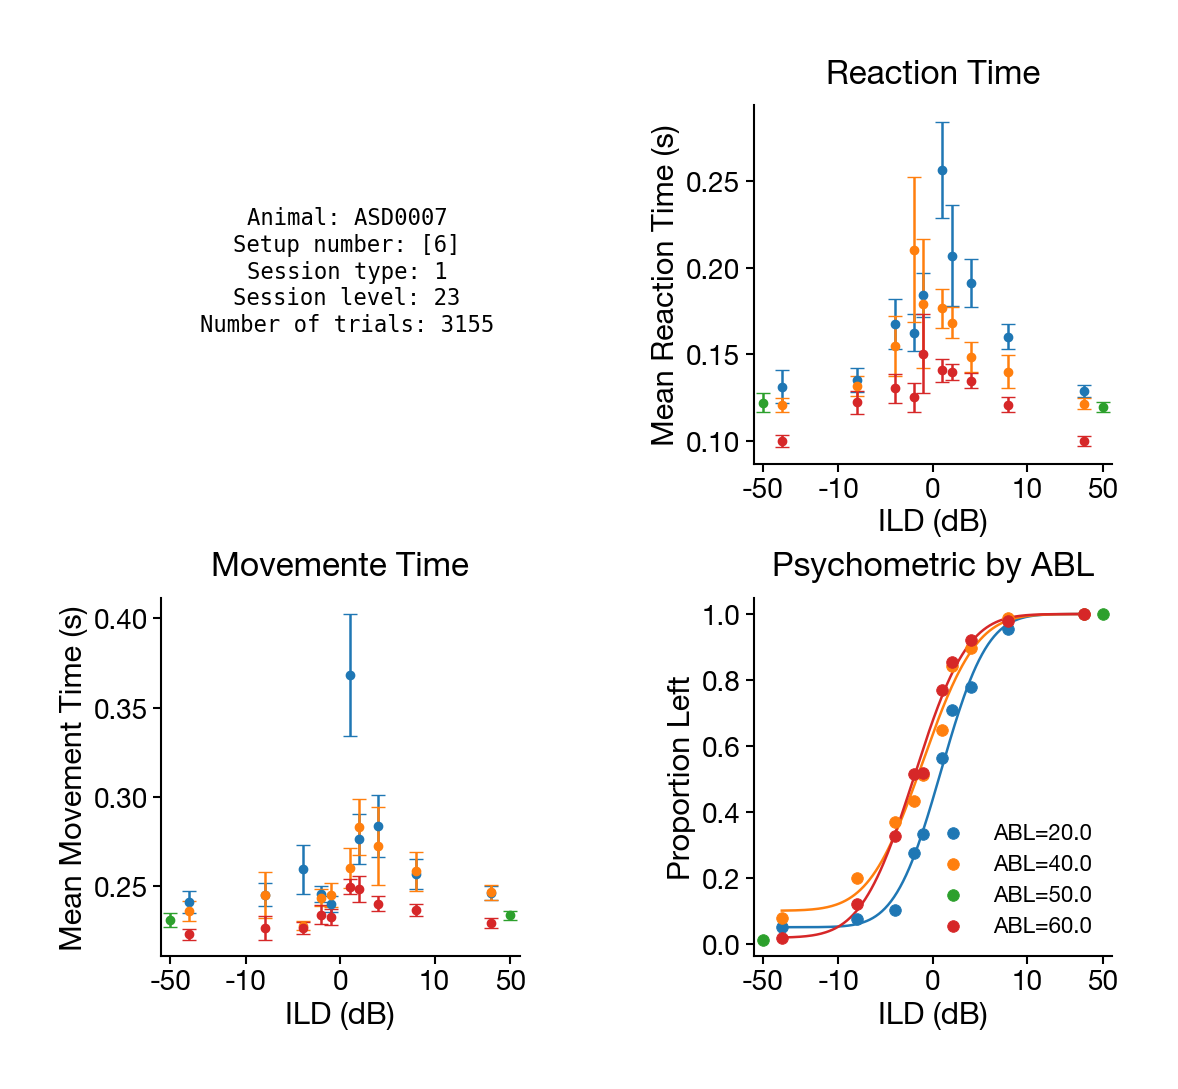

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)
n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]
session_number = df_last["session"].max()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movemente Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-16-70f1cfd6735e>:94: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

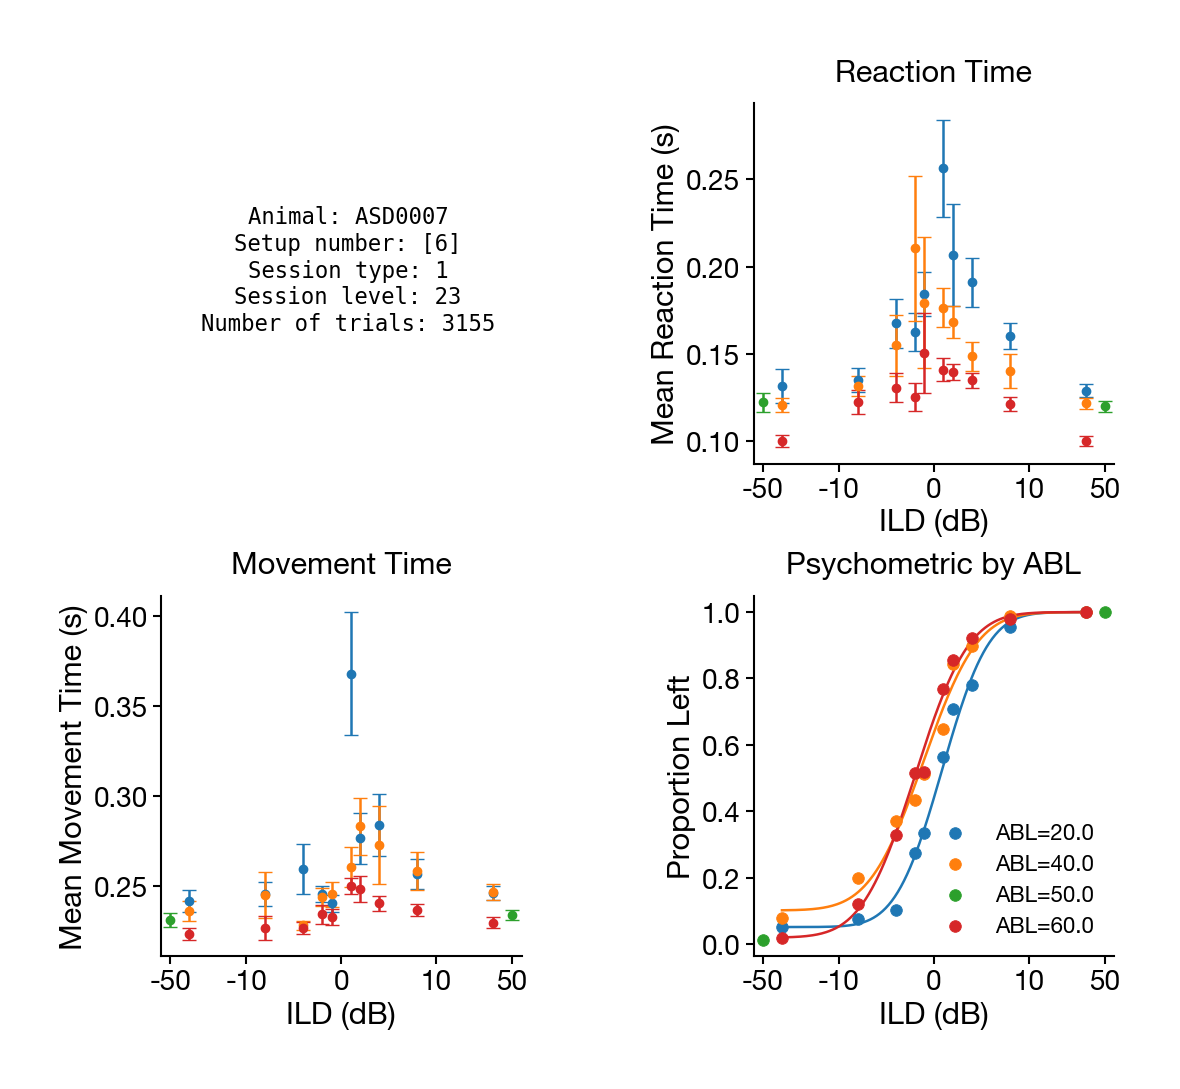

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)
n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]
session_number = df_last["session"].max()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()


ABL=20.0, n_trials=1247
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.00943396 0.00757576 0.07964602 0.14074074 0.26612903 0.38582677
 0.51449275 0.55963303 0.66412214 0.81818182]
n_trials: [106 132 113 135 124 127 138 109 131 132]

ABL=40.0, n_trials=1150
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.00806452 0.01612903 0.08333333 0.18867925 0.29059829 0.45945946
 0.43877551 0.63709677 0.69565217 0.71544715]
n_trials: [124 124 108 106 117 111  98 124 115 123]

ABL=50.0, n_trials=179
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.         0.81052632]
n_trials: [84 95]

ABL=60.0, n_trials=1219
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.00813008 0.18604651 0.32575758 0.33613445 0.46875
 0.5042735  0.65354331 0.70895522

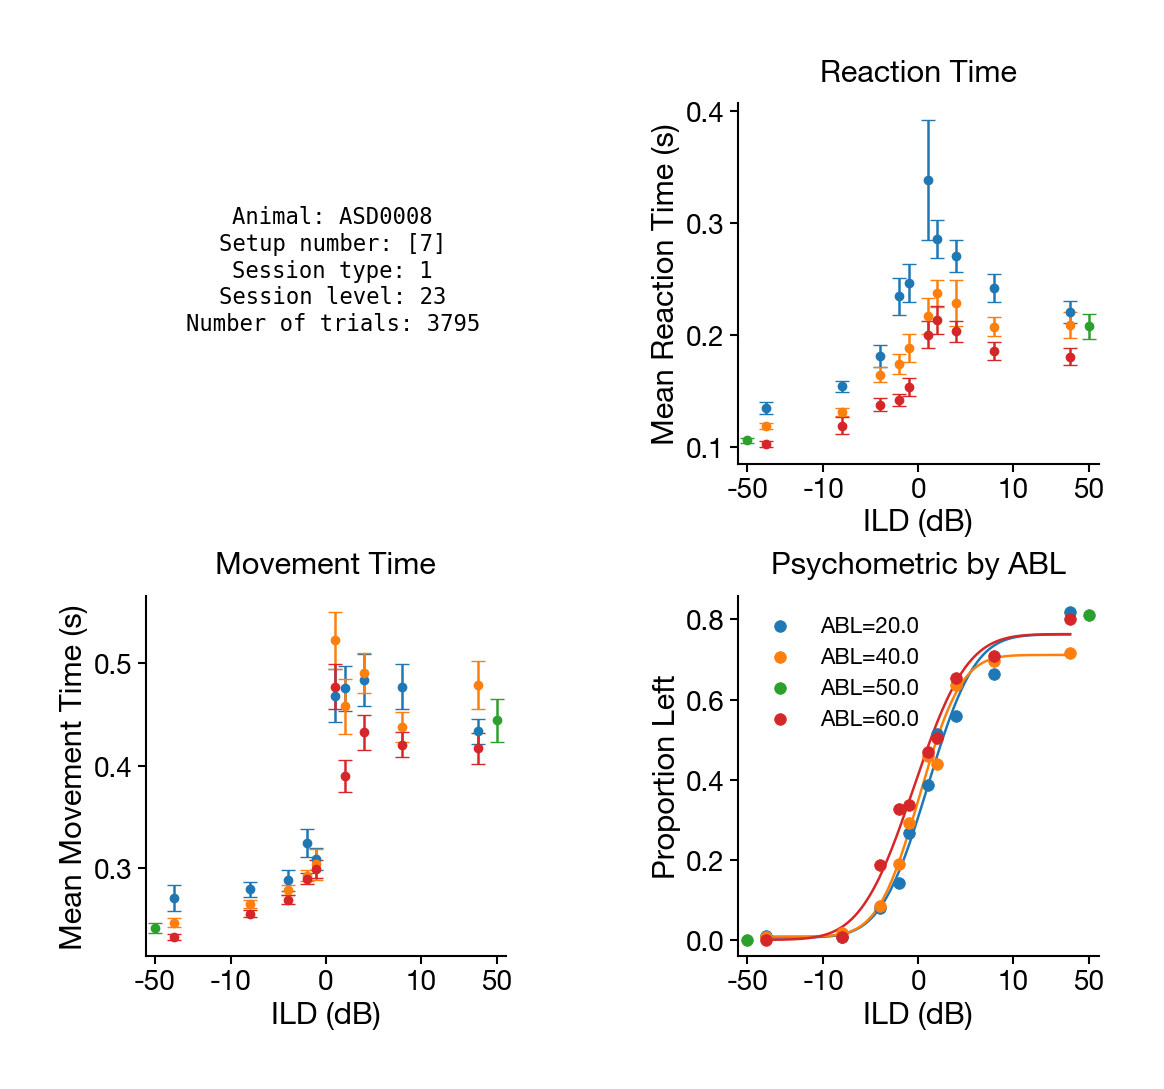

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0007.csv"

# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0008.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)
n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]
session_number = df_last["session"].max()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()


ABL=20.0, n_trials=889
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.04255319 0.05882353 0.30769231 0.47368421 0.6043956  0.73809524
 0.77011494 0.80612245 0.97979798 0.96341463]
n_trials: [94 68 91 95 91 84 87 98 99 82]

ABL=40.0, n_trials=962
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01111111 0.05607477 0.23404255 0.38679245 0.51546392 0.63366337
 0.72340426 0.69791667 0.84848485 0.83333333]
n_trials: [ 90 107  94 106  97 101  94  96  99  78]

ABL=50.0, n_trials=104
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.         0.89583333]
n_trials: [56 48]

ABL=60.0, n_trials=832
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.02631579 0.22891566 0.3        0.39772727 0.46875
 0.6375     0.74390244 0.86046512 0.93333333]


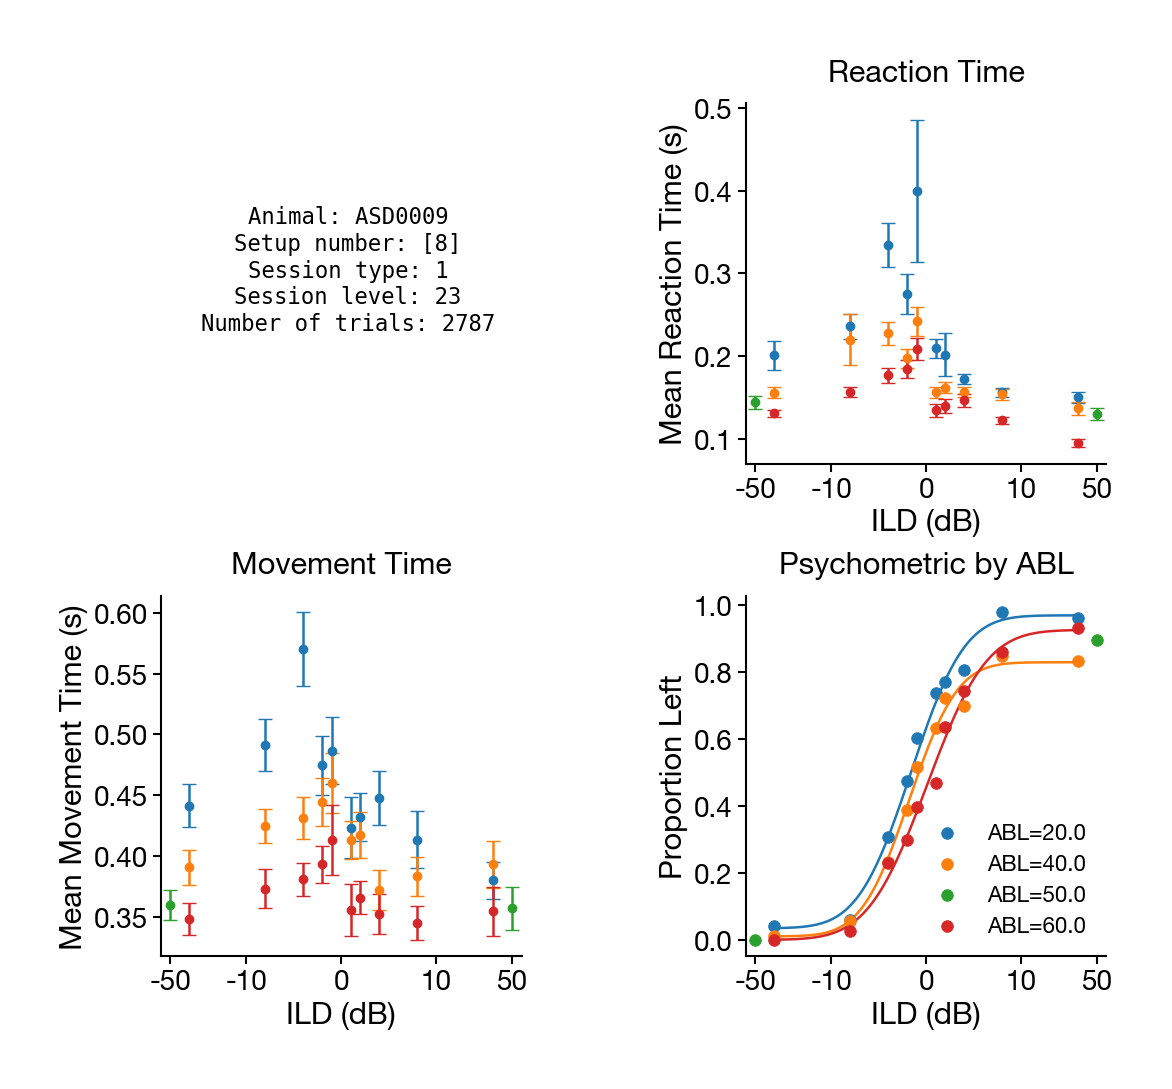

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0009.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)
n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]
session_number = df_last["session"].max()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-19-2540e007d66b>:90: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=955
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.06666667 0.18987342 0.43119266 0.59803922 0.68686869 0.82291667
 0.83       0.93333333 0.96875    0.91489362]
n_trials: [ 90  79 109 102  99  96 100  90  96  94]

ABL=40.0, n_trials=997
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.10280374 0.17171717 0.36036036 0.54639175 0.57608696 0.6635514
 0.72340426 0.85555556 0.86666667 0.86363636]
n_trials: [107  99 111  97  92 107  94  90  90 110]

ABL=50.0, n_trials=118
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.06779661 0.91525424]
n_trials: [59 59]

ABL=60.0, n_trials=971
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01219512 0.0754717  0.32352941 0.44444444 0.60606061 0.7
 0.69473684 0.89655172 0.83653846 0.94897

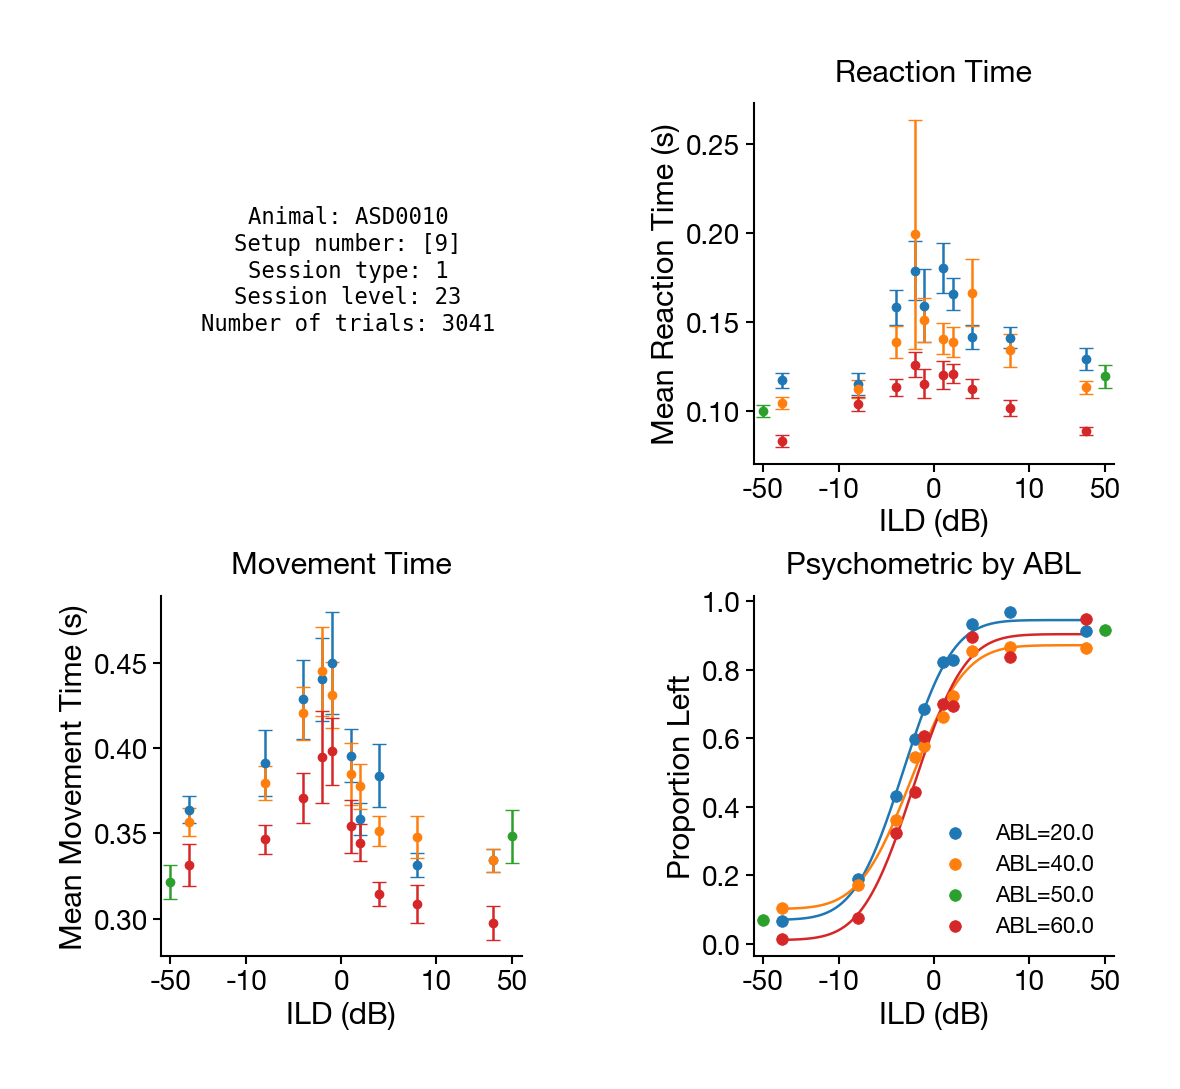

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0010.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)
n_trials = len(df_last)
session_type = df_last["session_type"].iloc[0]
session_number = df_last["session"].max()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Session level: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0010.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique[0]
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-20-4140a0ab04e3>:90: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)


TypeError: 'method' object is not subscriptable

<ipython-input-21-d5e7efd83825>:90: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=955
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.06666667 0.18987342 0.43119266 0.59803922 0.68686869 0.82291667
 0.83       0.93333333 0.96875    0.91489362]
n_trials: [ 90  79 109 102  99  96 100  90  96  94]

ABL=40.0, n_trials=997
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.10280374 0.17171717 0.36036036 0.54639175 0.57608696 0.6635514
 0.72340426 0.85555556 0.86666667 0.86363636]
n_trials: [107  99 111  97  92 107  94  90  90 110]

ABL=50.0, n_trials=118
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.06779661 0.91525424]
n_trials: [59 59]

ABL=60.0, n_trials=971
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01219512 0.0754717  0.32352941 0.44444444 0.60606061 0.7
 0.69473684 0.89655172 0.83653846 0.94897

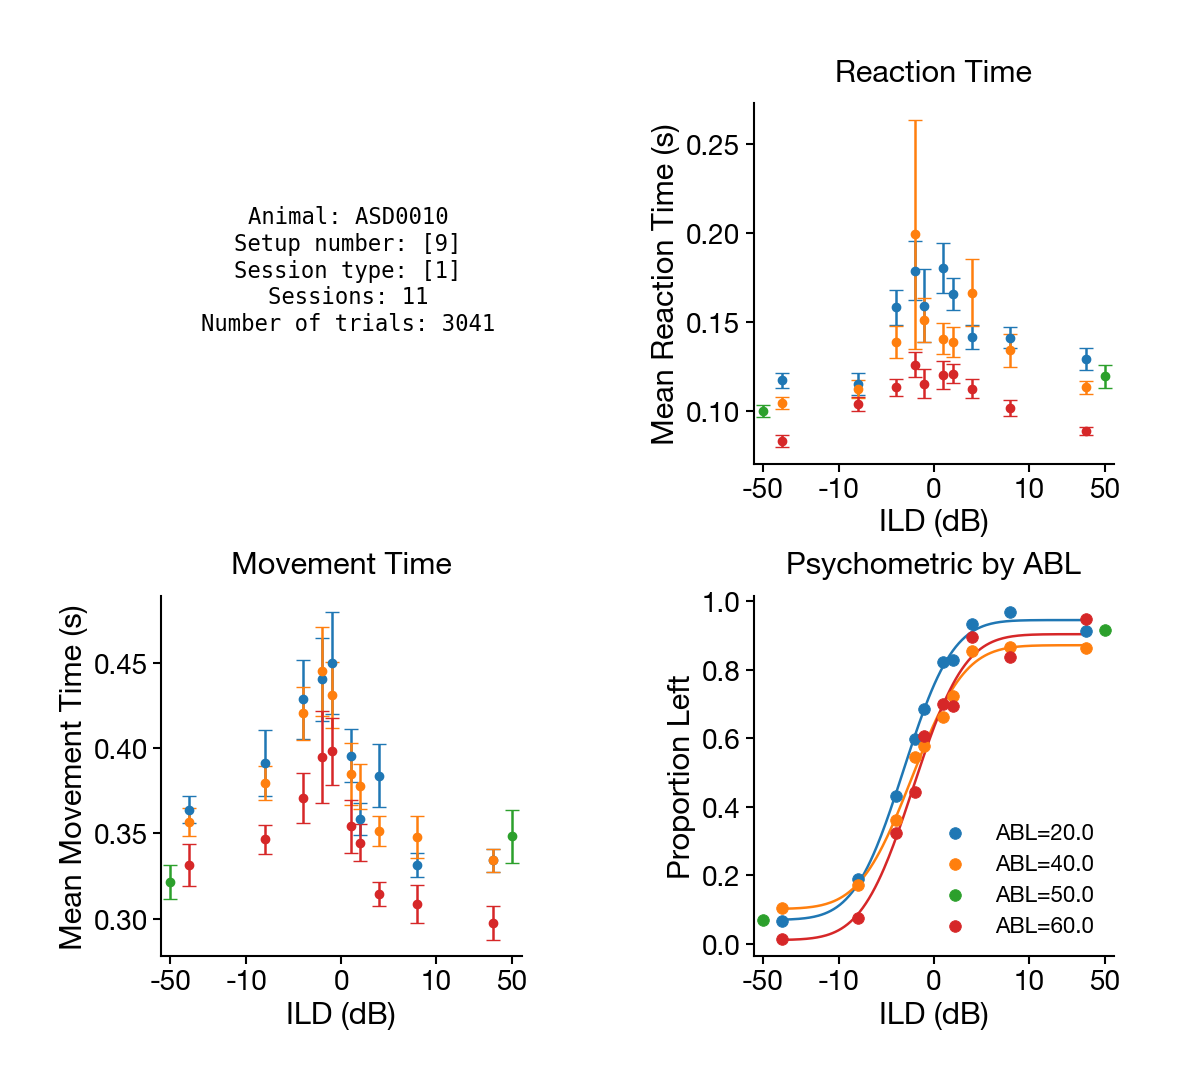

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
subject_file = "merged_ASD0010.csv"
df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-22-8532b0c21fbd>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

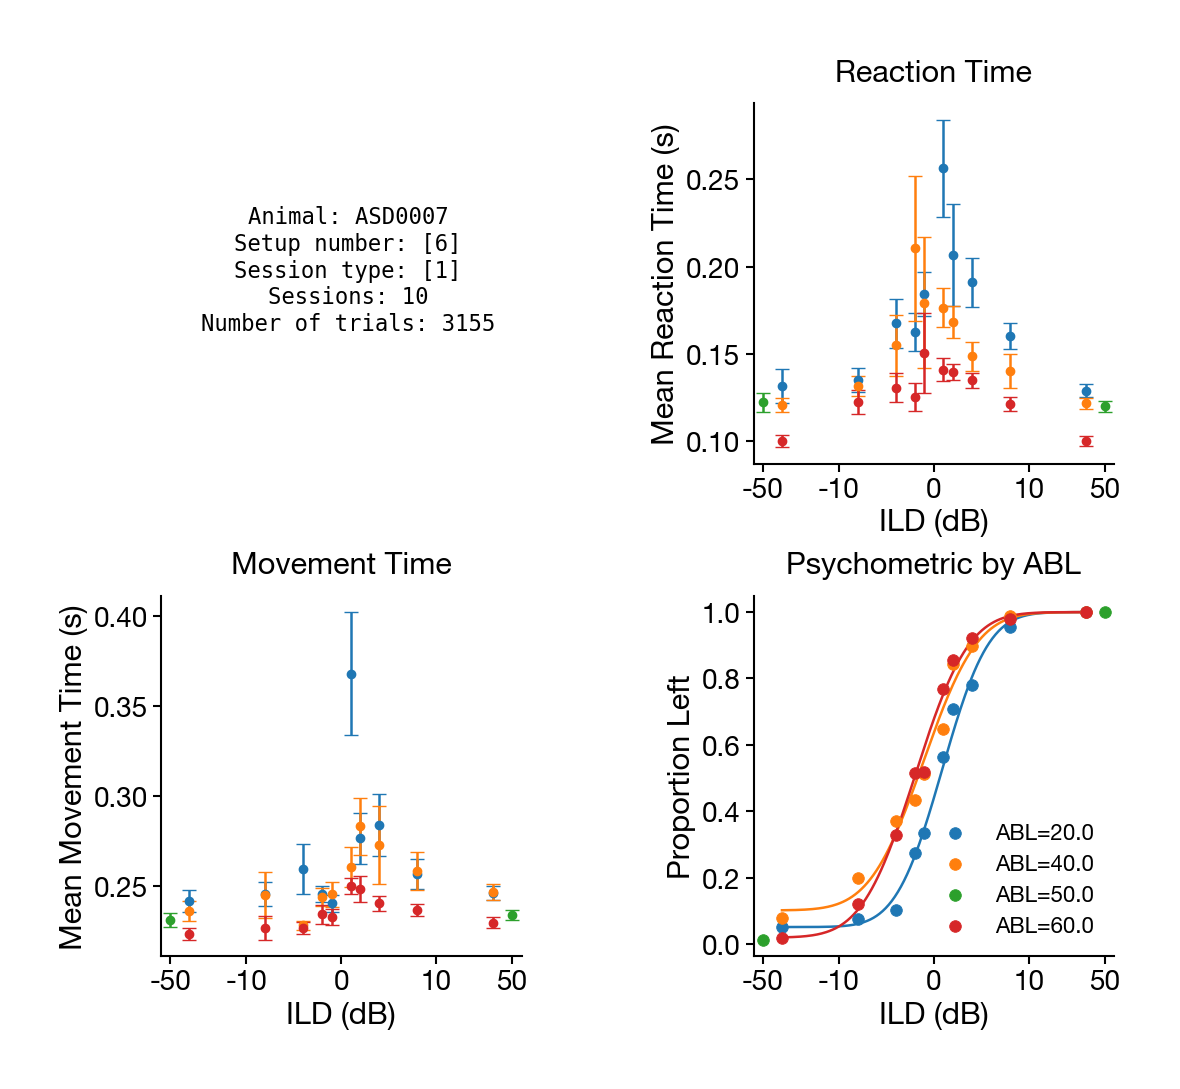

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0007.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()


ABL=20.0, n_trials=1247
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.00943396 0.00757576 0.07964602 0.14074074 0.26612903 0.38582677
 0.51449275 0.55963303 0.66412214 0.81818182]
n_trials: [106 132 113 135 124 127 138 109 131 132]

ABL=40.0, n_trials=1150
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.00806452 0.01612903 0.08333333 0.18867925 0.29059829 0.45945946
 0.43877551 0.63709677 0.69565217 0.71544715]
n_trials: [124 124 108 106 117 111  98 124 115 123]

ABL=50.0, n_trials=179
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.         0.81052632]
n_trials: [84 95]

ABL=60.0, n_trials=1219
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.00813008 0.18604651 0.32575758 0.33613445 0.46875
 0.5042735  0.65354331 0.70895522

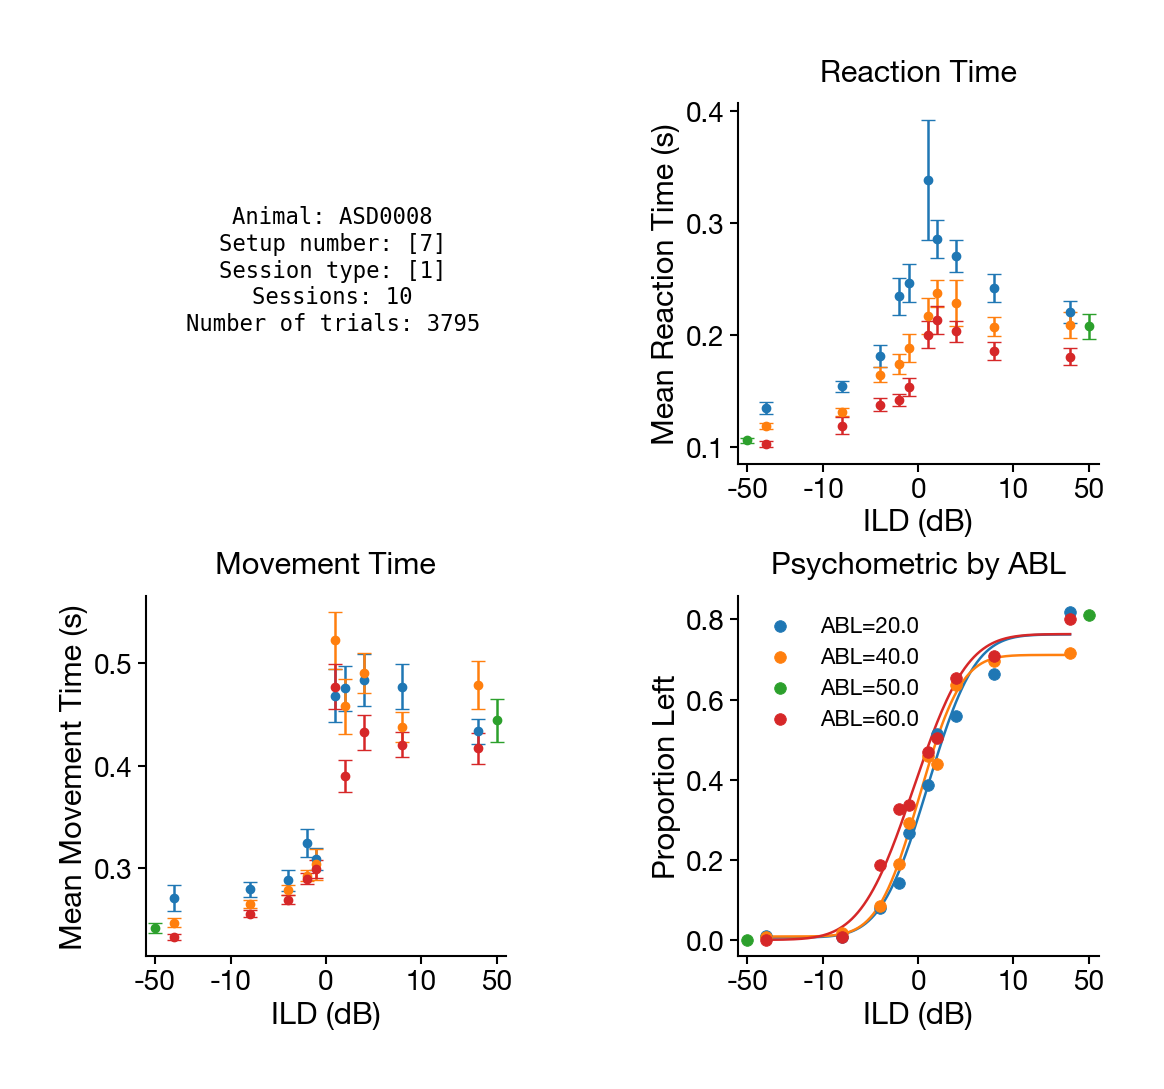

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0008.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()


ABL=20.0, n_trials=889
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.04255319 0.05882353 0.30769231 0.47368421 0.6043956  0.73809524
 0.77011494 0.80612245 0.97979798 0.96341463]
n_trials: [94 68 91 95 91 84 87 98 99 82]

ABL=40.0, n_trials=962
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01111111 0.05607477 0.23404255 0.38679245 0.51546392 0.63366337
 0.72340426 0.69791667 0.84848485 0.83333333]
n_trials: [ 90 107  94 106  97 101  94  96  99  78]

ABL=50.0, n_trials=104
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.         0.89583333]
n_trials: [56 48]

ABL=60.0, n_trials=832
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.02631579 0.22891566 0.3        0.39772727 0.46875
 0.6375     0.74390244 0.86046512 0.93333333]


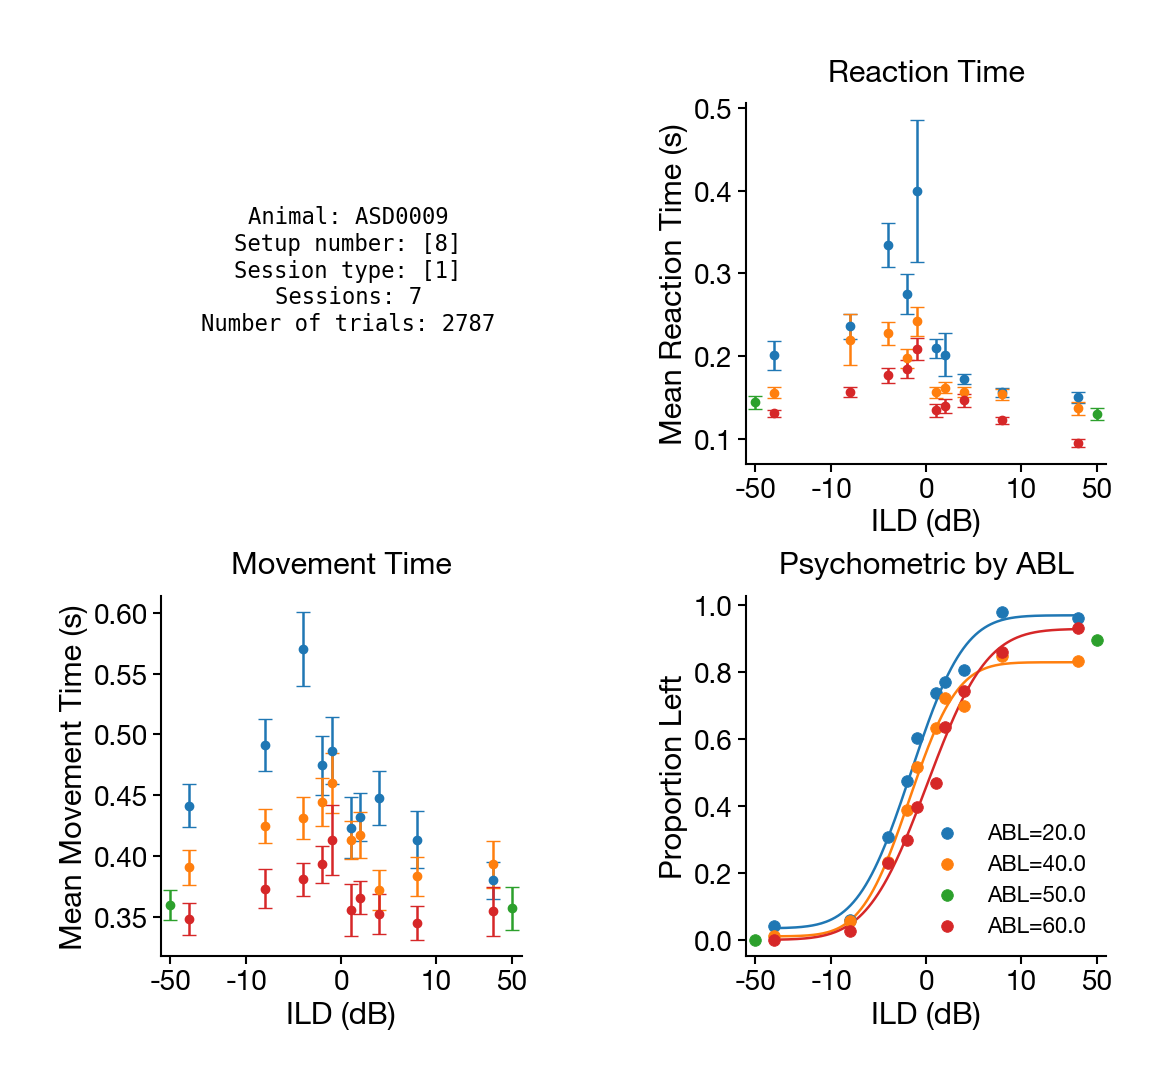

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0009.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-25-458b3c6443a1>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=955
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.06666667 0.18987342 0.43119266 0.59803922 0.68686869 0.82291667
 0.83       0.93333333 0.96875    0.91489362]
n_trials: [ 90  79 109 102  99  96 100  90  96  94]

ABL=40.0, n_trials=997
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.10280374 0.17171717 0.36036036 0.54639175 0.57608696 0.6635514
 0.72340426 0.85555556 0.86666667 0.86363636]
n_trials: [107  99 111  97  92 107  94  90  90 110]

ABL=50.0, n_trials=118
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.06779661 0.91525424]
n_trials: [59 59]

ABL=60.0, n_trials=971
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01219512 0.0754717  0.32352941 0.44444444 0.60606061 0.7
 0.69473684 0.89655172 0.83653846 0.94897

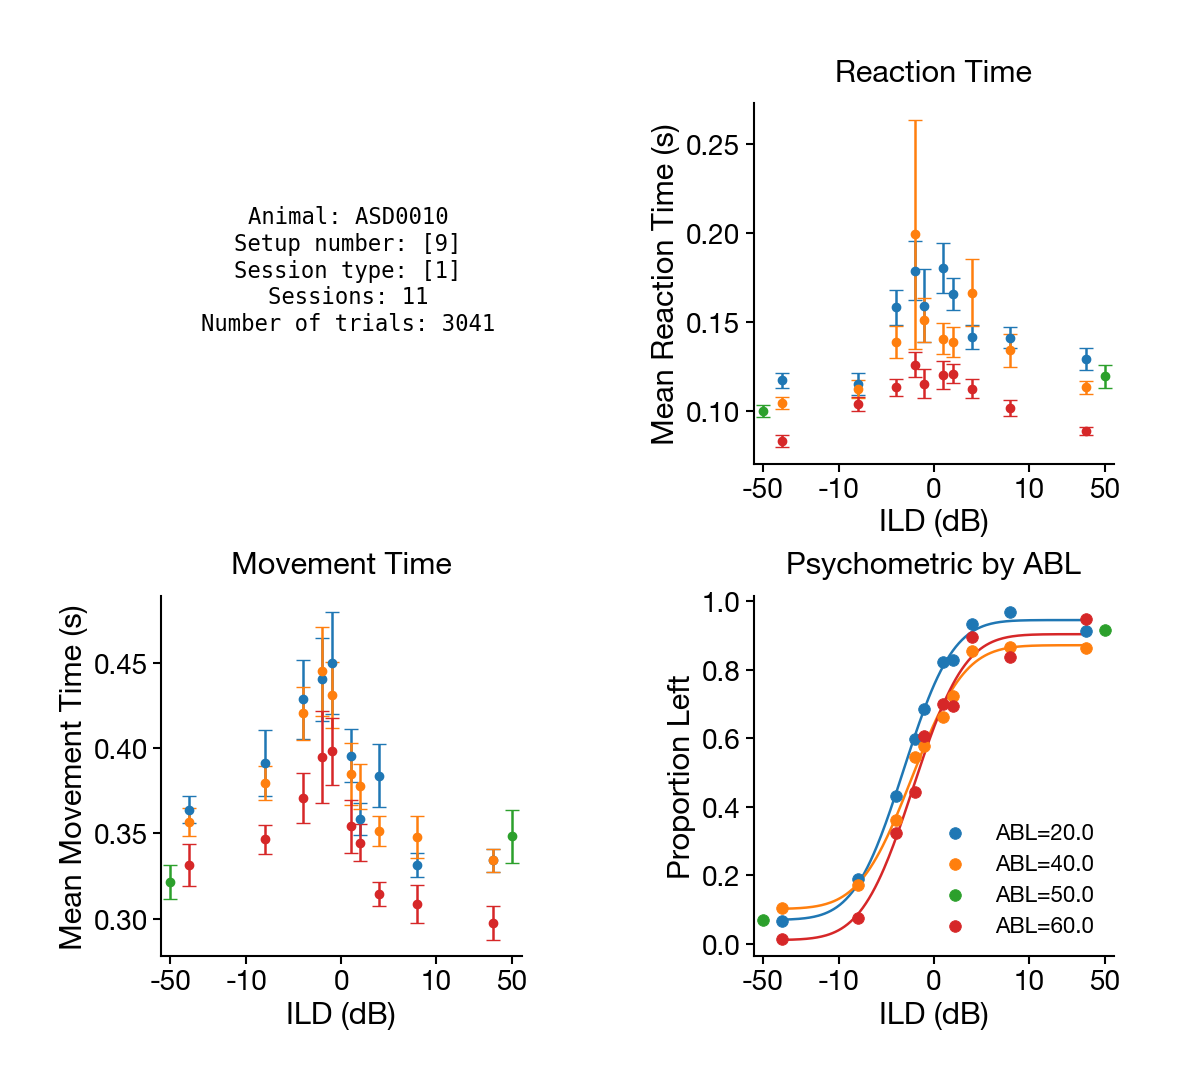

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0010.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-26-727ab738e2d5>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=1102
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.04395604 0.10434783 0.3        0.42241379 0.48913043 0.73529412
 0.78294574 0.86153846 0.92792793 0.98275862]
n_trials: [ 91 115 100 116  92 102 129 130 111 116]

ABL=40.0, n_trials=1066
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01960784 0.09615385 0.18852459 0.42857143 0.40217391 0.68224299
 0.81578947 0.88034188 0.97777778 0.99056604]
n_trials: [102 104 122 112  92 107 114 117  90 106]

ABL=50.0, n_trials=136
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.02631579 1.        ]
n_trials: [76 60]

ABL=60.0, n_trials=1046
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01       0.0754717  0.23636364 0.3125     0.48571429 0.69642857
 0.74311927 0.84042553 0.92920

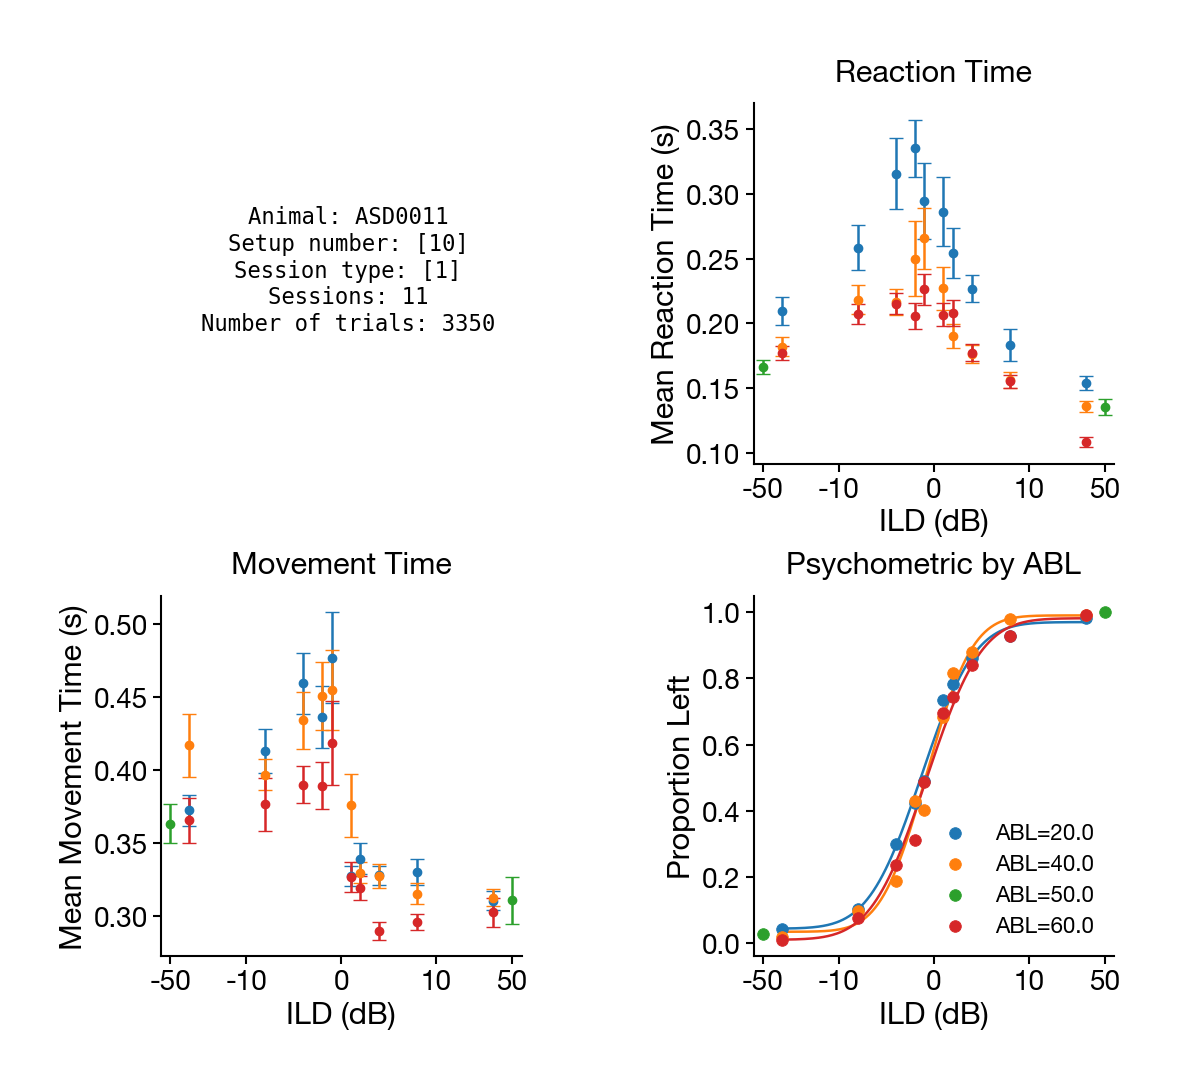

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0011.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-27-25a4f4c57bfb>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=1086
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.02521008 0.05714286 0.23214286 0.21818182 0.49494949
 0.44444444 0.79411765 0.95238095 1.        ]
n_trials: [112 119 105 112 110  99 117 102 105 105]

ABL=40.0, n_trials=1027
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.01162791 0.19626168 0.26851852 0.35135135 0.5462963
 0.71276596 0.74509804 0.95604396 1.        ]
n_trials: [104  86 107 108 111 108  94 102  91 116]

ABL=50.0, n_trials=156
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0. 1.]
n_trials: [83 73]

ABL=60.0, n_trials=1111
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.01801802 0.05357143 0.12605042 0.30841121 0.3826087
 0.60606061 0.81034483 0.96261682 1.        ]
n_

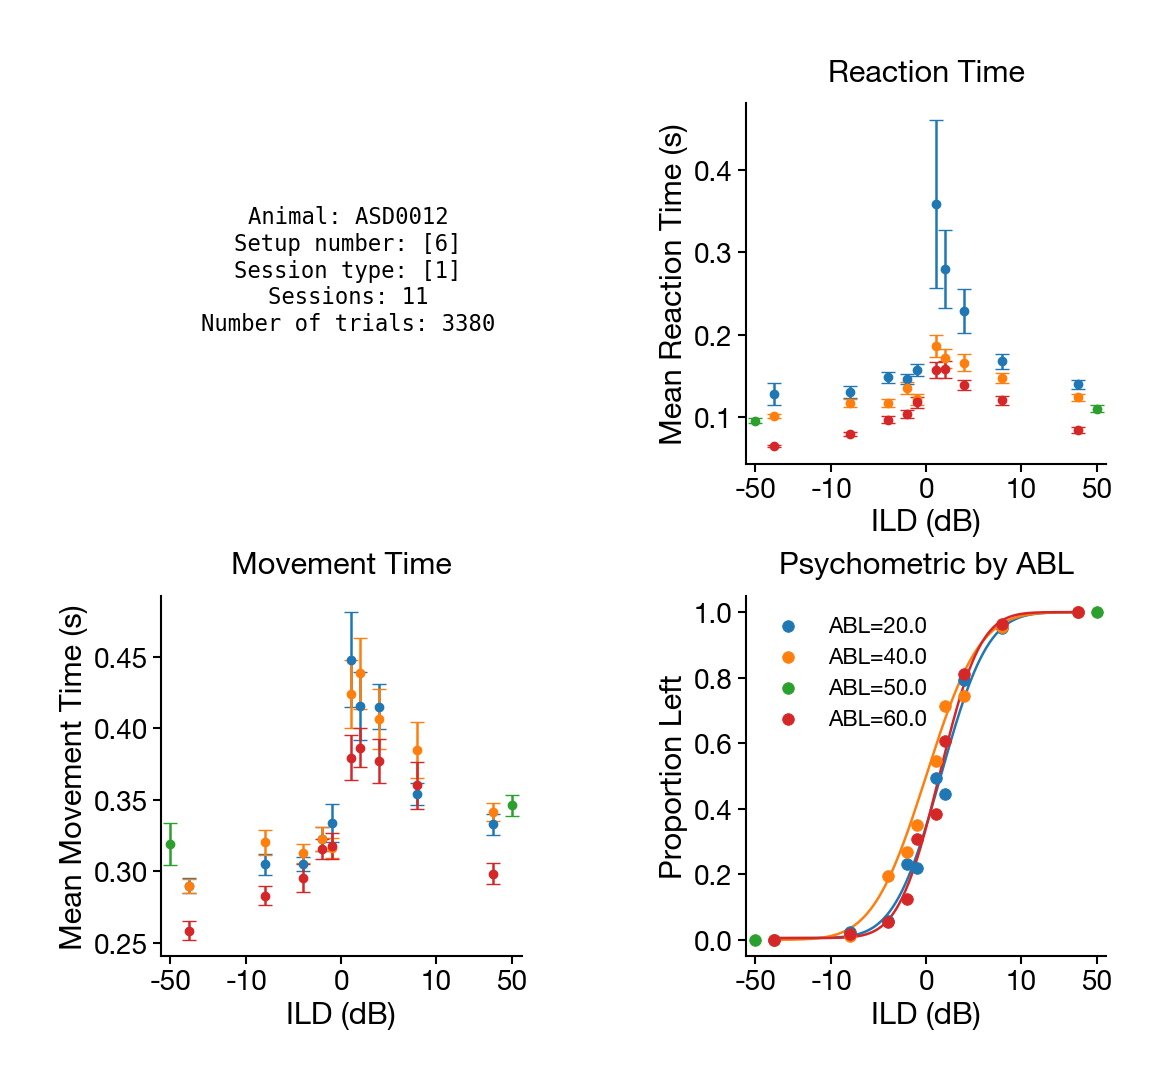

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0012.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()


ABL=20.0, n_trials=1690
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01298701 0.01219512 0.10227273 0.28497409 0.38983051 0.52287582
 0.6686747  0.87654321 0.94505495 0.99386503]
n_trials: [154 164 176 193 177 153 166 162 182 163]

ABL=40.0, n_trials=1740
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.02366864 0.10382514 0.26966292 0.36756757 0.61184211
 0.67613636 0.8908046  0.94478528 0.96756757]
n_trials: [175 169 183 178 185 152 176 174 163 185]

ABL=50.0, n_trials=222
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.         0.97413793]
n_trials: [106 116]

ABL=60.0, n_trials=1686
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.00558659 0.13953488 0.25       0.2484472  0.59550562
 0.70440252 0.80571429 0.944

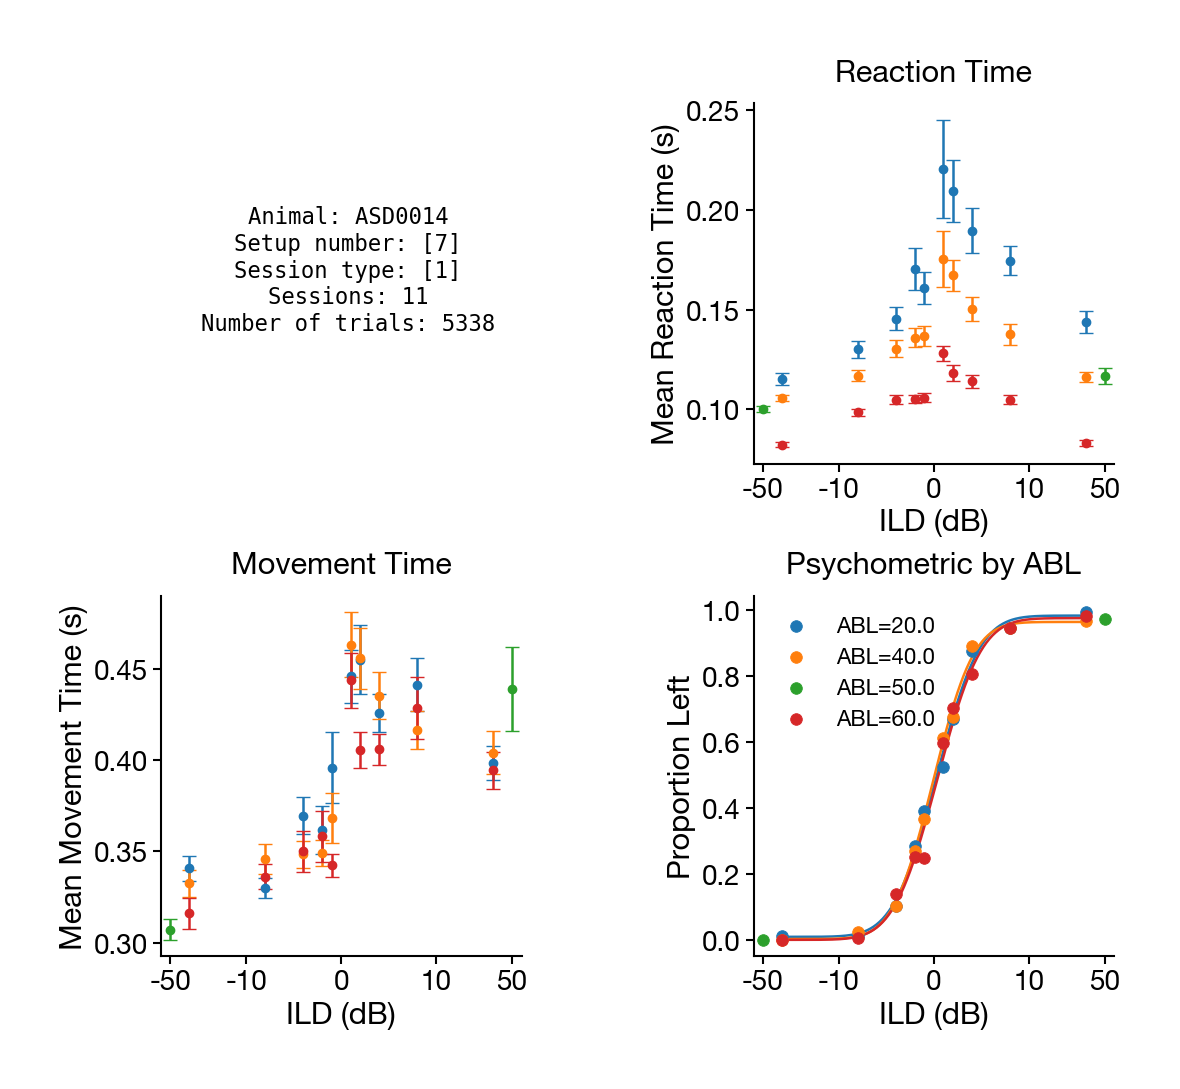

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0014.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()


ABL=20.0, n_trials=1690
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01612903 0.02366864 0.1627907  0.27322404 0.3902439  0.62264151
 0.73333333 0.85294118 0.94219653 0.98882682]
n_trials: [186 169 172 183 164 159 135 170 173 179]

ABL=40.0, n_trials=1681
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.035      0.06666667 0.1734104  0.27672956 0.39375    0.50955414
 0.74251497 0.82236842 0.94674556 0.94972067]
n_trials: [200 165 173 159 160 157 167 152 169 179]

ABL=50.0, n_trials=244
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.00869565 0.96899225]
n_trials: [115 129]

ABL=60.0, n_trials=1735
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01162791 0.02312139 0.10588235 0.24375    0.36571429 0.57988166
 0.68208092 0.79885057 0.943

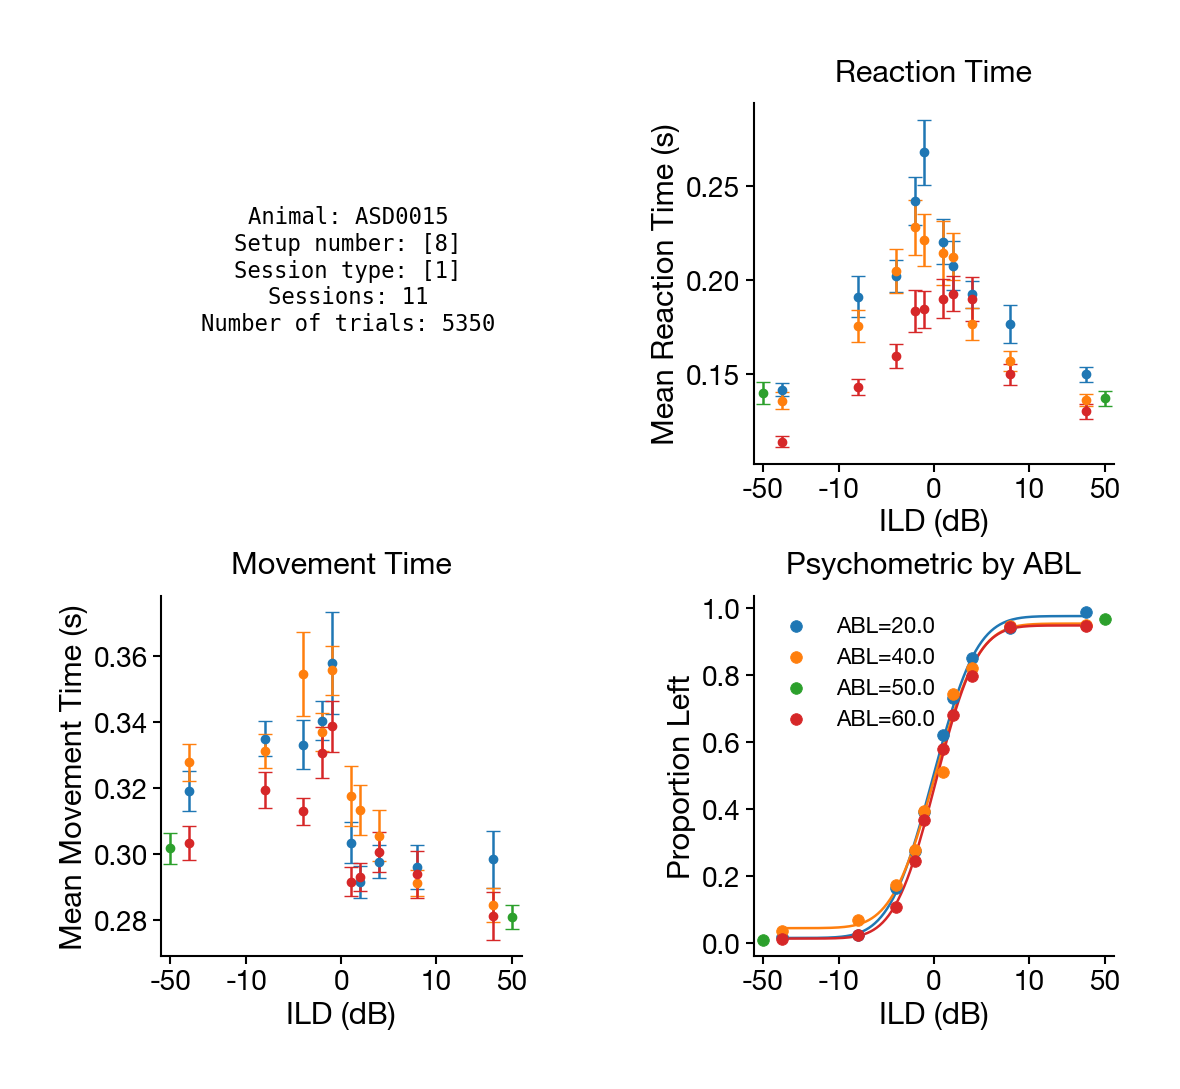

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0015.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()


ABL=20.0, n_trials=1434
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.13669065 0.19379845 0.26896552 0.36912752 0.43356643 0.56081081
 0.56050955 0.7080292  0.83221477 0.86231884]
n_trials: [139 129 145 149 143 148 157 137 149 138]

ABL=40.0, n_trials=1426
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.21088435 0.18918919 0.36507937 0.3740458  0.5112782  0.55479452
 0.65359477 0.70063694 0.79850746 0.86092715]
n_trials: [147 148 126 131 133 146 153 157 134 151]

ABL=50.0, n_trials=198
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.18072289 0.91304348]
n_trials: [ 83 115]

ABL=60.0, n_trials=1329
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07194245 0.136      0.25185185 0.22794118 0.26229508 0.40909091
 0.53982301 0.66393443 0.859

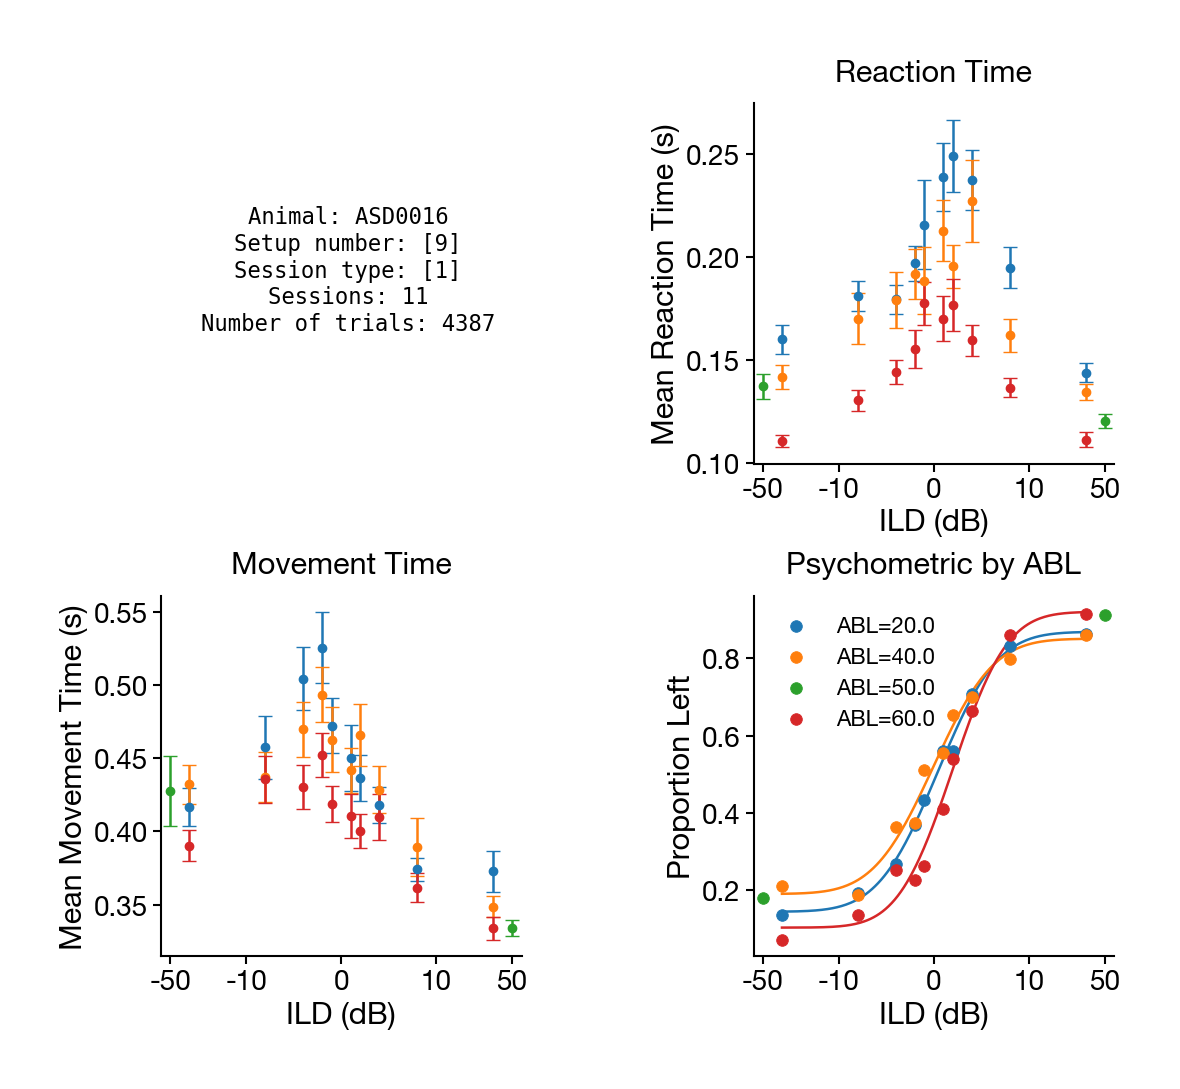

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0016.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()


ABL=20.0, n_trials=1396
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01973684 0.05185185 0.15068493 0.35483871 0.41025641 0.72180451
 0.7173913  0.9109589  0.94366197 0.9469697 ]
n_trials: [152 135 146 155 117 133 138 146 142 132]

ABL=40.0, n_trials=1421
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.01470588 0.07407407 0.17361111 0.23489933 0.48818898
 0.62773723 0.64335664 0.80769231 0.89440994]
n_trials: [159 136 135 144 149 127 137 143 130 161]

ABL=50.0, n_trials=204
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.         0.95145631]
n_trials: [101 103]

ABL=60.0, n_trials=1389
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.02962963 0.05882353 0.14925373 0.2248062  0.37878788
 0.43055556 0.59701493 0.776

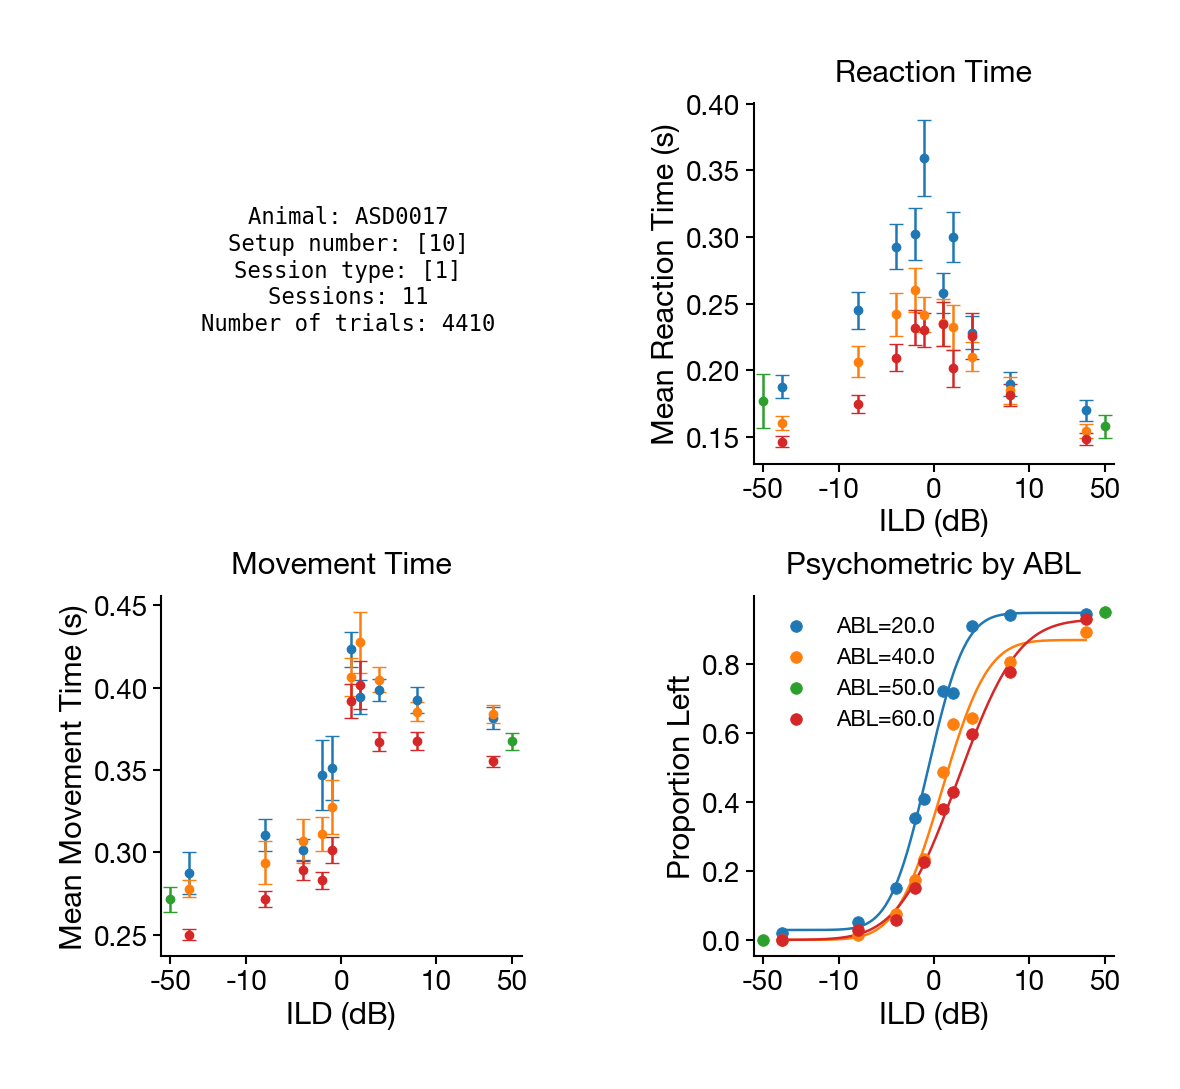

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0017.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-32-9c42f3de2f5f>:92: DtypeWarning: Columns (66,67) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=1378
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.02209945 0.05925926 0.19117647 0.33082707 0.29007634 0.6147541
 0.640625   0.77419355 0.84563758 0.97841727]
n_trials: [181 135 136 133 131 122 128 124 149 139]

ABL=40.0, n_trials=1295
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.03278689 0.112      0.24031008 0.44628099 0.47368421 0.6171875
 0.60330579 0.81481481 0.94520548 0.94074074]
n_trials: [122 125 129 121 133 128 121 135 146 135]

ABL=50.0, n_trials=184
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.0106383  0.96666667]
n_trials: [94 90]

ABL=60.0, n_trials=1288
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.00763359 0.1023622  0.2704918  0.50806452 0.56115108 0.69672131
 0.79069767 0.88888889 0.9682539

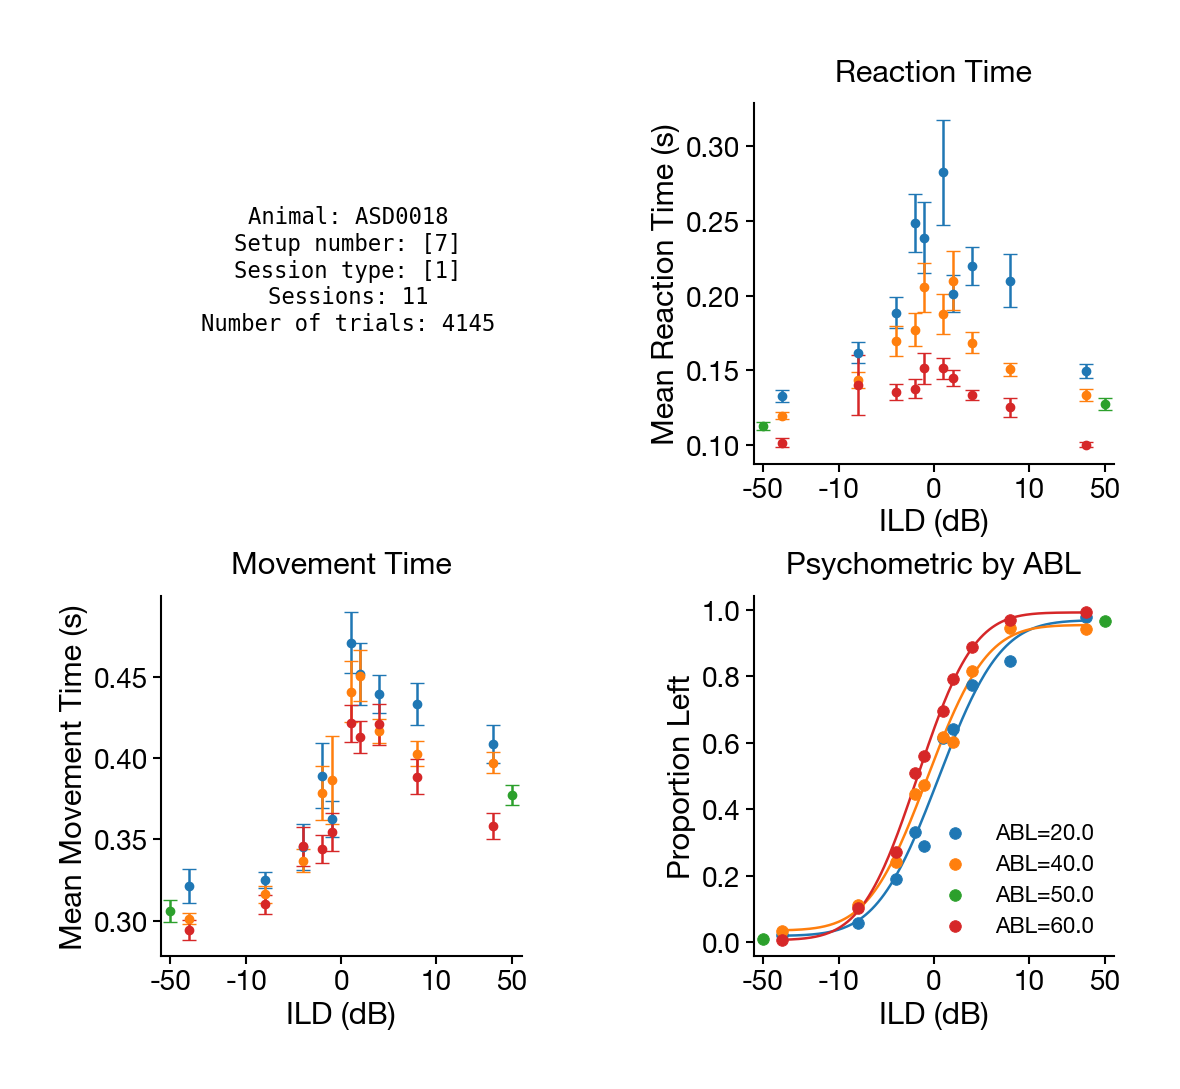

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0018.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-33-571c3d3d4a6c>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=1102
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.         0.01098901 0.04878049 0.14655172 0.28440367 0.52941176
 0.75454545 0.79207921 0.93277311 0.99047619]
n_trials: [126  91 123 116 109 102 110 101 119 105]

ABL=40.0, n_trials=1125
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.04040404 0.02752294 0.10091743 0.19101124 0.28813559 0.52991453
 0.61946903 0.79699248 0.92982456 0.95967742]
n_trials: [ 99 109 109  89 118 117 113 133 114 124]

ABL=50.0, n_trials=148
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.         0.98765432]
n_trials: [67 81]

ABL=60.0, n_trials=1152
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.00892857 0.02631579 0.09401709 0.16393443 0.34586466 0.47272727
 0.61682243 0.77876106 0.90476

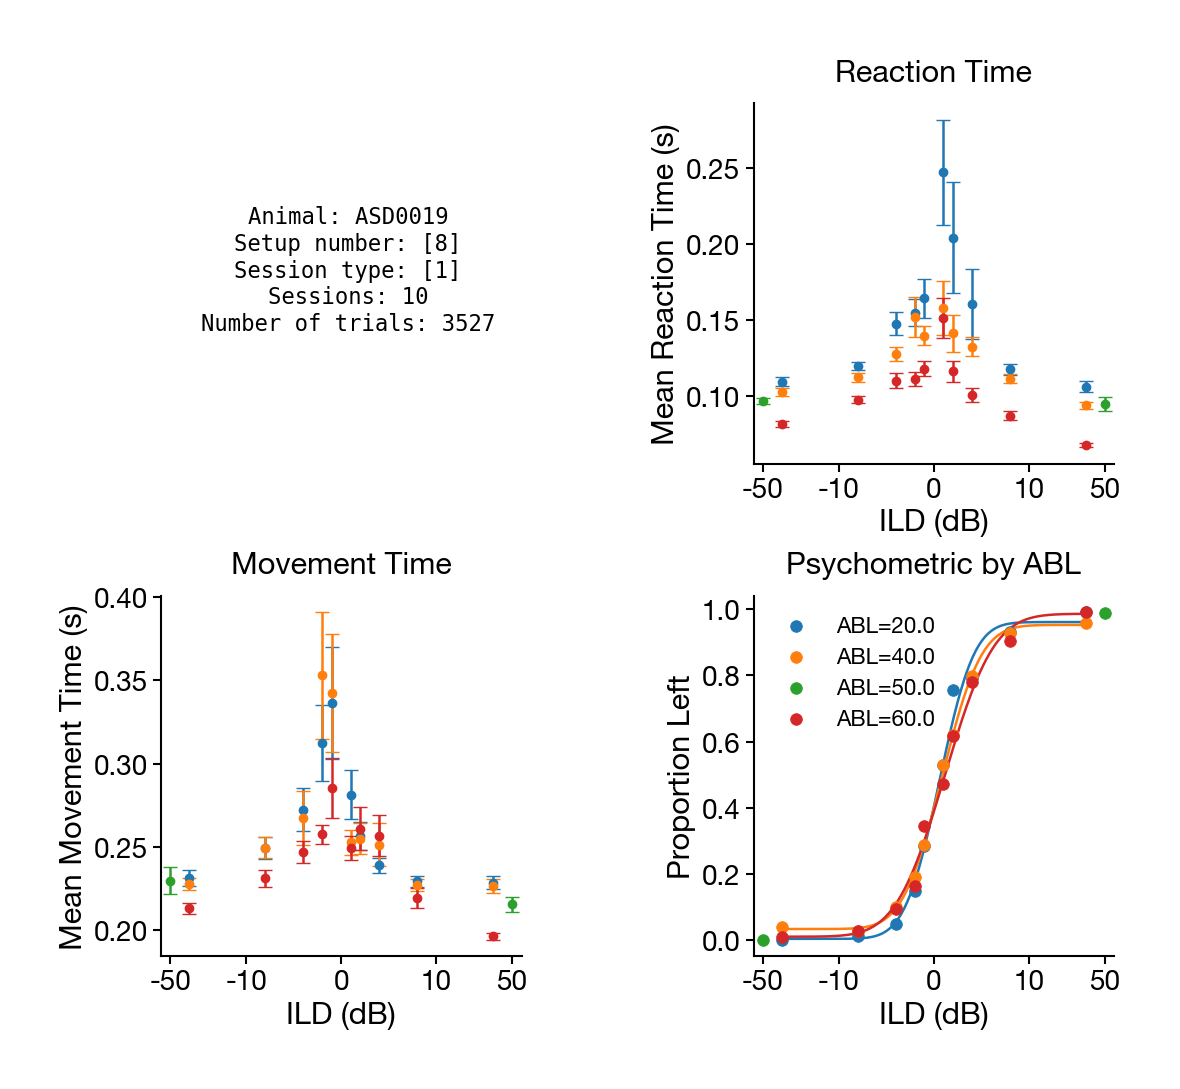

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0019.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()


ABL=20.0, n_trials=1468
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.00657895 0.04605263 0.12857143 0.36567164 0.38636364 0.62
 0.74025974 0.84615385 0.96319018 0.95555556]
n_trials: [152 152 140 134 132 150 154 156 163 135]

ABL=40.0, n_trials=1517
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.04635762 0.0962963  0.21153846 0.43558282 0.575      0.67105263
 0.77931034 0.82467532 0.92207792 0.96598639]
n_trials: [151 135 156 163 160 152 145 154 154 147]

ABL=50.0, n_trials=204
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.08333333 0.96296296]
n_trials: [ 96 108]

ABL=60.0, n_trials=1550
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.02739726 0.06875    0.25       0.38518519 0.5        0.74675325
 0.82802548 0.84076433 0.98285714 

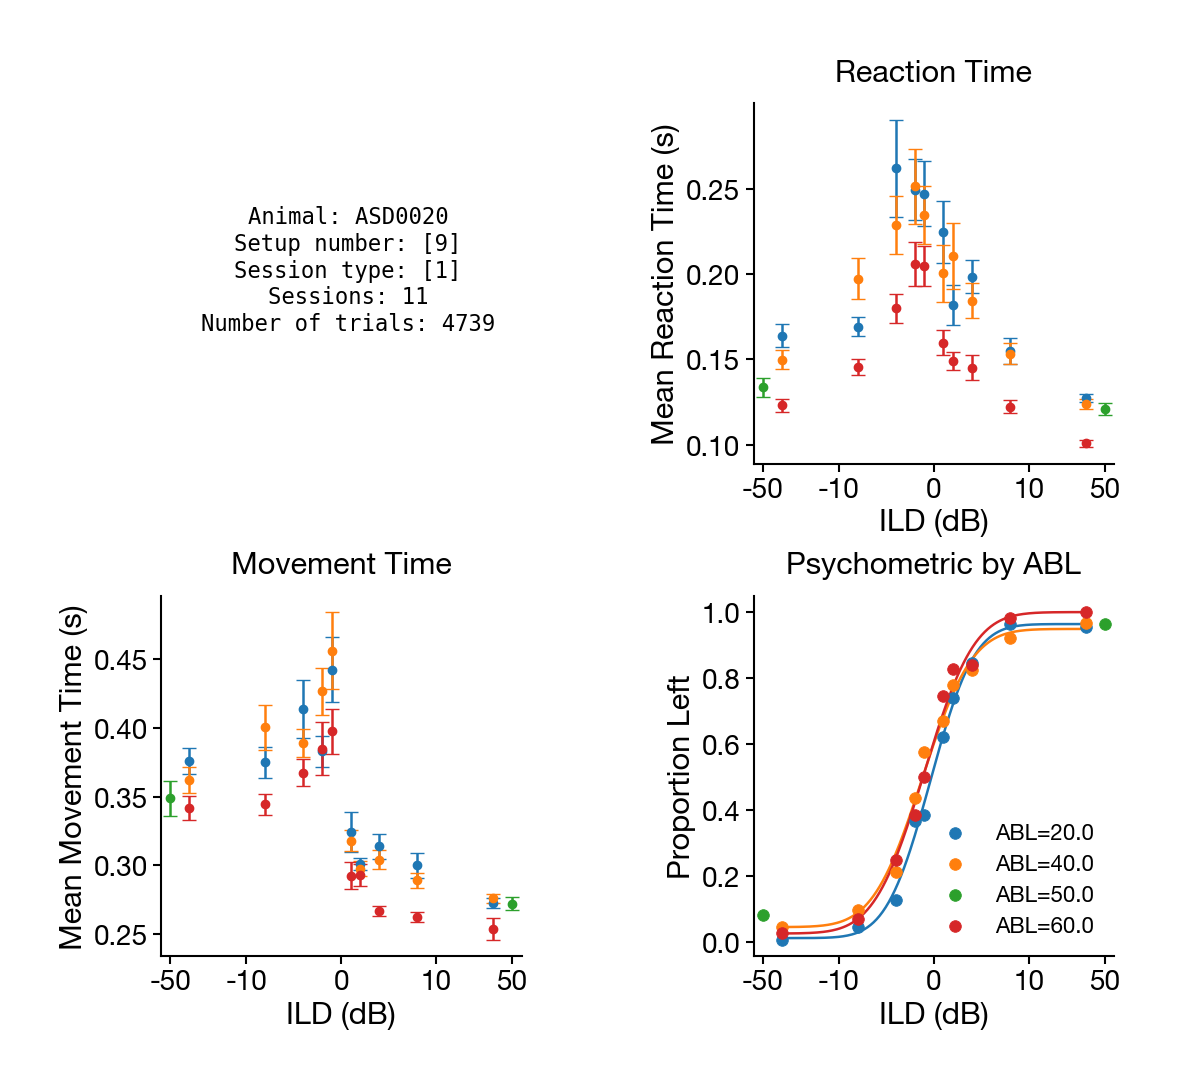

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0020.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-35-1f2125306aad>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(subject_file)



ABL=20.0, n_trials=1321
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.1015625  0.18115942 0.30327869 0.45890411 0.51587302 0.70338983
 0.80882353 0.91911765 0.984      1.        ]
n_trials: [128 138 122 146 126 118 136 136 125 146]

ABL=40.0, n_trials=1362
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.15277778 0.13675214 0.36842105 0.57746479 0.60629921 0.81632653
 0.8496732  0.9261745  0.97222222 1.        ]
n_trials: [144 117 114 142 127 147 153 149 144 125]

ABL=50.0, n_trials=161
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.08235294 1.        ]
n_trials: [85 76]

ABL=60.0, n_trials=1327
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.09230769 0.18965517 0.43571429 0.59124088 0.74107143 0.84397163
 0.88       0.95867769 0.98701

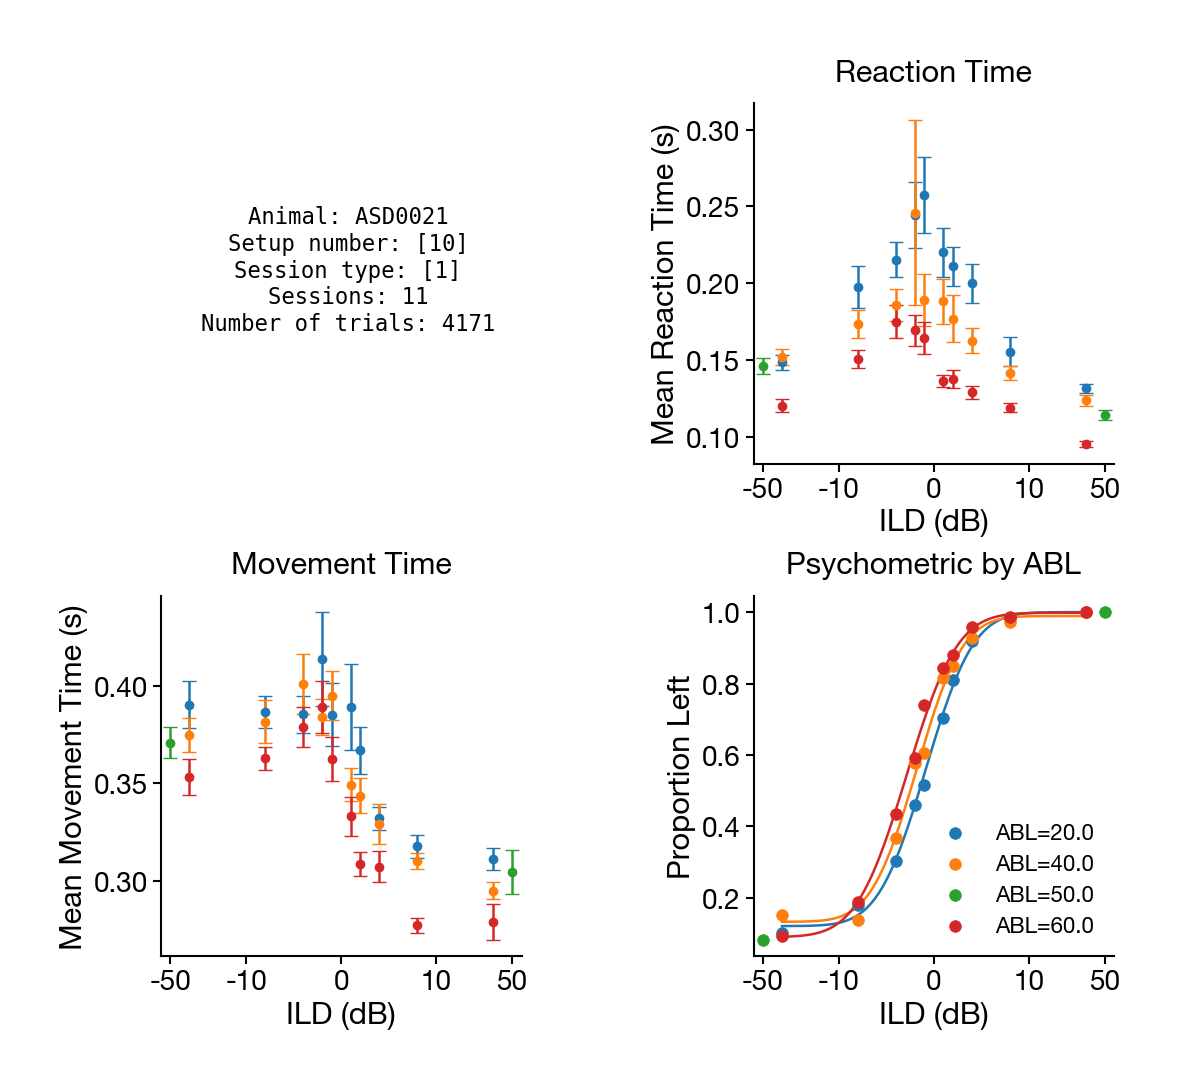

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

subject_file = "merged_ASD0021.csv"

"""



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
           d8b
           88P            d8P
          d88          d888888P
?88,.d88b,888   d8888b   ?88'   .d888b,
`?88'  ?88?88  d8P' ?88  88P    ?8b,
  88b  d8P 88b 88b  d88  88b      `?8b
  888888P'  88b`?8888P'  `?8b  `?888P'
  88P'
 d88
 ?8P

                                                    d8P
                                                 d888888P
?88,.d88b, d8888b  88bd88b      88bd88b d888b8b    ?88'
`?88'  ?88d8b_,dP  88P'  `      88P'  `d8P' ?88    88P
  88b  d8P88b     d88          d88     88b  ,88b   88b
  888888P'`?888P'd88'         d88'     `?88P'`88b  `?8b
  88P'
 d88
 ?8P
"""

# ==============================================================
# === CONFIG (Aesthetic & Behavior) =============================
# ==============================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 1.8

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
# ==============================================================
# === HELPER FUNCTIONS =========================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent styling to an axis."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_box_aspect(1)


# ==============================================================
# === LOAD DATA =================================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")

df = pd.read_csv(subject_file)

# Fix ABL values
mask = df["training_level"] < 7
df.loc[mask, "ABL"] = pd.to_numeric(df.loc[mask, "ABL"], errors="coerce") * 2
df = df[df["training_level"] == 16]

df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"]
      .astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


# Prep session data
df_last = df
#df_last, last_sessions = DataHelpers.get_last_n_sessions(df, 33)


n_trials = len(df_last)
session_type = df_last["session_type"].unique()
session_number = df_last["session"].nunique()
setup_number = df_last["box"].unique()
animal_number = df_last["animal"].iloc[0]

# ==============================================================
# === COMPUTE SUMMARY STATS =====================================
# ==============================================================
meanRT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_rt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

meanMT = (
    df_last[df_last["success"] == 1]
    .groupby(["ABL", "ILD"])["timed_mt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

results = Psychometric.compute_psychometrics_by_ABL(df_last)


# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Info text (top-left) ---
ax_text = axes[0,0]
ax_text.axis("off")
info = (
    f"Animal: {animal_number}\n"
    f"Setup number: {setup_number}\n"
    f"Session type: {session_type}\n"
    f"Sessions: {session_number}\n"
    f"Number of trials: {n_trials}\n"
)
ax_text.text(
    0.5, 0.5, info,
    fontsize=16,
    ha="center", va="center",
    family="monospace"
)


# --- RT panel (top-right) ---
for i, abl in enumerate(sorted(meanRT["ABL"].unique())):
    sub = meanRT[meanRT["ABL"] == abl]
    axes[0,1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[0,1],
    title="Reaction Time",
    xlabel="ILD (dB)",
    ylabel="Mean Reaction Time (s)"
)


# --- MT panel (bottom-left) ---
for i, abl in enumerate(sorted(meanMT["ABL"].unique())):
    sub = meanMT[meanMT["ABL"] == abl]
    axes[1,0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["std"] / np.sqrt(sub["count"]),
        label=f"ABL {abl}",
        color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH
    )

_style_axes(
    axes[1,0],
    title="Movement Time",
    xlabel="ILD (dB)",
    ylabel="Mean Movement Time (s)"
)

# --- Psychometric (bottom-right) ---
for color, (abl, res) in zip(colors, results.items()):
    axes[1,1].scatter(
        DataHelpers.shift_ILD_for_ABL50(res["ILDs"]),
        res["PropLeft"],
        label=f"ABL={abl}",
        color=color,
        s=70,
        edgecolor=color,
        linewidth=0.6,
        zorder=3,
    )
    if abl != 50:
        axes[1,1].plot(
            DataHelpers.shift_ILD_for_ABL50(res["xx"]),
            res["yy"],
            color=color,
            linewidth=LINEWIDTH
        )

_style_axes(
    axes[1,1],
    title="Psychometric by ABL",
    xlabel="ILD (dB)",
    ylabel="Proportion Left"
)

# --- Shared tick adjustments for ±50 mapping ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

axes[1,1].legend(fontsize=LEGEND_FONTSIZE, frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""

                                                                     d8P
                                                                  d888888P
 d888b8b   d888b8b   d888b8b    88bd88b d8888b d888b8b   d888b8b    ?88'   d8888b
d8P' ?88  d8P' ?88  d8P' ?88    88P'  `d8b_,dPd8P' ?88  d8P' ?88    88P   d8b_,dP
88b  ,88b 88b  ,88b 88b  ,88b  d88     88b    88b  ,88b 88b  ,88b   88b   88b
`?88P'`88b`?88P'`88b`?88P'`88bd88'     `?888P'`?88P'`88b`?88P'`88b  `?8b  `?888P'
                 )88       )88                       )88
                ,88P      ,88P                      ,88P
            `?8888P   `?8888P                   `?8888P



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
"""

"""
=============================================================
 Group Summary — with GroupComparison Aesthetics
=============================================================
"""

# ==============================================================
# === CONFIG (Aesthetic constants) =============================
# ==============================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 2.0

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
SKIP_PSY_FITS = {50}


# ==============================================================
# === HELPERS ==================================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent formatting."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_box_aspect(1)


def sem(series):
    n = series.count()
    return series.std(ddof=1) / np.sqrt(n) if n > 0 else np.nan



# ==============================================================
# === LOAD & FILTER DATA =======================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"
df = pd.read_csv(cohort_file)

df = df[df["training_level"] == 16]
df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"].astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


#Restrict animals, sex, or genotype

"""

df_sel = DataHelpers.restrict_subjects(
    df, "sex_gen.csv",
    sex="female",
    genotypes="het",
    subject_col="animal",      # omit if you want auto-detect
    attach_meta=True
)


df_sel = DataHelpers.restrict_subjects(
    df, "sex_gen.csv",
    sex="female",
    subject_col="animal",      # omit if you want auto-detect
    attach_meta=True
)
"""

# ==============================================================
# === CONTRIBUTOR STATS ========================================
# ==============================================================
contributors_overall = sorted(df[df["success"] == 1]["animal"].unique())
print(f"Overall contributors ({len(contributors_overall)}):", contributors_overall)

contributors_by_abl = (
    df[df["success"] != 0]
    .groupby("ABL")["animal"]
    .agg(lambda s: sorted(s.unique()))
    .to_dict()
)
print("\nContributors by ABL:")
for abl, subs in contributors_by_abl.items():
    print(f"  ABL {abl} (n={len(subs)}): {subs}")

# By box 
contributors_by_setup = (
    df[df["success"] != 0]
    .groupby(["box"])["animal"]
    .agg(subjects=lambda s: sorted(s.unique()),
         n_subjects=lambda s: s.nunique())
    .reset_index()
)
#print("\nContributors by setup:")
#print(contributors_by_setup.head())


# ==============================================================
# === COMPUTE GROUP METRICS ====================================
# ==============================================================

# RT
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby(["animal", "ABL", "ILD"])["timed_rt"]
    .mean()
    .reset_index(name="mean_rt")
)

meanRT_grouped = (
    meanRT_per_subject
    .groupby(["ABL", "ILD"])["mean_rt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)

# MT
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby(["animal", "ABL", "ILD"])["timed_mt"]
    .mean()
    .reset_index(name="mean_mt")
)

meanMT_grouped = (
    meanMT_per_subject
    .groupby(["ABL", "ILD"])["mean_mt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)

# Psychometric
all_subject_points = []
for subject, df_subj in df.groupby("animal"):
    results = Psychometric.compute_psychometrics_by_ABL(df_subj, model="erf_psycho")
    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_subject_points.append({
                "subject": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

points_df = pd.DataFrame(all_subject_points)
agg_points = (
    points_df.groupby(["ABL", "ILD"])["PropLeft"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)


# Fit per ABL
group_fits = {}
for abl in sorted(agg_points["ABL"].unique()):
    sub = agg_points[agg_points["ABL"] == abl]
    ILDs = shift_ILD_for_ABL50(sub["ILD"])
    PropLeft_mean = sub["mean"].values
    n_trials = np.full_like(ILDs, 50, dtype=float)
    pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
        ILDs, PropLeft_mean, model="erf_psycho", n_trials=n_trials, show_plot=False
    )
    xx = np.linspace(min(ILDs), max(ILDs), 200)
    group_fits[abl] = {
        "ILDs": ILDs,
        "mean": PropLeft_mean,
        "sem": sub["sem"].values,
        "xx": xx,
        "yy": yy
    }

# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- RT ---
for i, abl in enumerate(sorted(meanRT_grouped["ABL"].unique())):
    sub = meanRT_grouped[meanRT_grouped["ABL"] == abl]
    axes[0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["sem"], color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH,
        label=f"ABL {abl}"
    )
_style_axes(axes[0], "Mean RT", "ILD (dB)", "Mean RT (s)")
axes[0].legend(fontsize=LEGEND_FONTSIZE, frameon=False)

# --- MT ---
for i, abl in enumerate(sorted(meanMT_grouped["ABL"].unique())):
    sub = meanMT_grouped[meanMT_grouped["ABL"] == abl]
    axes[1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["sem"], color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH,
        label=f"ABL {abl}"
    )
_style_axes(axes[1], "Mean MT", "ILD (dB)", "Mean MT (s)")

# --- Psychometric ---
for i, (abl, res) in enumerate(group_fits.items()):
    axes[2].errorbar(
        res["ILDs"], res["mean"], yerr=res["sem"],
        fmt="o", color=colors[i % len(colors)],
        capsize=3, label=f"ABL {abl}"
    )
    if abl not in SKIP_PSY_FITS and "xx" in res and "yy" in res:
        axes[2].plot(res["xx"], res["yy"], color=colors[i], linewidth=LINEWIDTH)
_style_axes(axes[2], "Psychometric by ABL", "ILD (dB)", "Proportion Left")
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=LEGEND_FONTSIZE, frameon=False)

# --- Tick relabeling for ±18 ↔ ±50 ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

plt.tight_layout()
plt.show()

<ipython-input-36-a6512a02022e>:96: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)


Overall contributors (14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']

Contributors by ABL:
  ABL 20.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 40.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 50.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 60.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']

ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.

NameError: name 'shift_ILD_for_ABL50' is not defined

<ipython-input-37-d4b0d7d1178d>:96: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)


Overall contributors (14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']

Contributors by ABL:
  ABL 20.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 40.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 50.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']
  ABL 60.0 (n=14): ['ASD0007', 'ASD0008', 'ASD0009', 'ASD0010', 'ASD0011', 'ASD0012', 'ASD0014', 'ASD0015', 'ASD0016', 'ASD0017', 'ASD0018', 'ASD0019', 'ASD0020', 'ASD0021']

ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.

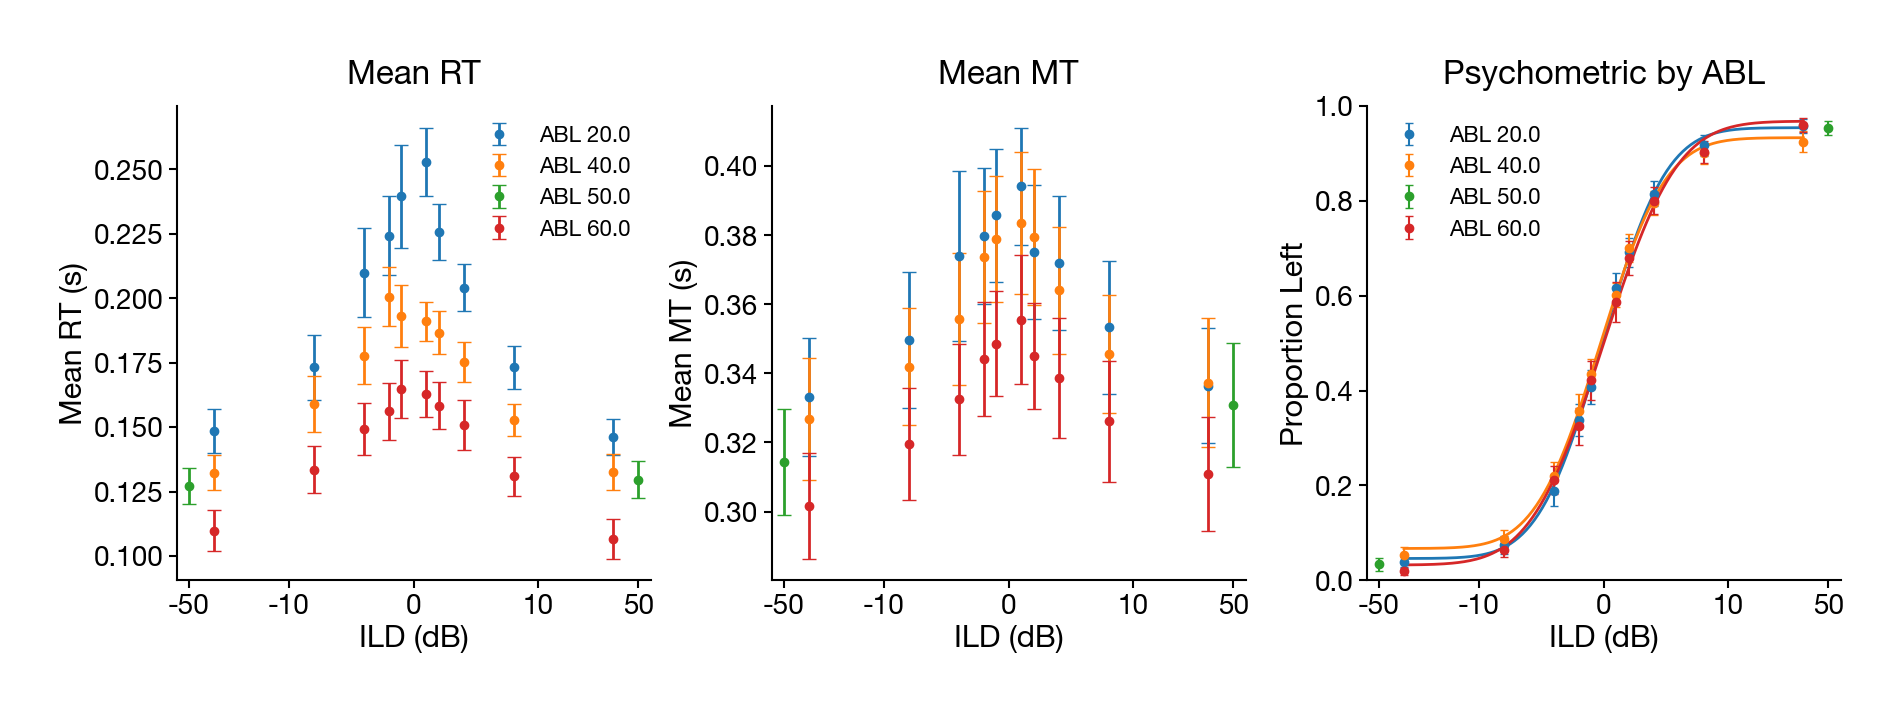

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Psychometric 
import DataHelpers
import matplotlib as mpl

"""

                                                                     d8P
                                                                  d888888P
 d888b8b   d888b8b   d888b8b    88bd88b d8888b d888b8b   d888b8b    ?88'   d8888b
d8P' ?88  d8P' ?88  d8P' ?88    88P'  `d8b_,dPd8P' ?88  d8P' ?88    88P   d8b_,dP
88b  ,88b 88b  ,88b 88b  ,88b  d88     88b    88b  ,88b 88b  ,88b   88b   88b
`?88P'`88b`?88P'`88b`?88P'`88bd88'     `?888P'`?88P'`88b`?88P'`88b  `?8b  `?888P'
                 )88       )88                       )88
                ,88P      ,88P                      ,88P
            `?8888P   `?8888P                   `?8888P



 .d888b,?88   d8P  88bd8b,d88b   88bd8b,d88b  d888b8b    88bd88b?88   d8P
 ?8b,   d88   88   88P'`?8P'?8b  88P'`?8P'?8bd8P' ?88    88P'  `d88   88
   `?8b ?8(  d88  d88  d88  88P d88  d88  88P88b  ,88b  d88     ?8(  d88
`?888P' `?88P'?8bd88' d88'  88bd88' d88'  88b`?88P'`88bd88'     `?88P'?8b
                                                                       )88
                                                                      ,d8P
                                                                   `?888P'
"""

"""
=============================================================
 Group Summary — with GroupComparison Aesthetics
=============================================================
"""

# ==============================================================
# === CONFIG (Aesthetic constants) =============================
# ==============================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 2.0

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

colors = ["C0", "C1", "C2", "C3"]
SKIP_PSY_FITS = {50}


# ==============================================================
# === HELPERS ==================================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent formatting."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_box_aspect(1)


def sem(series):
    n = series.count()
    return series.std(ddof=1) / np.sqrt(n) if n > 0 else np.nan



# ==============================================================
# === LOAD & FILTER DATA =======================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"
df = pd.read_csv(cohort_file)

df = df[df["training_level"] == 16]
df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

mask_false = (
    df["repeated_trial"].astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]


#Restrict animals, sex, or genotype

"""

df_sel = DataHelpers.restrict_subjects(
    df, "sex_gen.csv",
    sex="female",
    genotypes="het",
    subject_col="animal",      # omit if you want auto-detect
    attach_meta=True
)


df_sel = DataHelpers.restrict_subjects(
    df, "sex_gen.csv",
    sex="female",
    subject_col="animal",      # omit if you want auto-detect
    attach_meta=True
)
"""

# ==============================================================
# === CONTRIBUTOR STATS ========================================
# ==============================================================
contributors_overall = sorted(df[df["success"] == 1]["animal"].unique())
print(f"Overall contributors ({len(contributors_overall)}):", contributors_overall)

contributors_by_abl = (
    df[df["success"] != 0]
    .groupby("ABL")["animal"]
    .agg(lambda s: sorted(s.unique()))
    .to_dict()
)
print("\nContributors by ABL:")
for abl, subs in contributors_by_abl.items():
    print(f"  ABL {abl} (n={len(subs)}): {subs}")

# By box 
contributors_by_setup = (
    df[df["success"] != 0]
    .groupby(["box"])["animal"]
    .agg(subjects=lambda s: sorted(s.unique()),
         n_subjects=lambda s: s.nunique())
    .reset_index()
)
#print("\nContributors by setup:")
#print(contributors_by_setup.head())


# ==============================================================
# === COMPUTE GROUP METRICS ====================================
# ==============================================================

# RT
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby(["animal", "ABL", "ILD"])["timed_rt"]
    .mean()
    .reset_index(name="mean_rt")
)

meanRT_grouped = (
    meanRT_per_subject
    .groupby(["ABL", "ILD"])["mean_rt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)

# MT
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby(["animal", "ABL", "ILD"])["timed_mt"]
    .mean()
    .reset_index(name="mean_mt")
)

meanMT_grouped = (
    meanMT_per_subject
    .groupby(["ABL", "ILD"])["mean_mt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)

# Psychometric
all_subject_points = []
for subject, df_subj in df.groupby("animal"):
    results = Psychometric.compute_psychometrics_by_ABL(df_subj, model="erf_psycho")
    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_subject_points.append({
                "subject": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

points_df = pd.DataFrame(all_subject_points)
agg_points = (
    points_df.groupby(["ABL", "ILD"])["PropLeft"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)


# Fit per ABL
group_fits = {}
for abl in sorted(agg_points["ABL"].unique()):
    sub = agg_points[agg_points["ABL"] == abl]
    ILDs = DataHelpers.shift_ILD_for_ABL50(sub["ILD"])
    PropLeft_mean = sub["mean"].values
    n_trials = np.full_like(ILDs, 50, dtype=float)
    pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
        ILDs, PropLeft_mean, model="erf_psycho", n_trials=n_trials, show_plot=False
    )
    xx = np.linspace(min(ILDs), max(ILDs), 200)
    group_fits[abl] = {
        "ILDs": ILDs,
        "mean": PropLeft_mean,
        "sem": sub["sem"].values,
        "xx": xx,
        "yy": yy
    }

# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- RT ---
for i, abl in enumerate(sorted(meanRT_grouped["ABL"].unique())):
    sub = meanRT_grouped[meanRT_grouped["ABL"] == abl]
    axes[0].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["sem"], color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH,
        label=f"ABL {abl}"
    )
_style_axes(axes[0], "Mean RT", "ILD (dB)", "Mean RT (s)")
axes[0].legend(fontsize=LEGEND_FONTSIZE, frameon=False)

# --- MT ---
for i, abl in enumerate(sorted(meanMT_grouped["ABL"].unique())):
    sub = meanMT_grouped[meanMT_grouped["ABL"] == abl]
    axes[1].errorbar(
        DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"],
        yerr=sub["sem"], color=colors[i % len(colors)],
        linestyle="none", marker="o", capsize=5, linewidth=LINEWIDTH,
        label=f"ABL {abl}"
    )
_style_axes(axes[1], "Mean MT", "ILD (dB)", "Mean MT (s)")

# --- Psychometric ---
for i, (abl, res) in enumerate(group_fits.items()):
    axes[2].errorbar(
        res["ILDs"], res["mean"], yerr=res["sem"],
        fmt="o", color=colors[i % len(colors)],
        capsize=3, label=f"ABL {abl}"
    )
    if abl not in SKIP_PSY_FITS and "xx" in res and "yy" in res:
        axes[2].plot(res["xx"], res["yy"], color=colors[i], linewidth=LINEWIDTH)
_style_axes(axes[2], "Psychometric by ABL", "ILD (dB)", "Proportion Left")
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=LEGEND_FONTSIZE, frameon=False)

# --- Tick relabeling for ±18 ↔ ±50 ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

plt.tight_layout()
plt.show()

<ipython-input-38-05b129c3a0a2>:22: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)
<ipython-input-38-05b129c3a0a2>:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(PALETTE)



ABL=20.0, n_trials=1508
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [154 141 160 189 155 144 141 136 139 149]

ABL=40.0, n_trials=1410
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [148 152 139 137 142 130 158 120 107 177]

ABL=50.0, n_trials=239
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [124 115]

ABL=60.0, n_trials=1540
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.9795918

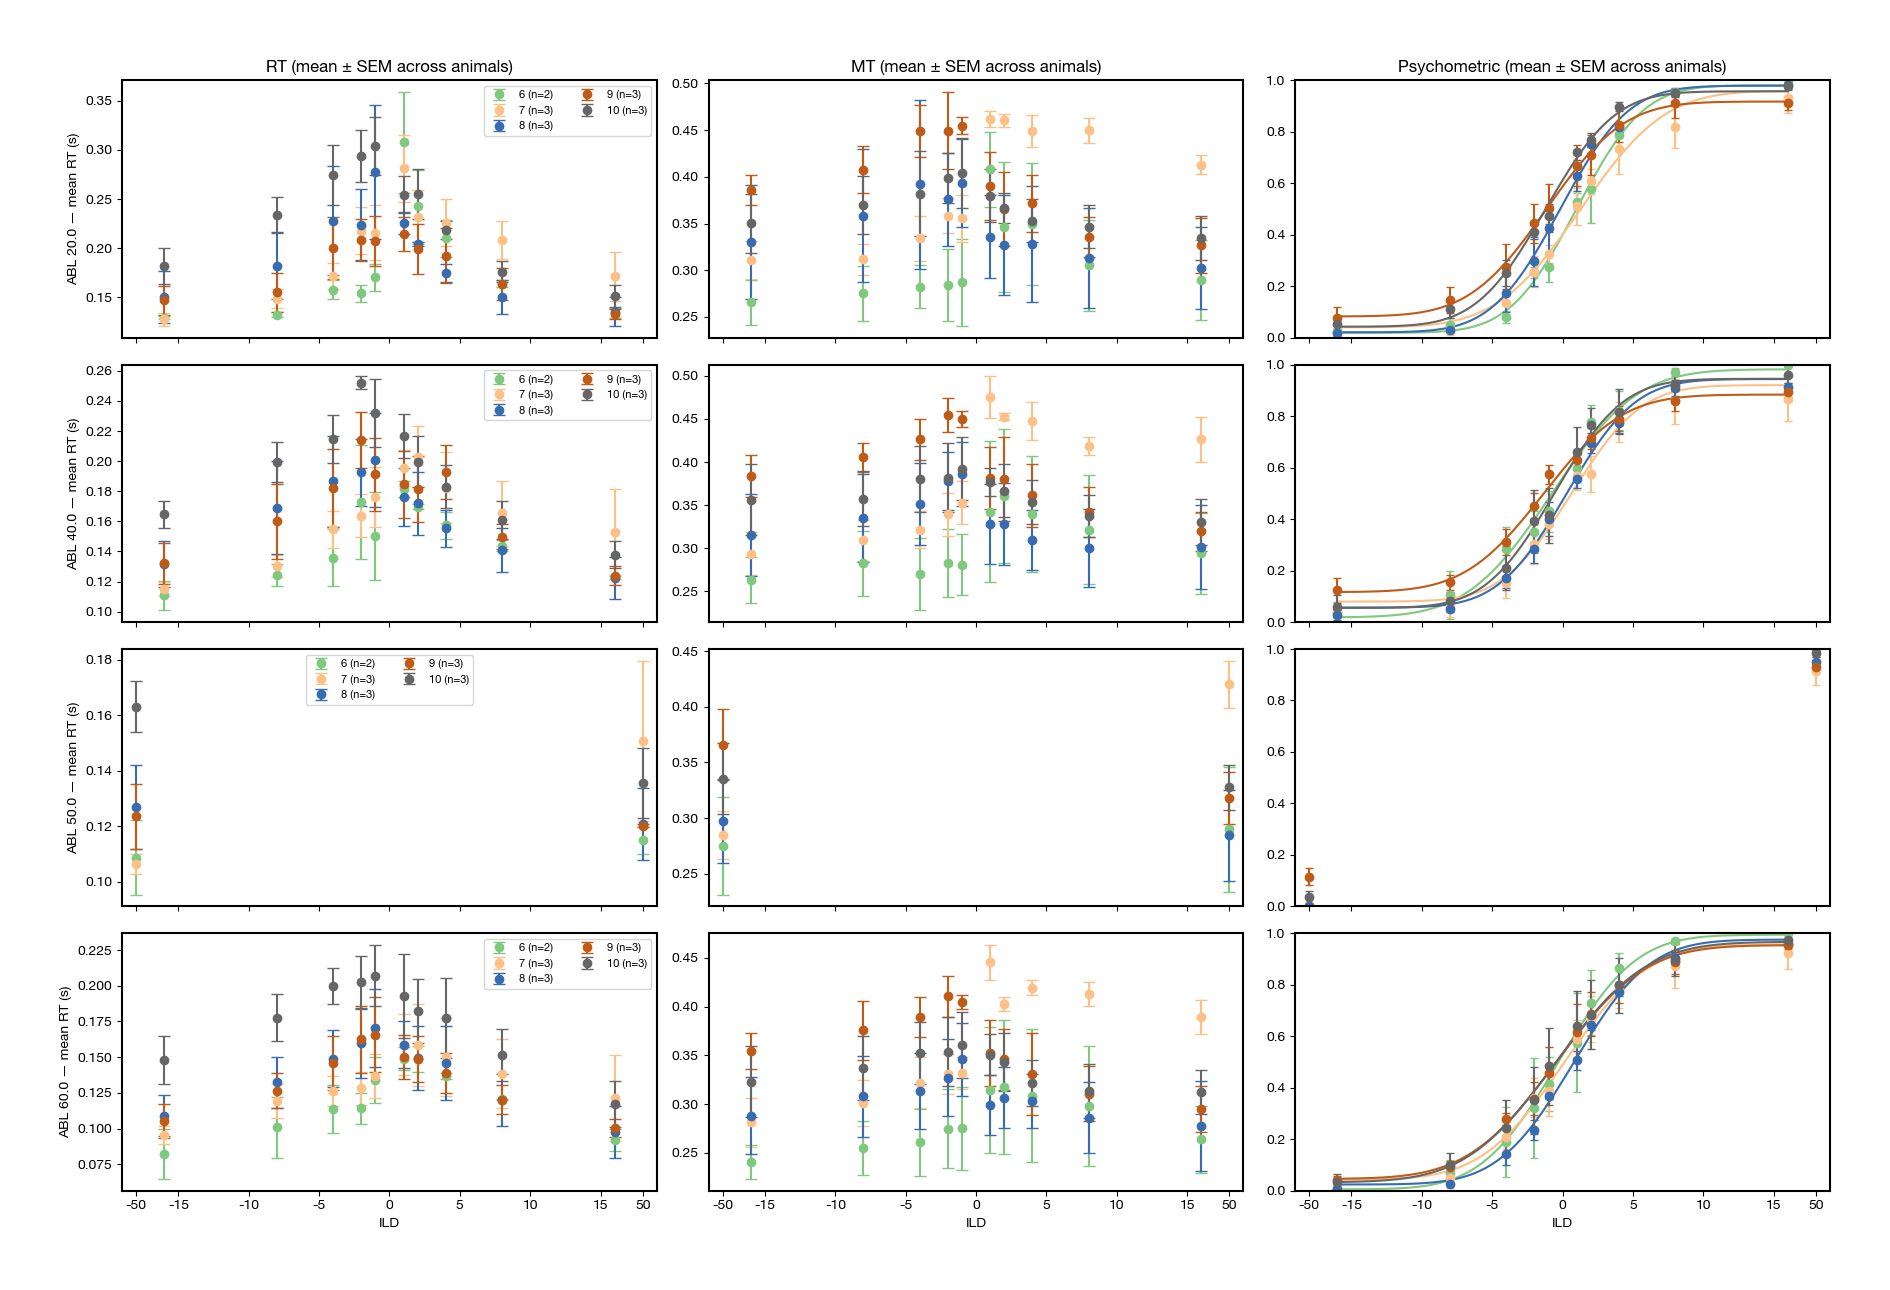

In [ ]:
"""

                                                d8P
                                             d888888P
?88,.d88b, d8888b  88bd88b     .d888b, d8888b  ?88'  ?88   d8P?88,.d88b,
`?88'  ?88d8b_,dP  88P'  `     ?8b,   d8b_,dP  88P   d88   88 `?88'  ?88
  88b  d8P88b     d88            `?8b 88b      88b   ?8(  d88   88b  d8P
  888888P'`?888P'd88'         `?888P' `?888P'  `?8b  `?88P'?8b  888888P'
  88P'                                                          88P'
 d88                                                           d88
 ?8P                                                           ?8P
"""

# ---------------- Config ----------------
SETUP_COL = "box" 

os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"

df = pd.read_csv(cohort_file)

#Restrict training level
df = df[(df["training_level"] == 16)]

#Mask ABL 59 to 60dB
mask2 = df["ABL"] == 59
df.loc[mask2, "ABL"] = 60

#Mask lateralized sound as 50dB
mask3 = (df["training_level"] == 16) & (df["ABL"] == 25)
df.loc[mask3, "ABL"] = 50

#Restrict session number
df = df[df["session"]>=13] # restricting session!!

# Make sure setup column exists
if SETUP_COL not in df.columns:
    raise KeyError(f"'{SETUP_COL}' column not found in dataframe. Set SETUP_COL accordingly.")

# Orderings
ABLs = sorted(df["ABL"].unique())
setups = sorted(df[SETUP_COL].dropna().unique())

# ----- choose a palette -----
# Good categorical options: "Set2", "tab10", "Dark2", "Accent", "tab20", "Paired"
# (continuous but nice: "viridis", "plasma", "turbo")
PALETTE = "Accent"

setups = sorted(df[SETUP_COL].dropna().unique())  # you already have this earlier
N = len(setups)

cmap = plt.cm.get_cmap(PALETTE)
color_for_setup = {s: cmap(i / max(N - 1, 1)) for i, s in enumerate(setups)}


# ---------------- Helpers ----------------
def sem(series):
    n = series.count()
    return series.std(ddof=1) / np.sqrt(n) if n > 0 else np.nan

# ---------------- RT per setup (mean across animals) ----------------
# 1) per-subject means within setup
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_rt"]
    .mean()
    .reset_index(name="mean_rt")
)

# 2) across-subject aggregation within setup (mean ± SEM across animals)

meanRT_setup = (
    meanRT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_rt"]
    .agg(mean="mean", sem=sem, n_subj="count")  # <-- no tuple here
    .reset_index()
)

# For legend counts: unique animals contributing per setup×ABL
rt_counts = (
    meanRT_per_subject.groupby([SETUP_COL, "ABL"])["animal"]
    .nunique()
    .to_dict()
)

# ---------------- MT per setup (mean across animals) ----------------
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_mt"]
    .mean()
    .reset_index(name="mean_mt")
)

meanMT_setup = (
    meanMT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_mt"]
    .agg(mean="mean", sem=sem, n_subj=("count"))
    .reset_index()
)

mt_counts = (
    meanMT_per_subject.groupby([SETUP_COL, "ABL"])["animal"]
    .nunique()
    .to_dict()
)

# ---------------- Psychometric per setup ----------------
# Compute per-(setup, subject) psychometric, then aggregate across subjects within setup
all_points = []
for (setup, subject), df_ss in df.groupby([SETUP_COL, "animal"]):
    results = Psychometric.compute_psychometrics_by_ABL(df_ss, model="erf_psycho")
    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_points.append({
                SETUP_COL: setup,
                "animal": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

points_df = pd.DataFrame(all_points)

agg_points_setup = (
    points_df
    .groupby([SETUP_COL, "ABL", "ILD"])["PropLeft"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)

psy_counts = (
    points_df.groupby([SETUP_COL, "ABL"])["animal"]
    .nunique()
    .to_dict()
)

# Fit curves per ABL × setup for the psychometric
group_fits = {abl: {} for abl in ABLs}
for abl in ABLs:
    for setup in setups:
        sub = agg_points_setup[(agg_points_setup["ABL"] == abl) & (agg_points_setup[SETUP_COL] == setup)]
        if sub.empty: 
            continue
        ILDs = DataHelpers.shift_ILD_for_ABL50(sub["ILD"])
        PropLeft_mean = sub["mean"].values
        # dummy n_trials per ILD; replace with real totals if you have them
        n_trials = np.full_like(ILDs, 50, dtype=float)

        pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
            ILDs, PropLeft_mean,
            model="erf_psycho",
            n_trials=n_trials,
            show_plot=False
        )
        xx = np.linspace(np.min(ILDs), np.max(ILDs), 200)

        group_fits[abl][setup] = {
            "ILDs": ILDs,
            "mean": PropLeft_mean,
            "sem": sub["sem"].values,
            "xx": xx,
            "yy": yy
        }

# ---------------- Plot: 3 (ABLs) × 3 (RT, MT, Psychometric) ----------------
fig, axes = plt.subplots(len(ABLs), 3, figsize=(18, 12), sharex='col')
if len(ABLs) == 1:
    axes = np.array([axes])  # ensure 2D

for r, abl in enumerate(ABLs):
    # RT
    ax = axes[r, 0]
    for j, setup in enumerate(setups):
        sub = meanRT_setup[(meanRT_setup["ABL"] == abl) & (meanRT_setup[SETUP_COL] == setup)]
        if sub.empty: 
            continue
        n_subs = rt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup],
            linestyle="none", marker="o", capsize=4
        )
    if r == 0:
        ax.set_title("RT (mean ± SEM across animals)")
    ax.set_ylabel(f"ABL {abl} — mean RT (s)")
    if r == len(ABLs) - 1:
        ax.set_xlabel("ILD")
    ax.legend(fontsize=8)

    # MT
    ax = axes[r, 1]
    for j, setup in enumerate(setups):
        sub = meanMT_setup[(meanMT_setup["ABL"] == abl) & (meanMT_setup[SETUP_COL] == setup)]
        if sub.empty: 
            continue
        n_subs = mt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup],
            linestyle="none", marker="o", capsize=4
        )
    if r == 0:
        ax.set_title("MT (mean ± SEM across animals)")
    if r == len(ABLs) - 1:
        ax.set_xlabel("ILD")

    # Psychometric
    ax = axes[r, 2]
    skip_fit = {50}
    for j, setup in enumerate(setups):
        res = group_fits.get(abl, {}).get(setup, None)
        if res is None:
            continue
        n_subs = psy_counts.get((setup, abl), 0)
        # points
        order = np.argsort(res["ILDs"])
        ax.errorbar(
            np.array(res["ILDs"])[order], np.array(res["mean"])[order],
            yerr=np.array(res["sem"])[order],
            fmt="o", color=color_for_setup[setup], capsize=3,
            label=f"{setup} (n={n_subs})" if r == 0 else None  # avoid duplicate labels per column row
        )
        # curve
        if abl not in skip_fit and "xx" in res and "yy" in res:
            ax.plot(res["xx"], res["yy"], color=color_for_setup[setup])
    if r == 0:
        ax.set_title("Psychometric (mean ± SEM across animals)")
    ax.set_ylim(0, 1)
    if r == len(ABLs) - 1:
        ax.set_xlabel("ILD")

# Clean up legends: show them on each row's first panel (RT) for clarity
for r in range(len(ABLs)):
    axes[r, 0].legend(fontsize=8, ncol=2)
    axes[r, 1].legend().remove() if axes[r, 1].get_legend() else None
    axes[r, 2].legend().remove() if axes[r, 2].get_legend() else None

for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else
        "50" if x == 18 else
        str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)


plt.tight_layout()
plt.show()

<ipython-input-39-734a882c410a>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)
<ipython-input-39-734a882c410a>:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(PALETTE)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

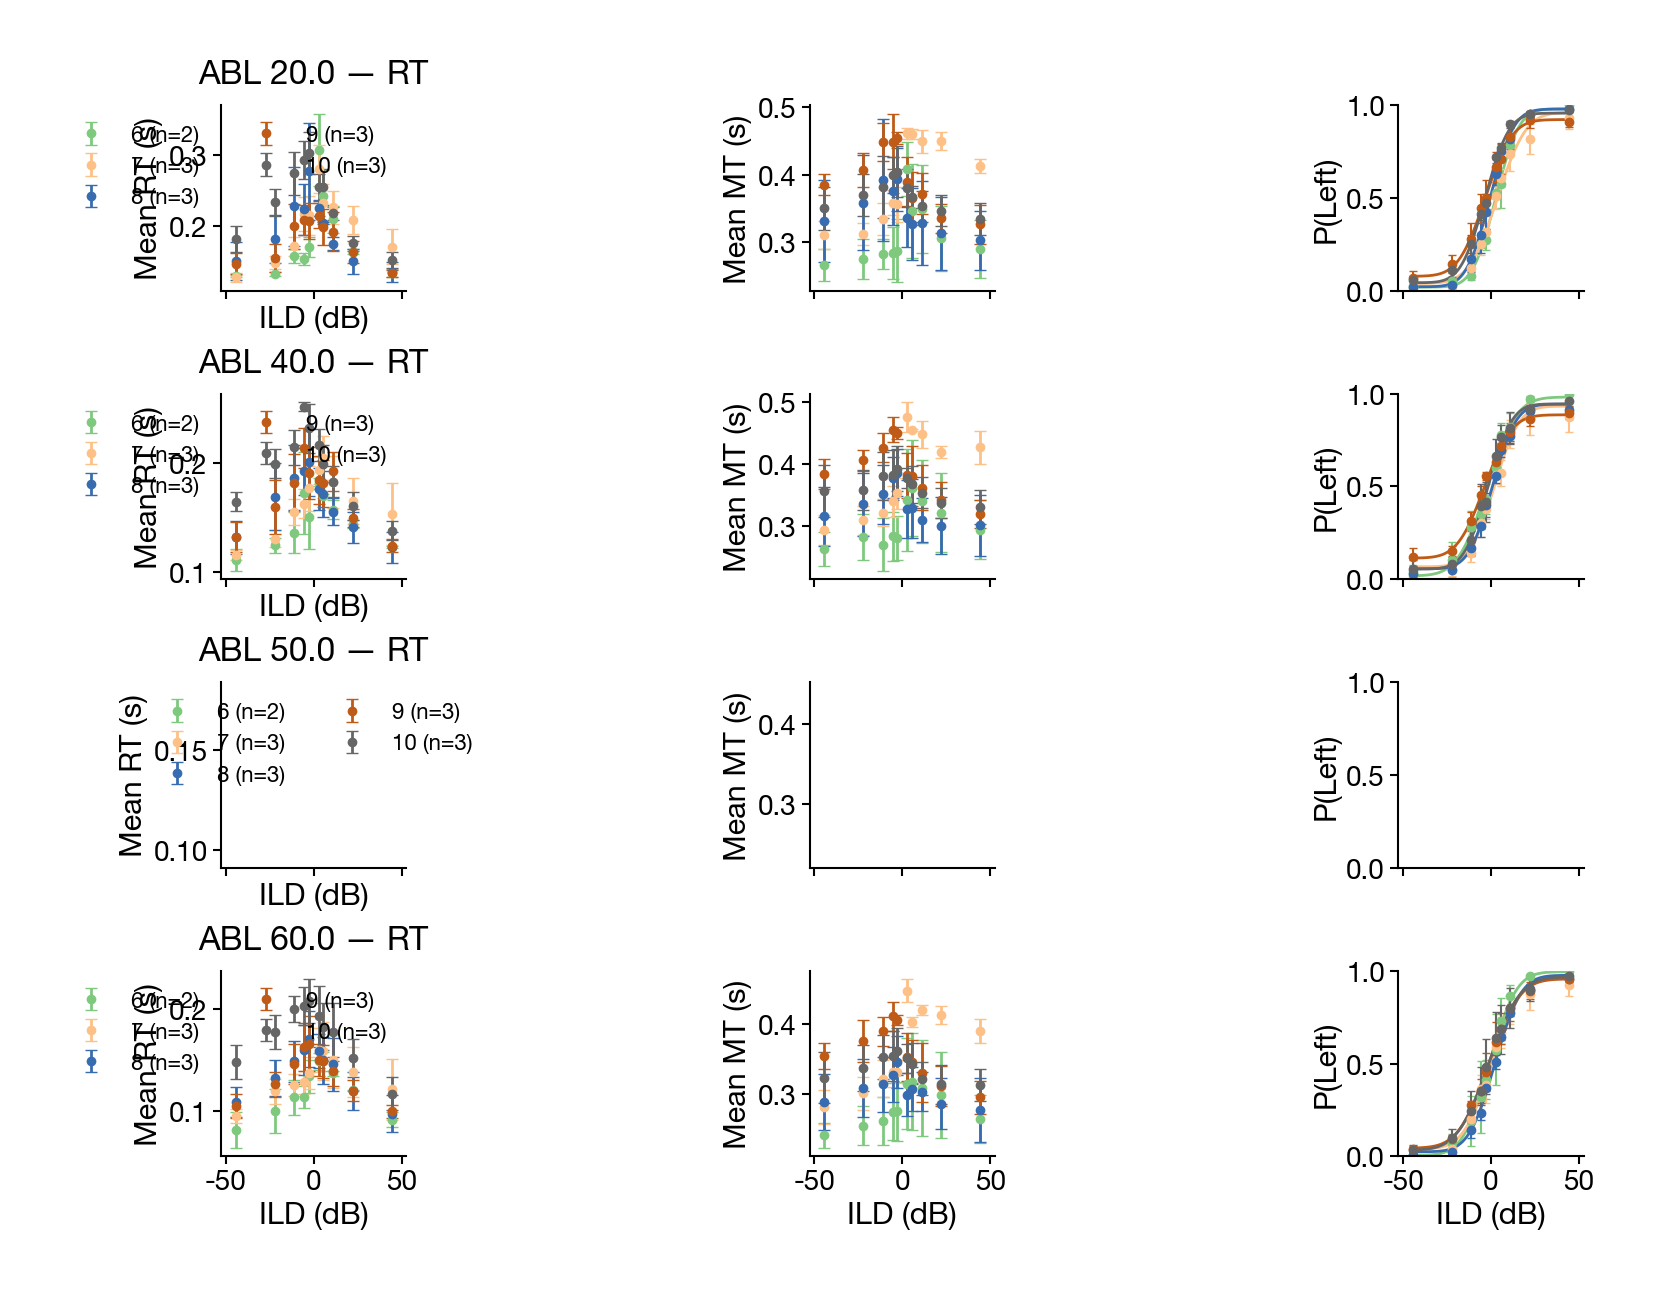

In [ ]:
"""

                                                d8P
                                             d888888P
?88,.d88b, d8888b  88bd88b     .d888b, d8888b  ?88'  ?88   d8P?88,.d88b,
`?88'  ?88d8b_,dP  88P'  `     ?8b,   d8b_,dP  88P   d88   88 `?88'  ?88
  88b  d8P88b     d88            `?8b 88b      88b   ?8(  d88   88b  d8P
  888888P'`?888P'd88'         `?888P' `?888P'  `?8b  `?88P'?8b  888888P'
  88P'                                                          88P'
 d88                                                           d88
 ?8P                                                           ?8P
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import Psychometric
import DataHelpers

"""
=============================================================
 Group-by-Setup Summary — with GroupComparison Aesthetics
=============================================================
"""


# ----- choose a palette -----
# Good categorical options: "Set2", "tab10", "Dark2", "Accent", "tab20", "Paired"
# (continuous but nice: "viridis", "plasma", "turbo")


# ==============================================================
# === CONFIG ===================================================
# ==============================================================
SETUP_COL = "box"
PALETTE = "Accent"
SKIP_PSY_FITS = {50}

TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 2.0

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ==============================================================
# === STYLE HELPERS ============================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent formatting."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_box_aspect(1)



def sem(series):
    n = series.count()
    return series.std(ddof=1) / np.sqrt(n) if n > 0 else np.nan


# ==============================================================
# === LOAD & FILTER DATA =======================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"
df = pd.read_csv(cohort_file)

df = df[df["training_level"] == 16]
df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

if SETUP_COL not in df.columns:
    raise KeyError(f"'{SETUP_COL}' column not found in dataframe.")

mask_false = (
    df["repeated_trial"].astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]

ABLs = sorted(df["ABL"].unique())
setups = sorted(df[SETUP_COL].dropna().unique())

# Color map per setup
cmap = plt.cm.get_cmap(PALETTE)
color_for_setup = {s: cmap(i / max(len(setups) - 1, 1)) for i, s in enumerate(setups)}


# ==============================================================
# === COMPUTE STATS ============================================
# ==============================================================
# --- RT ---
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_rt"]
    .mean()
    .reset_index(name="mean_rt")
)
meanRT_setup = (
    meanRT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_rt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
rt_counts = meanRT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- MT ---
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_mt"]
    .mean()
    .reset_index(name="mean_mt")
)
meanMT_setup = (
    meanMT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_mt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
mt_counts = meanMT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()

# --- Psychometric ---
all_points = []
for (setup, subject), df_ss in df.groupby([SETUP_COL, "animal"]):
    results = Psychometric.compute_psychometrics_by_ABL(df_ss, model="erf_psycho")
    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_points.append({
                SETUP_COL: setup,
                "animal": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

points_df = pd.DataFrame(all_points)
agg_points_setup = (
    points_df
    .groupby([SETUP_COL, "ABL", "ILD"])["PropLeft"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
psy_counts = points_df.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- Fit curves per ABL × setup ---
group_fits = {abl: {} for abl in ABLs}
for abl in ABLs:
    for setup in setups:
        sub = agg_points_setup[(agg_points_setup["ABL"] == abl) & (agg_points_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        ILDs =sub["ILD"]
        PropLeft_mean = sub["mean"].values
        n_trials = np.full_like(ILDs, 50, dtype=float)
        pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
            ILDs, PropLeft_mean, model="erf_psycho", n_trials=n_trials, show_plot=False
        )
        xx = np.linspace(np.min(ILDs), np.max(ILDs), 200)
        group_fits[abl][setup] = {
            "ILDs": ILDs, "mean": PropLeft_mean, "sem": sub["sem"].values,
            "xx": xx, "yy": yy
        }
# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
fig, axes = plt.subplots(len(ABLs), 3, figsize=(18, 12), sharex="col")
if len(ABLs) == 1:
    axes = np.array([axes])  # ensure 2D for single row

for r, abl in enumerate(ABLs):
    # --- RT ---
    ax = axes[r, 0]
    for setup in setups:
        sub = meanRT_setup[(meanRT_setup["ABL"] == abl) & (meanRT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = rt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            sub["ILD"], sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, f"ABL {abl} — RT", "ILD (dB)", "Mean RT (s)")

    # --- MT ---
    ax = axes[r, 1]
    for setup in setups:
        sub = meanMT_setup[(meanMT_setup["ABL"] == abl) & (meanMT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = mt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            sub["ILD"], sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "Mean MT (s)")


    # --- Psychometric ---
    ax = axes[r, 2]
    for setup in setups:
        res = group_fits.get(abl, {}).get(setup, None)
        if res is None:
            continue
        n_subs = psy_counts.get((setup, abl), 0)
        order = np.argsort(res["ILDs"])
        ax.errorbar(
            np.array(res["ILDs"])[order], np.array(res["mean"])[order],
            yerr=np.array(res["sem"])[order],
            fmt="o", color=color_for_setup[setup], capsize=3,
            label=f"{setup} (n={n_subs})" if r == 0 else None
        )
        if abl not in SKIP_PSY_FITS and "xx" in res and "yy" in res:
            ax.plot(res["xx"], res["yy"], color=color_for_setup[setup], linewidth=LINEWIDTH)
    ax.set_ylim(0, 1)
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "P(Left)")

# --- Shared formatting ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else "50" if x == 18 else str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

# --- Legends per row (on RT panels only) ---
for r in range(len(ABLs)):
    axes[r, 0].legend(fontsize=LEGEND_FONTSIZE, ncol=2, frameon=False)
    if axes[r, 1].get_legend(): axes[r, 1].get_legend().remove()
    if axes[r, 2].get_legend(): axes[r, 2].get_legend().remove()

plt.tight_layout()
plt.show()

<ipython-input-40-9de5b8605451>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)
<ipython-input-40-9de5b8605451>:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(PALETTE)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

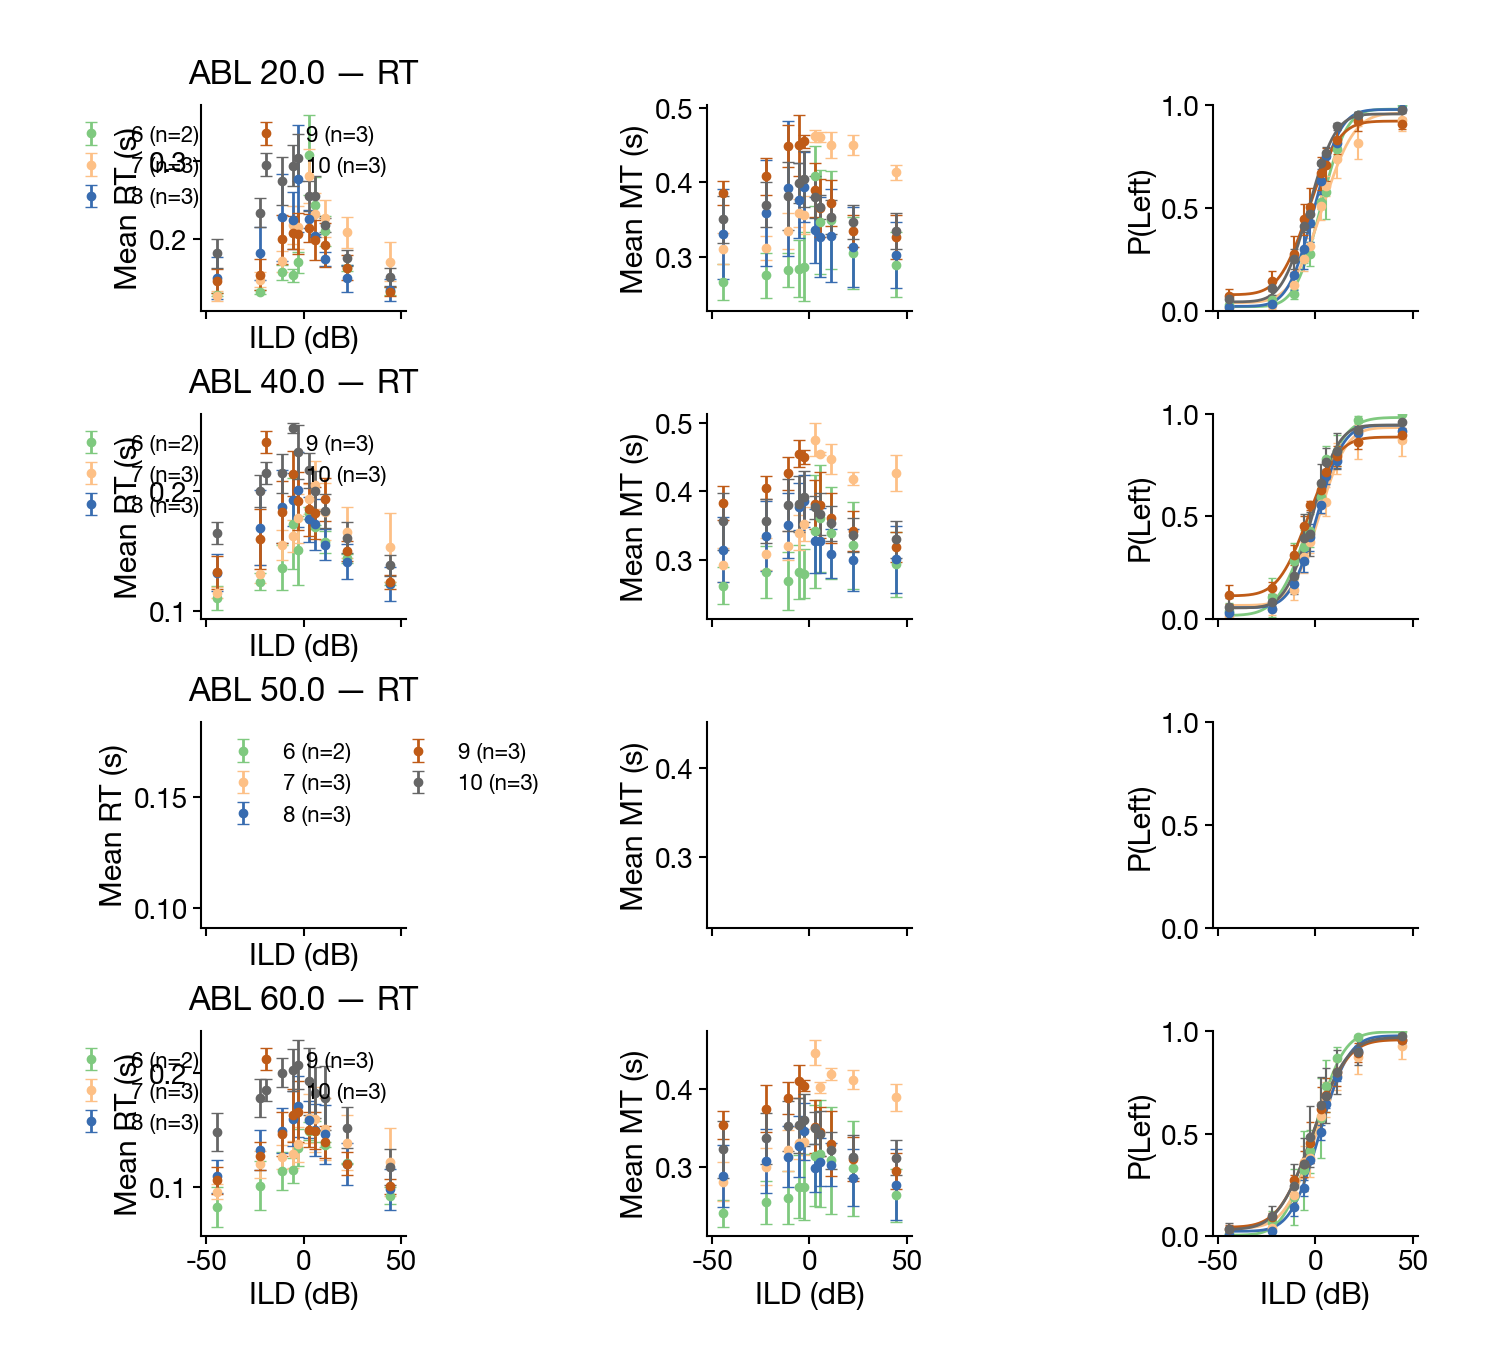

In [ ]:
"""

                                                d8P
                                             d888888P
?88,.d88b, d8888b  88bd88b     .d888b, d8888b  ?88'  ?88   d8P?88,.d88b,
`?88'  ?88d8b_,dP  88P'  `     ?8b,   d8b_,dP  88P   d88   88 `?88'  ?88
  88b  d8P88b     d88            `?8b 88b      88b   ?8(  d88   88b  d8P
  888888P'`?888P'd88'         `?888P' `?888P'  `?8b  `?88P'?8b  888888P'
  88P'                                                          88P'
 d88                                                           d88
 ?8P                                                           ?8P
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import Psychometric
import DataHelpers

"""
=============================================================
 Group-by-Setup Summary — with GroupComparison Aesthetics
=============================================================
"""


# ----- choose a palette -----
# Good categorical options: "Set2", "tab10", "Dark2", "Accent", "tab20", "Paired"
# (continuous but nice: "viridis", "plasma", "turbo")


# ==============================================================
# === CONFIG ===================================================
# ==============================================================
SETUP_COL = "box"
PALETTE = "Accent"
SKIP_PSY_FITS = {50}

TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 2.0

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ==============================================================
# === STYLE HELPERS ============================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent formatting."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_box_aspect(1)



def sem(series):
    n = series.count()
    return series.std(ddof=1) / np.sqrt(n) if n > 0 else np.nan


# ==============================================================
# === LOAD & FILTER DATA =======================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"
df = pd.read_csv(cohort_file)

df = df[df["training_level"] == 16]
df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

if SETUP_COL not in df.columns:
    raise KeyError(f"'{SETUP_COL}' column not found in dataframe.")

mask_false = (
    df["repeated_trial"].astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]

ABLs = sorted(df["ABL"].unique())
setups = sorted(df[SETUP_COL].dropna().unique())

# Color map per setup
cmap = plt.cm.get_cmap(PALETTE)
color_for_setup = {s: cmap(i / max(len(setups) - 1, 1)) for i, s in enumerate(setups)}


# ==============================================================
# === COMPUTE STATS ============================================
# ==============================================================
# --- RT ---
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_rt"]
    .mean()
    .reset_index(name="mean_rt")
)
meanRT_setup = (
    meanRT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_rt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
rt_counts = meanRT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- MT ---
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_mt"]
    .mean()
    .reset_index(name="mean_mt")
)
meanMT_setup = (
    meanMT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_mt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
mt_counts = meanMT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()

# --- Psychometric ---
all_points = []
for (setup, subject), df_ss in df.groupby([SETUP_COL, "animal"]):
    results = Psychometric.compute_psychometrics_by_ABL(df_ss, model="erf_psycho")
    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_points.append({
                SETUP_COL: setup,
                "animal": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

points_df = pd.DataFrame(all_points)
agg_points_setup = (
    points_df
    .groupby([SETUP_COL, "ABL", "ILD"])["PropLeft"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
psy_counts = points_df.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- Fit curves per ABL × setup ---
group_fits = {abl: {} for abl in ABLs}
for abl in ABLs:
    for setup in setups:
        sub = agg_points_setup[(agg_points_setup["ABL"] == abl) & (agg_points_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        ILDs =sub["ILD"]
        PropLeft_mean = sub["mean"].values
        n_trials = np.full_like(ILDs, 50, dtype=float)
        pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
            ILDs, PropLeft_mean, model="erf_psycho", n_trials=n_trials, show_plot=False
        )
        xx = np.linspace(np.min(ILDs), np.max(ILDs), 200)
        group_fits[abl][setup] = {
            "ILDs": ILDs, "mean": PropLeft_mean, "sem": sub["sem"].values,
            "xx": xx, "yy": yy
        }
# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
# Keep each panel compact: ~5.5×3.2 inches per panel
panel_w, panel_h = 5.5, 3.2
fig_height = panel_h * len(ABLs)
fig_width = panel_w * 3
fig, axes = plt.subplots(len(ABLs), 3, figsize=(fig_width, fig_height), sharex="col")

if len(ABLs) == 1:
    axes = np.array([axes])  # ensure 2D for single row

for r, abl in enumerate(ABLs):
    # --- RT ---
    ax = axes[r, 0]
    for setup in setups:
        sub = meanRT_setup[(meanRT_setup["ABL"] == abl) & (meanRT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = rt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            sub["ILD"], sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, f"ABL {abl} — RT", "ILD (dB)", "Mean RT (s)")

    # --- MT ---
    ax = axes[r, 1]
    for setup in setups:
        sub = meanMT_setup[(meanMT_setup["ABL"] == abl) & (meanMT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = mt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            sub["ILD"], sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "Mean MT (s)")


    # --- Psychometric ---
    ax = axes[r, 2]
    for setup in setups:
        res = group_fits.get(abl, {}).get(setup, None)
        if res is None:
            continue
        n_subs = psy_counts.get((setup, abl), 0)
        order = np.argsort(res["ILDs"])
        ax.errorbar(
            np.array(res["ILDs"])[order], np.array(res["mean"])[order],
            yerr=np.array(res["sem"])[order],
            fmt="o", color=color_for_setup[setup], capsize=3,
            label=f"{setup} (n={n_subs})" if r == 0 else None
        )
        if abl not in SKIP_PSY_FITS and "xx" in res and "yy" in res:
            ax.plot(res["xx"], res["yy"], color=color_for_setup[setup], linewidth=LINEWIDTH)
    ax.set_ylim(0, 1)
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "P(Left)")

# --- Shared formatting ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else "50" if x == 18 else str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

# --- Legends per row (on RT panels only) ---
for r in range(len(ABLs)):
    axes[r, 0].legend(fontsize=LEGEND_FONTSIZE, ncol=2, frameon=False)
    if axes[r, 1].get_legend(): axes[r, 1].get_legend().remove()
    if axes[r, 2].get_legend(): axes[r, 2].get_legend().remove()

plt.tight_layout()
plt.show()

<ipython-input-41-72bf28690614>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)
<ipython-input-41-72bf28690614>:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(PALETTE)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

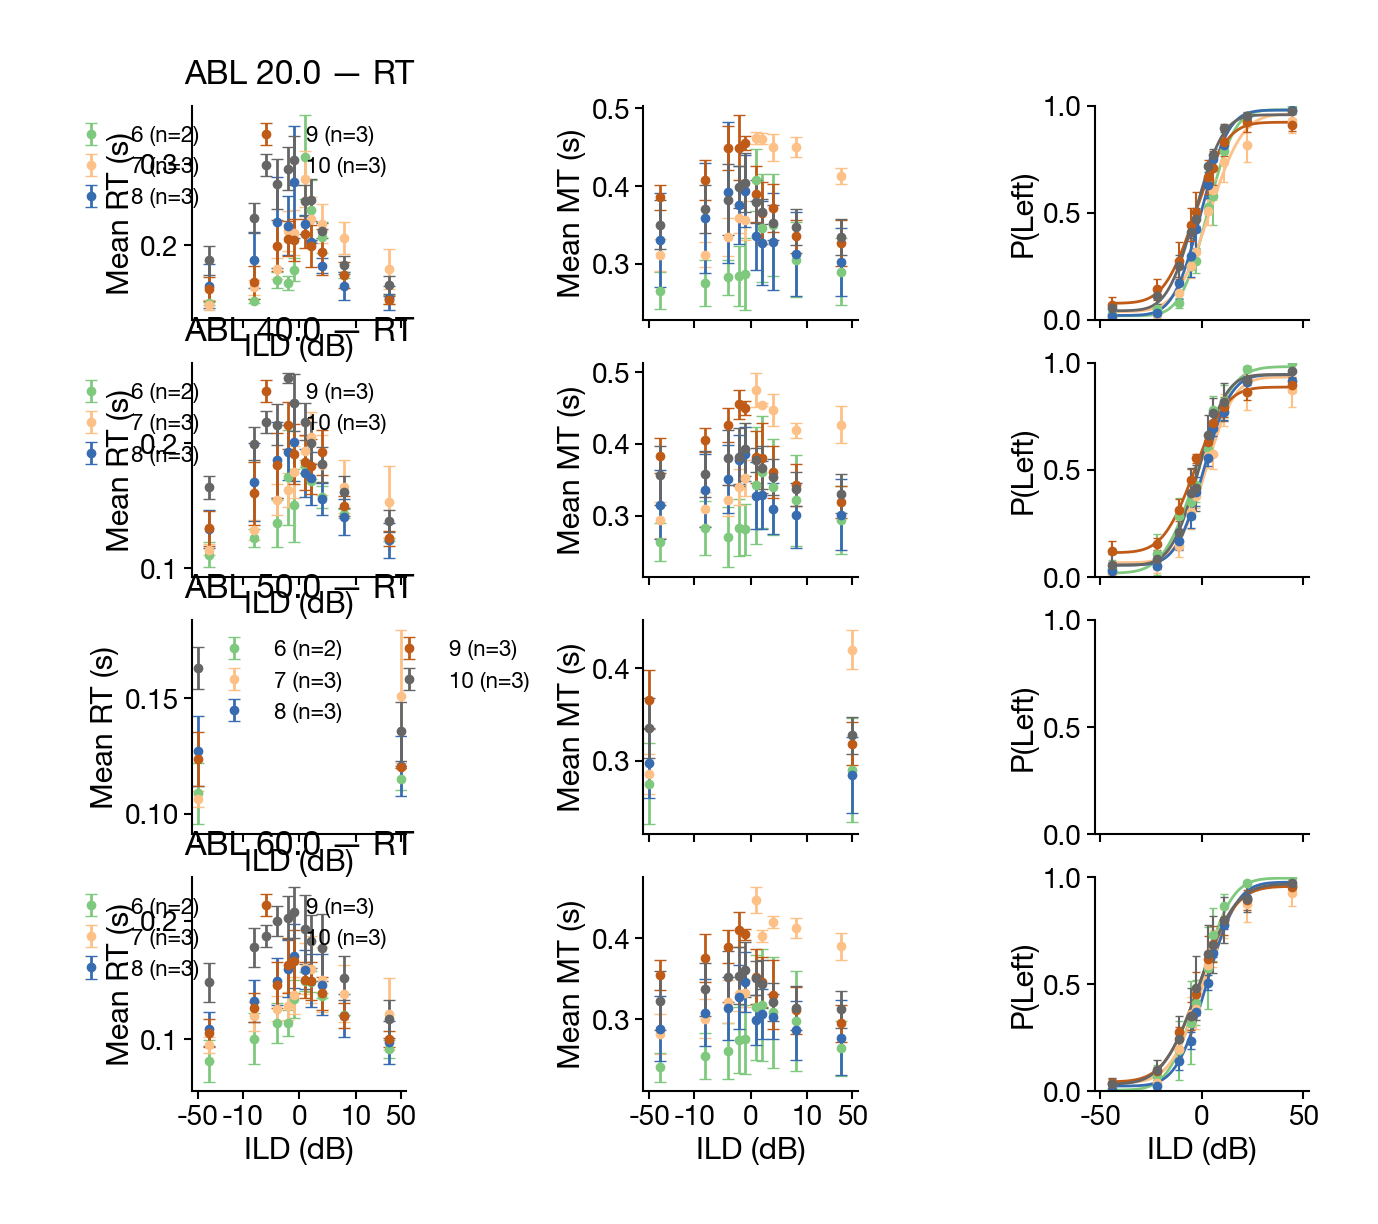

In [ ]:
"""

                                                d8P
                                             d888888P
?88,.d88b, d8888b  88bd88b     .d888b, d8888b  ?88'  ?88   d8P?88,.d88b,
`?88'  ?88d8b_,dP  88P'  `     ?8b,   d8b_,dP  88P   d88   88 `?88'  ?88
  88b  d8P88b     d88            `?8b 88b      88b   ?8(  d88   88b  d8P
  888888P'`?888P'd88'         `?888P' `?888P'  `?8b  `?88P'?8b  888888P'
  88P'                                                          88P'
 d88                                                           d88
 ?8P                                                           ?8P
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import Psychometric
import DataHelpers

"""
=============================================================
 Group-by-Setup Summary — with GroupComparison Aesthetics
=============================================================
"""


# ----- choose a palette -----
# Good categorical options: "Set2", "tab10", "Dark2", "Accent", "tab20", "Paired"
# (continuous but nice: "viridis", "plasma", "turbo")


# ==============================================================
# === CONFIG ===================================================
# ==============================================================
SETUP_COL = "box"
PALETTE = "Accent"
SKIP_PSY_FITS = {50}

TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 2.0

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ==============================================================
# === STYLE HELPERS ============================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent formatting."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_box_aspect(1)



def sem(series):
    n = series.count()
    return series.std(ddof=1) / np.sqrt(n) if n > 0 else np.nan


# ==============================================================
# === LOAD & FILTER DATA =======================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"
df = pd.read_csv(cohort_file)

df = df[df["training_level"] == 16]
df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

if SETUP_COL not in df.columns:
    raise KeyError(f"'{SETUP_COL}' column not found in dataframe.")

mask_false = (
    df["repeated_trial"].astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]

ABLs = sorted(df["ABL"].unique())
setups = sorted(df[SETUP_COL].dropna().unique())

# Color map per setup
cmap = plt.cm.get_cmap(PALETTE)
color_for_setup = {s: cmap(i / max(len(setups) - 1, 1)) for i, s in enumerate(setups)}


# ==============================================================
# === COMPUTE STATS ============================================
# ==============================================================
# --- RT ---
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_rt"]
    .mean()
    .reset_index(name="mean_rt")
)
meanRT_setup = (
    meanRT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_rt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
rt_counts = meanRT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- MT ---
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_mt"]
    .mean()
    .reset_index(name="mean_mt")
)
meanMT_setup = (
    meanMT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_mt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
mt_counts = meanMT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()

# --- Psychometric ---
all_points = []
for (setup, subject), df_ss in df.groupby([SETUP_COL, "animal"]):
    results = Psychometric.compute_psychometrics_by_ABL(df_ss, model="erf_psycho")
    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_points.append({
                SETUP_COL: setup,
                "animal": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

points_df = pd.DataFrame(all_points)
agg_points_setup = (
    points_df
    .groupby([SETUP_COL, "ABL", "ILD"])["PropLeft"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
psy_counts = points_df.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- Fit curves per ABL × setup ---
group_fits = {abl: {} for abl in ABLs}
for abl in ABLs:
    for setup in setups:
        sub = agg_points_setup[(agg_points_setup["ABL"] == abl) & (agg_points_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        ILDs =sub["ILD"]
        PropLeft_mean = sub["mean"].values
        n_trials = np.full_like(ILDs, 50, dtype=float)
        pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
            ILDs, PropLeft_mean, model="erf_psycho", n_trials=n_trials, show_plot=False
        )
        xx = np.linspace(np.min(ILDs), np.max(ILDs), 200)
        group_fits[abl][setup] = {
            "ILDs": ILDs, "mean": PropLeft_mean, "sem": sub["sem"].values,
            "xx": xx, "yy": yy
        }
# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
# Keep each panel compact: ~5.5×3.2 inches per panel
panel_w, panel_h = 5.5, 3.2
fig_height = panel_h * len(ABLs)
fig_width = panel_w * 3
fig, axes = plt.subplots(len(ABLs), 3, figsize=(fig_width, fig_height), sharex="col")

if len(ABLs) == 1:
    axes = np.array([axes])  # ensure 2D for single row

for r, abl in enumerate(ABLs):
    # --- RT ---
    ax = axes[r, 0]
    for setup in setups:
        sub = meanRT_setup[(meanRT_setup["ABL"] == abl) & (meanRT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = rt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, f"ABL {abl} — RT", "ILD (dB)", "Mean RT (s)")

    # --- MT ---
    ax = axes[r, 1]
    for setup in setups:
        sub = meanMT_setup[(meanMT_setup["ABL"] == abl) & (meanMT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = mt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "Mean MT (s)")


    # --- Psychometric ---
    ax = axes[r, 2]
    for setup in setups:
        res = group_fits.get(abl, {}).get(setup, None)
        if res is None:
            continue
        n_subs = psy_counts.get((setup, abl), 0)
        order = np.argsort(res["ILDs"])
        ax.errorbar(
            np.array(res["ILDs"])[order], np.array(res["mean"])[order],
            yerr=np.array(res["sem"])[order],
            fmt="o", color=color_for_setup[setup], capsize=3,
            label=f"{setup} (n={n_subs})" if r == 0 else None
        )
        if abl not in SKIP_PSY_FITS and "xx" in res and "yy" in res:
            ax.plot(res["xx"], res["yy"], color=color_for_setup[setup], linewidth=LINEWIDTH)
    ax.set_ylim(0, 1)
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "P(Left)")

# --- Shared formatting ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else "50" if x == 18 else str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

# --- Legends per row (on RT panels only) ---
for r in range(len(ABLs)):
    axes[r, 0].legend(fontsize=LEGEND_FONTSIZE, ncol=2, frameon=False)
    if axes[r, 1].get_legend(): axes[r, 1].get_legend().remove()
    if axes[r, 2].get_legend(): axes[r, 2].get_legend().remove()


plt.show()

<ipython-input-42-23e70dbea9a4>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)
<ipython-input-42-23e70dbea9a4>:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(PALETTE)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

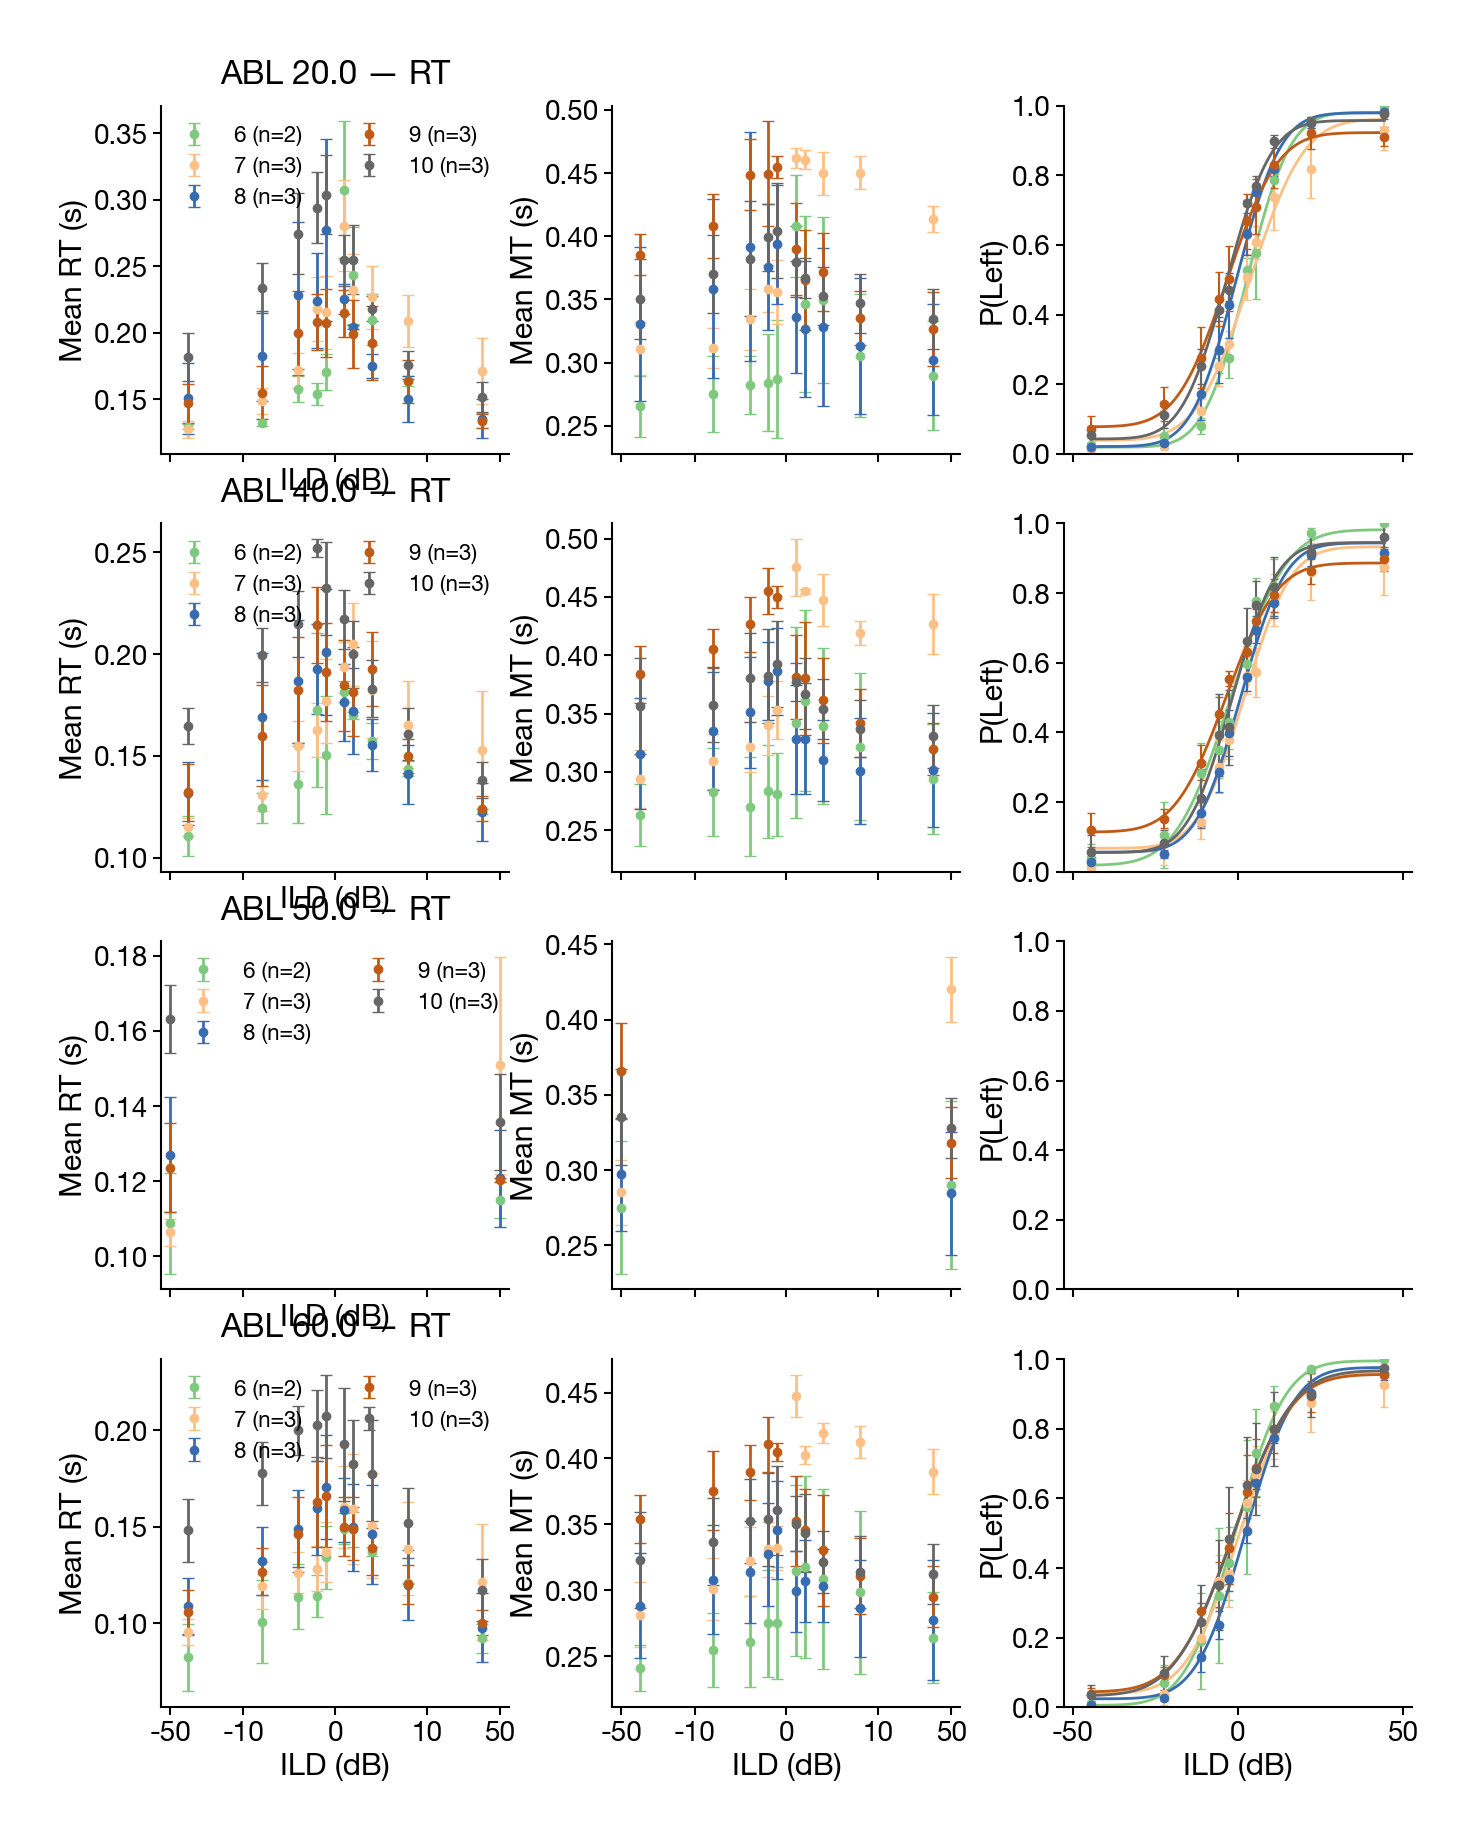

In [ ]:
"""

                                                d8P
                                             d888888P
?88,.d88b, d8888b  88bd88b     .d888b, d8888b  ?88'  ?88   d8P?88,.d88b,
`?88'  ?88d8b_,dP  88P'  `     ?8b,   d8b_,dP  88P   d88   88 `?88'  ?88
  88b  d8P88b     d88            `?8b 88b      88b   ?8(  d88   88b  d8P
  888888P'`?888P'd88'         `?888P' `?888P'  `?8b  `?88P'?8b  888888P'
  88P'                                                          88P'
 d88                                                           d88
 ?8P                                                           ?8P
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import Psychometric
import DataHelpers

"""
=============================================================
 Group-by-Setup Summary — with GroupComparison Aesthetics
=============================================================
"""


# ----- choose a palette -----
# Good categorical options: "Set2", "tab10", "Dark2", "Accent", "tab20", "Paired"
# (continuous but nice: "viridis", "plasma", "turbo")


# ==============================================================
# === CONFIG ===================================================
# ==============================================================
SETUP_COL = "box"
PALETTE = "Accent"
SKIP_PSY_FITS = {50}

TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 2.0

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ==============================================================
# === STYLE HELPERS ============================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent formatting."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_box_aspect(1)



def sem(series):
    n = series.count()
    return series.std(ddof=1) / np.sqrt(n) if n > 0 else np.nan


# ==============================================================
# === LOAD & FILTER DATA =======================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"
df = pd.read_csv(cohort_file)

df = df[df["training_level"] == 16]
df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

if SETUP_COL not in df.columns:
    raise KeyError(f"'{SETUP_COL}' column not found in dataframe.")

mask_false = (
    df["repeated_trial"].astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]

ABLs = sorted(df["ABL"].unique())
setups = sorted(df[SETUP_COL].dropna().unique())

# Color map per setup
cmap = plt.cm.get_cmap(PALETTE)
color_for_setup = {s: cmap(i / max(len(setups) - 1, 1)) for i, s in enumerate(setups)}


# ==============================================================
# === COMPUTE STATS ============================================
# ==============================================================
# --- RT ---
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_rt"]
    .mean()
    .reset_index(name="mean_rt")
)
meanRT_setup = (
    meanRT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_rt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
rt_counts = meanRT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- MT ---
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_mt"]
    .mean()
    .reset_index(name="mean_mt")
)
meanMT_setup = (
    meanMT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_mt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
mt_counts = meanMT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()

# --- Psychometric ---
all_points = []
for (setup, subject), df_ss in df.groupby([SETUP_COL, "animal"]):
    results = Psychometric.compute_psychometrics_by_ABL(df_ss, model="erf_psycho")
    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_points.append({
                SETUP_COL: setup,
                "animal": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

points_df = pd.DataFrame(all_points)
agg_points_setup = (
    points_df
    .groupby([SETUP_COL, "ABL", "ILD"])["PropLeft"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
psy_counts = points_df.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- Fit curves per ABL × setup ---
group_fits = {abl: {} for abl in ABLs}
for abl in ABLs:
    for setup in setups:
        sub = agg_points_setup[(agg_points_setup["ABL"] == abl) & (agg_points_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        ILDs =sub["ILD"]
        PropLeft_mean = sub["mean"].values
        n_trials = np.full_like(ILDs, 50, dtype=float)
        pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
            ILDs, PropLeft_mean, model="erf_psycho", n_trials=n_trials, show_plot=False
        )
        xx = np.linspace(np.min(ILDs), np.max(ILDs), 200)
        group_fits[abl][setup] = {
            "ILDs": ILDs, "mean": PropLeft_mean, "sem": sub["sem"].values,
            "xx": xx, "yy": yy
        }
# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
# Keep each panel compact: ~5.5×3.2 inches per panel
panel_w, panel_h = 5.5, 5.2
fig_height = panel_h * len(ABLs)
fig_width = panel_w * 3
fig, axes = plt.subplots(len(ABLs), 3, figsize=(fig_width, fig_height), sharex="col")

if len(ABLs) == 1:
    axes = np.array([axes])  # ensure 2D for single row

for r, abl in enumerate(ABLs):
    # --- RT ---
    ax = axes[r, 0]
    for setup in setups:
        sub = meanRT_setup[(meanRT_setup["ABL"] == abl) & (meanRT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = rt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, f"ABL {abl} — RT", "ILD (dB)", "Mean RT (s)")

    # --- MT ---
    ax = axes[r, 1]
    for setup in setups:
        sub = meanMT_setup[(meanMT_setup["ABL"] == abl) & (meanMT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = mt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "Mean MT (s)")


    # --- Psychometric ---
    ax = axes[r, 2]
    for setup in setups:
        res = group_fits.get(abl, {}).get(setup, None)
        if res is None:
            continue
        n_subs = psy_counts.get((setup, abl), 0)
        order = np.argsort(res["ILDs"])
        ax.errorbar(
            np.array(res["ILDs"])[order], np.array(res["mean"])[order],
            yerr=np.array(res["sem"])[order],
            fmt="o", color=color_for_setup[setup], capsize=3,
            label=f"{setup} (n={n_subs})" if r == 0 else None
        )
        if abl not in SKIP_PSY_FITS and "xx" in res and "yy" in res:
            ax.plot(res["xx"], res["yy"], color=color_for_setup[setup], linewidth=LINEWIDTH)
    ax.set_ylim(0, 1)
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "P(Left)")

# --- Shared formatting ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else "50" if x == 18 else str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

# --- Legends per row (on RT panels only) ---
for r in range(len(ABLs)):
    axes[r, 0].legend(fontsize=LEGEND_FONTSIZE, ncol=2, frameon=False)
    if axes[r, 1].get_legend(): axes[r, 1].get_legend().remove()
    if axes[r, 2].get_legend(): axes[r, 2].get_legend().remove()


plt.show()

<ipython-input-43-fe9f2947ec4f>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)
<ipython-input-43-fe9f2947ec4f>:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(PALETTE)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

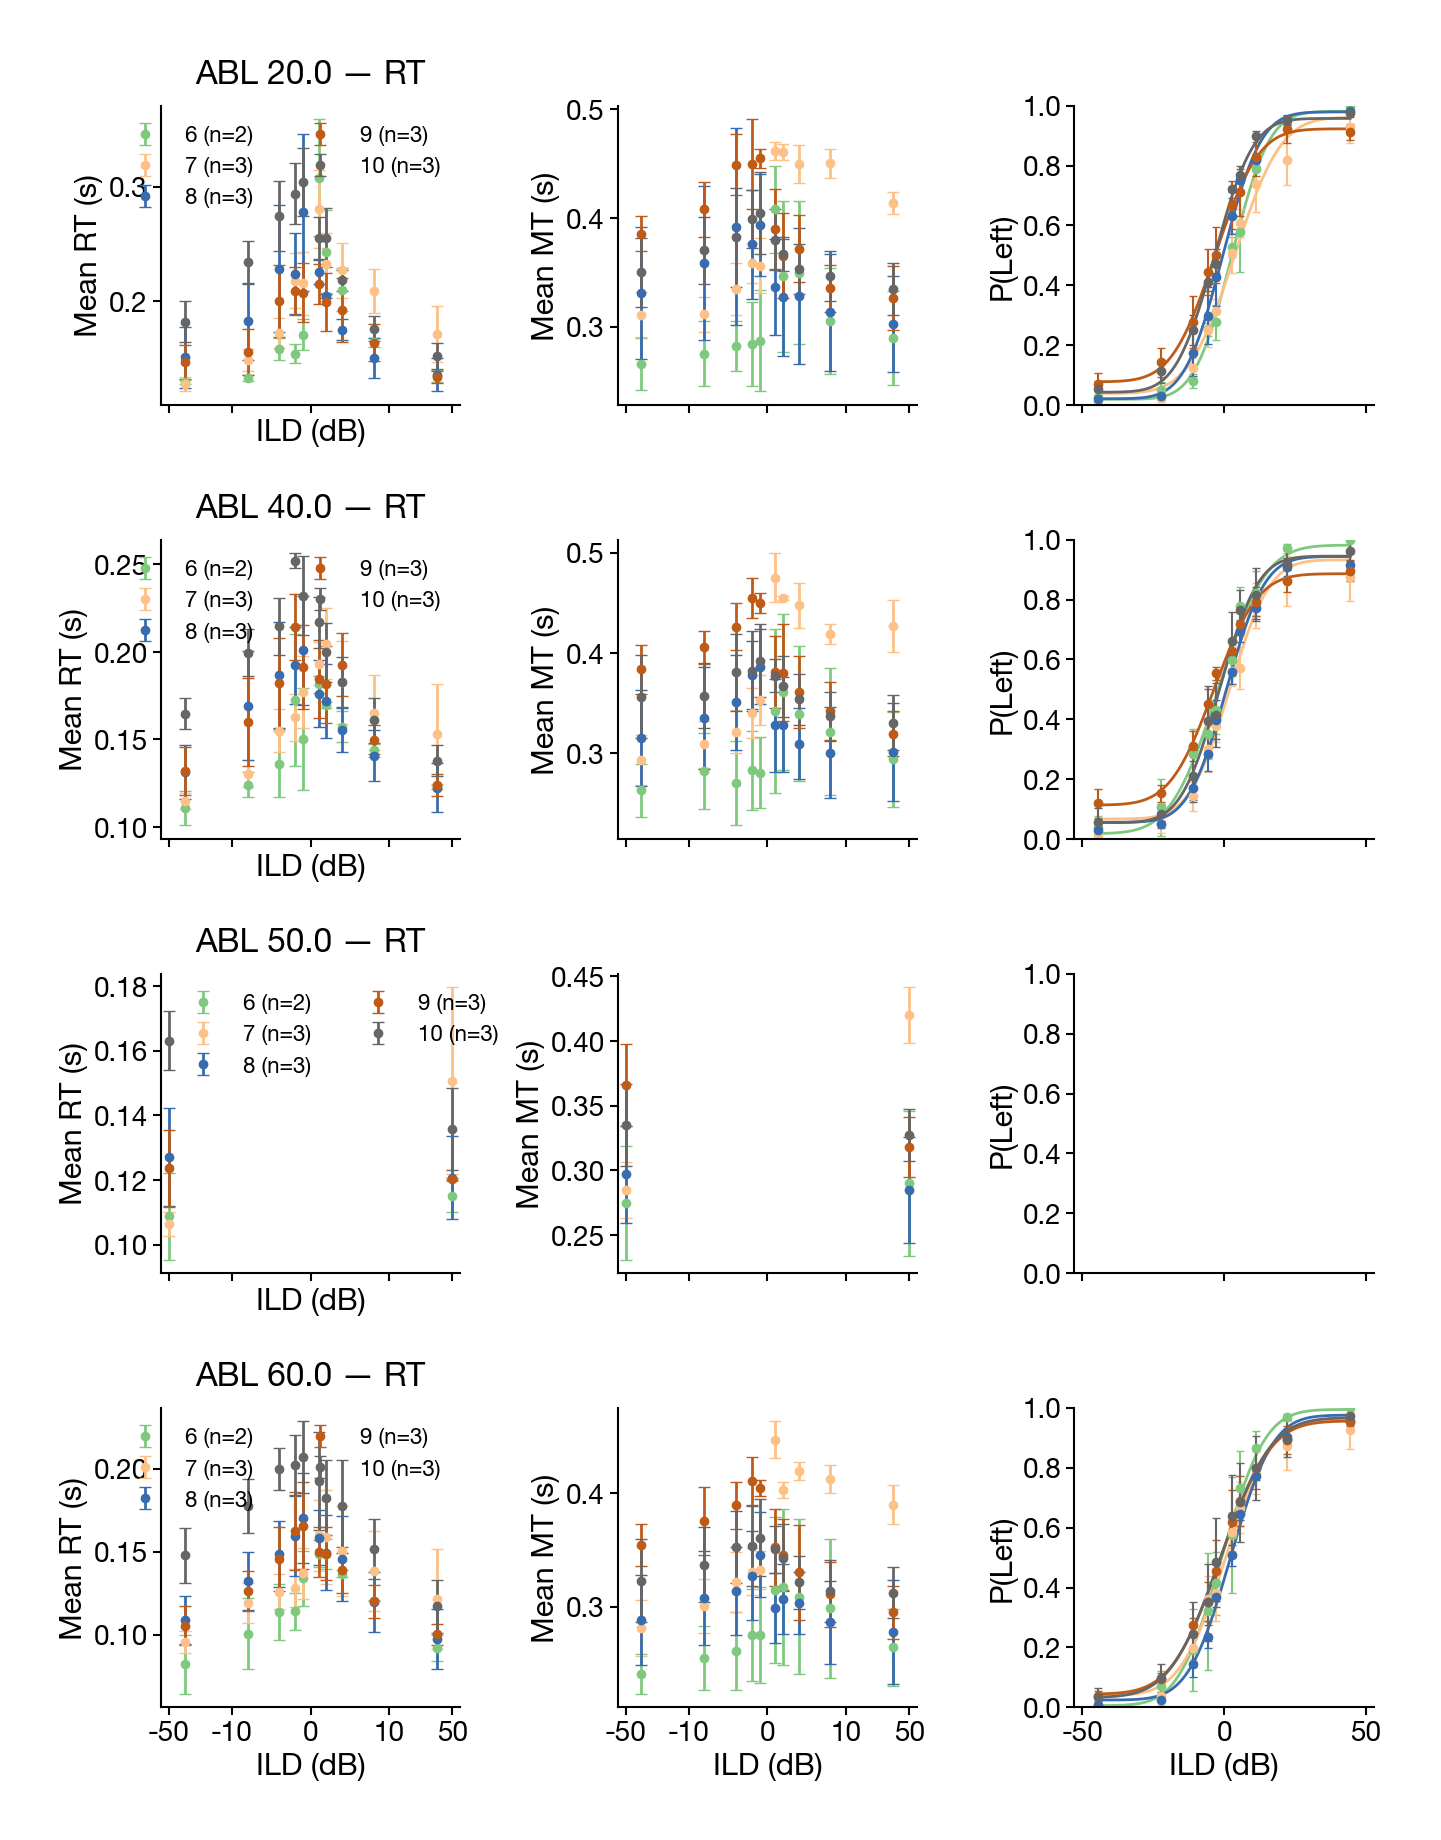

In [ ]:
"""

                                                d8P
                                             d888888P
?88,.d88b, d8888b  88bd88b     .d888b, d8888b  ?88'  ?88   d8P?88,.d88b,
`?88'  ?88d8b_,dP  88P'  `     ?8b,   d8b_,dP  88P   d88   88 `?88'  ?88
  88b  d8P88b     d88            `?8b 88b      88b   ?8(  d88   88b  d8P
  888888P'`?888P'd88'         `?888P' `?888P'  `?8b  `?88P'?8b  888888P'
  88P'                                                          88P'
 d88                                                           d88
 ?8P                                                           ?8P
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import Psychometric
import DataHelpers

"""
=============================================================
 Group-by-Setup Summary — with GroupComparison Aesthetics
=============================================================
"""


# ----- choose a palette -----
# Good categorical options: "Set2", "tab10", "Dark2", "Accent", "tab20", "Paired"
# (continuous but nice: "viridis", "plasma", "turbo")


# ==============================================================
# === CONFIG ===================================================
# ==============================================================
SETUP_COL = "box"
PALETTE = "Accent"
SKIP_PSY_FITS = {50}

TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 2.0

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ==============================================================
# === STYLE HELPERS ============================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent formatting."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_box_aspect(1)



def sem(series):
    n = series.count()
    return series.std(ddof=1) / np.sqrt(n) if n > 0 else np.nan


# ==============================================================
# === LOAD & FILTER DATA =======================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"
df = pd.read_csv(cohort_file)

df = df[df["training_level"] == 16]
df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

if SETUP_COL not in df.columns:
    raise KeyError(f"'{SETUP_COL}' column not found in dataframe.")

mask_false = (
    df["repeated_trial"].astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]

ABLs = sorted(df["ABL"].unique())
setups = sorted(df[SETUP_COL].dropna().unique())

# Color map per setup
cmap = plt.cm.get_cmap(PALETTE)
color_for_setup = {s: cmap(i / max(len(setups) - 1, 1)) for i, s in enumerate(setups)}


# ==============================================================
# === COMPUTE STATS ============================================
# ==============================================================
# --- RT ---
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_rt"]
    .mean()
    .reset_index(name="mean_rt")
)
meanRT_setup = (
    meanRT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_rt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
rt_counts = meanRT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- MT ---
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_mt"]
    .mean()
    .reset_index(name="mean_mt")
)
meanMT_setup = (
    meanMT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_mt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
mt_counts = meanMT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()

# --- Psychometric ---
all_points = []
for (setup, subject), df_ss in df.groupby([SETUP_COL, "animal"]):
    results = Psychometric.compute_psychometrics_by_ABL(df_ss, model="erf_psycho")
    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_points.append({
                SETUP_COL: setup,
                "animal": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

points_df = pd.DataFrame(all_points)
agg_points_setup = (
    points_df
    .groupby([SETUP_COL, "ABL", "ILD"])["PropLeft"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
psy_counts = points_df.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- Fit curves per ABL × setup ---
group_fits = {abl: {} for abl in ABLs}
for abl in ABLs:
    for setup in setups:
        sub = agg_points_setup[(agg_points_setup["ABL"] == abl) & (agg_points_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        ILDs =sub["ILD"]
        PropLeft_mean = sub["mean"].values
        n_trials = np.full_like(ILDs, 50, dtype=float)
        pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
            ILDs, PropLeft_mean, model="erf_psycho", n_trials=n_trials, show_plot=False
        )
        xx = np.linspace(np.min(ILDs), np.max(ILDs), 200)
        group_fits[abl][setup] = {
            "ILDs": ILDs, "mean": PropLeft_mean, "sem": sub["sem"].values,
            "xx": xx, "yy": yy
        }
# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
# Keep each panel compact: ~5.5×3.2 inches per panel
panel_w, panel_h = 5.5, 5.2
fig_height = panel_h * len(ABLs)
fig_width = panel_w * 3
fig, axes = plt.subplots(len(ABLs), 3, figsize=(fig_width, fig_height), sharex="col")

if len(ABLs) == 1:
    axes = np.array([axes])  # ensure 2D for single row

for r, abl in enumerate(ABLs):
    # --- RT ---
    ax = axes[r, 0]
    for setup in setups:
        sub = meanRT_setup[(meanRT_setup["ABL"] == abl) & (meanRT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = rt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, f"ABL {abl} — RT", "ILD (dB)", "Mean RT (s)")

    # --- MT ---
    ax = axes[r, 1]
    for setup in setups:
        sub = meanMT_setup[(meanMT_setup["ABL"] == abl) & (meanMT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = mt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "Mean MT (s)")


    # --- Psychometric ---
    ax = axes[r, 2]
    for setup in setups:
        res = group_fits.get(abl, {}).get(setup, None)
        if res is None:
            continue
        n_subs = psy_counts.get((setup, abl), 0)
        order = np.argsort(res["ILDs"])
        ax.errorbar(
            np.array(res["ILDs"])[order], np.array(res["mean"])[order],
            yerr=np.array(res["sem"])[order],
            fmt="o", color=color_for_setup[setup], capsize=3,
            label=f"{setup} (n={n_subs})" if r == 0 else None
        )
        if abl not in SKIP_PSY_FITS and "xx" in res and "yy" in res:
            ax.plot(res["xx"], res["yy"], color=color_for_setup[setup], linewidth=LINEWIDTH)
    ax.set_ylim(0, 1)
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "P(Left)")

# --- Shared formatting ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else "50" if x == 18 else str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

# --- Legends per row (on RT panels only) ---
for r in range(len(ABLs)):
    axes[r, 0].legend(fontsize=LEGEND_FONTSIZE, ncol=2, frameon=False)
    if axes[r, 1].get_legend(): axes[r, 1].get_legend().remove()
    if axes[r, 2].get_legend(): axes[r, 2].get_legend().remove()

# Adjust spacing between subplot rows and columns
plt.subplots_adjust(
    hspace=0.45,  # vertical space between rows (↑ this to increase separation)
    wspace=0.25   # horizontal spacing between columns
)
plt.show()


plt.show()

<ipython-input-44-4f9fd6b232f8>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)
<ipython-input-44-4f9fd6b232f8>:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(PALETTE)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

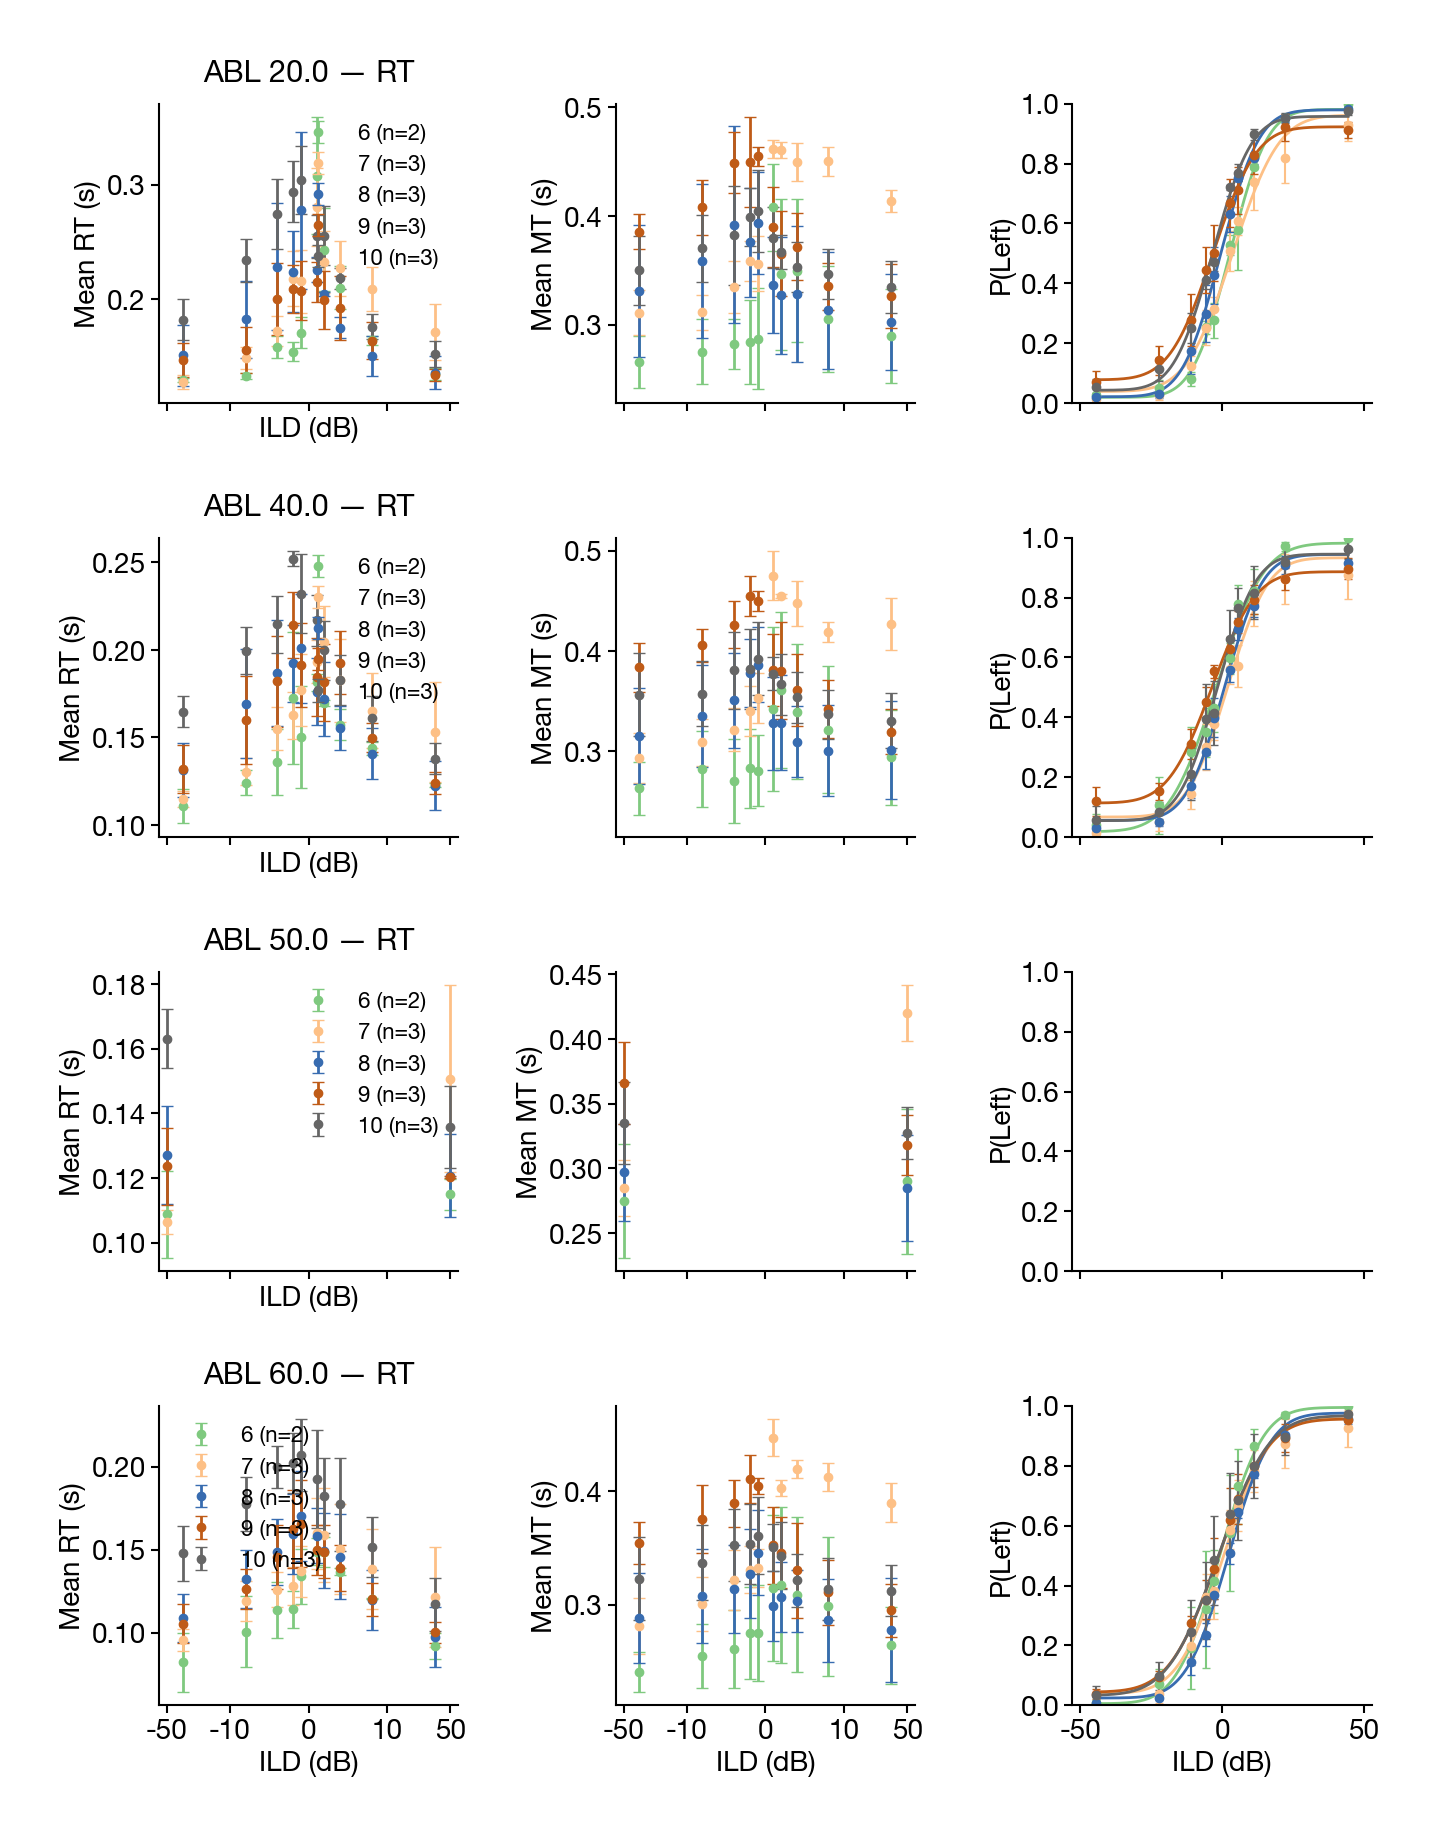

In [ ]:
"""

                                                d8P
                                             d888888P
?88,.d88b, d8888b  88bd88b     .d888b, d8888b  ?88'  ?88   d8P?88,.d88b,
`?88'  ?88d8b_,dP  88P'  `     ?8b,   d8b_,dP  88P   d88   88 `?88'  ?88
  88b  d8P88b     d88            `?8b 88b      88b   ?8(  d88   88b  d8P
  888888P'`?888P'd88'         `?888P' `?888P'  `?8b  `?88P'?8b  888888P'
  88P'                                                          88P'
 d88                                                           d88
 ?8P                                                           ?8P
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import Psychometric
import DataHelpers

"""
=============================================================
 Group-by-Setup Summary — with GroupComparison Aesthetics
=============================================================
"""


# ----- choose a palette -----
# Good categorical options: "Set2", "tab10", "Dark2", "Accent", "tab20", "Paired"
# (continuous but nice: "viridis", "plasma", "turbo")


# ==============================================================
# === CONFIG ===================================================
# ==============================================================
SETUP_COL = "box"
PALETTE = "Accent"
SKIP_PSY_FITS = {50}

TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 20
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 2.0

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ==============================================================
# === STYLE HELPERS ============================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent formatting."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_box_aspect(1)



def sem(series):
    n = series.count()
    return series.std(ddof=1) / np.sqrt(n) if n > 0 else np.nan


# ==============================================================
# === LOAD & FILTER DATA =======================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"
df = pd.read_csv(cohort_file)

df = df[df["training_level"] == 16]
df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

if SETUP_COL not in df.columns:
    raise KeyError(f"'{SETUP_COL}' column not found in dataframe.")

mask_false = (
    df["repeated_trial"].astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]

ABLs = sorted(df["ABL"].unique())
setups = sorted(df[SETUP_COL].dropna().unique())

# Color map per setup
cmap = plt.cm.get_cmap(PALETTE)
color_for_setup = {s: cmap(i / max(len(setups) - 1, 1)) for i, s in enumerate(setups)}


# ==============================================================
# === COMPUTE STATS ============================================
# ==============================================================
# --- RT ---
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_rt"]
    .mean()
    .reset_index(name="mean_rt")
)
meanRT_setup = (
    meanRT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_rt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
rt_counts = meanRT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- MT ---
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_mt"]
    .mean()
    .reset_index(name="mean_mt")
)
meanMT_setup = (
    meanMT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_mt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
mt_counts = meanMT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()

# --- Psychometric ---
all_points = []
for (setup, subject), df_ss in df.groupby([SETUP_COL, "animal"]):
    results = Psychometric.compute_psychometrics_by_ABL(df_ss, model="erf_psycho")
    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_points.append({
                SETUP_COL: setup,
                "animal": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

points_df = pd.DataFrame(all_points)
agg_points_setup = (
    points_df
    .groupby([SETUP_COL, "ABL", "ILD"])["PropLeft"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
psy_counts = points_df.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- Fit curves per ABL × setup ---
group_fits = {abl: {} for abl in ABLs}
for abl in ABLs:
    for setup in setups:
        sub = agg_points_setup[(agg_points_setup["ABL"] == abl) & (agg_points_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        ILDs =sub["ILD"]
        PropLeft_mean = sub["mean"].values
        n_trials = np.full_like(ILDs, 50, dtype=float)
        pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
            ILDs, PropLeft_mean, model="erf_psycho", n_trials=n_trials, show_plot=False
        )
        xx = np.linspace(np.min(ILDs), np.max(ILDs), 200)
        group_fits[abl][setup] = {
            "ILDs": ILDs, "mean": PropLeft_mean, "sem": sub["sem"].values,
            "xx": xx, "yy": yy
        }
# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
# Keep each panel compact: ~5.5×3.2 inches per panel
panel_w, panel_h = 5.5, 5.2
fig_height = panel_h * len(ABLs)
fig_width = panel_w * 3
fig, axes = plt.subplots(len(ABLs), 3, figsize=(fig_width, fig_height), sharex="col")

if len(ABLs) == 1:
    axes = np.array([axes])  # ensure 2D for single row

for r, abl in enumerate(ABLs):
    # --- RT ---
    ax = axes[r, 0]
    for setup in setups:
        sub = meanRT_setup[(meanRT_setup["ABL"] == abl) & (meanRT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = rt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, f"ABL {abl} — RT", "ILD (dB)", "Mean RT (s)")

    # --- MT ---
    ax = axes[r, 1]
    for setup in setups:
        sub = meanMT_setup[(meanMT_setup["ABL"] == abl) & (meanMT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = mt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "Mean MT (s)")


    # --- Psychometric ---
    ax = axes[r, 2]
    for setup in setups:
        res = group_fits.get(abl, {}).get(setup, None)
        if res is None:
            continue
        n_subs = psy_counts.get((setup, abl), 0)
        order = np.argsort(res["ILDs"])
        ax.errorbar(
            np.array(res["ILDs"])[order], np.array(res["mean"])[order],
            yerr=np.array(res["sem"])[order],
            fmt="o", color=color_for_setup[setup], capsize=3,
            label=f"{setup} (n={n_subs})" if r == 0 else None
        )
        if abl not in SKIP_PSY_FITS and "xx" in res and "yy" in res:
            ax.plot(res["xx"], res["yy"], color=color_for_setup[setup], linewidth=LINEWIDTH)
    ax.set_ylim(0, 1)
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "P(Left)")

# --- Shared formatting ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else "50" if x == 18 else str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

# --- Legends per row (on RT panels only) ---
for r in range(len(ABLs)):
    axes[r, 0].legend(fontsize=LEGEND_FONTSIZE, ncol=1, frameon=False)
    if axes[r, 1].get_legend(): axes[r, 1].get_legend().remove()
    if axes[r, 2].get_legend(): axes[r, 2].get_legend().remove()

# Adjust spacing between subplot rows and columns
plt.subplots_adjust(
    hspace=0.45,  # vertical space between rows (↑ this to increase separation)
    wspace=0.25   # horizontal spacing between columns
)
plt.show()


plt.show()

<ipython-input-45-33f59447f7f8>:92: DtypeWarning: Columns (70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cohort_file)
<ipython-input-45-33f59447f7f8>:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(PALETTE)



ABL=20.0, n_trials=989
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.05102041 0.07526882 0.10344828 0.2745098  0.33333333 0.5625
 0.70930233 0.78021978 0.95454545 1.        ]
n_trials: [ 98  93 116 102  99  96  86  91 110  98]

ABL=40.0, n_trials=970
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.07843137 0.2        0.36893204 0.43269231 0.51086957 0.64772727
 0.84375    0.89655172 0.98701299 1.        ]
n_trials: [102  95 103 104  92  88  96  87  77 126]

ABL=50.0, n_trials=159
  ILDs: [-50.  50.]
ILDs: [-50.  50.]
PropLeft: [0.01204819 1.        ]
n_trials: [83 76]

ABL=60.0, n_trials=1037
  ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
ILDs: [-16.  -8.  -4.  -2.  -1.   1.   2.   4.   8.  16.]
PropLeft: [0.01785714 0.12087912 0.3271028  0.51456311 0.51886792 0.76842105
 0.85576923 0.9223301  0.97959184 1.

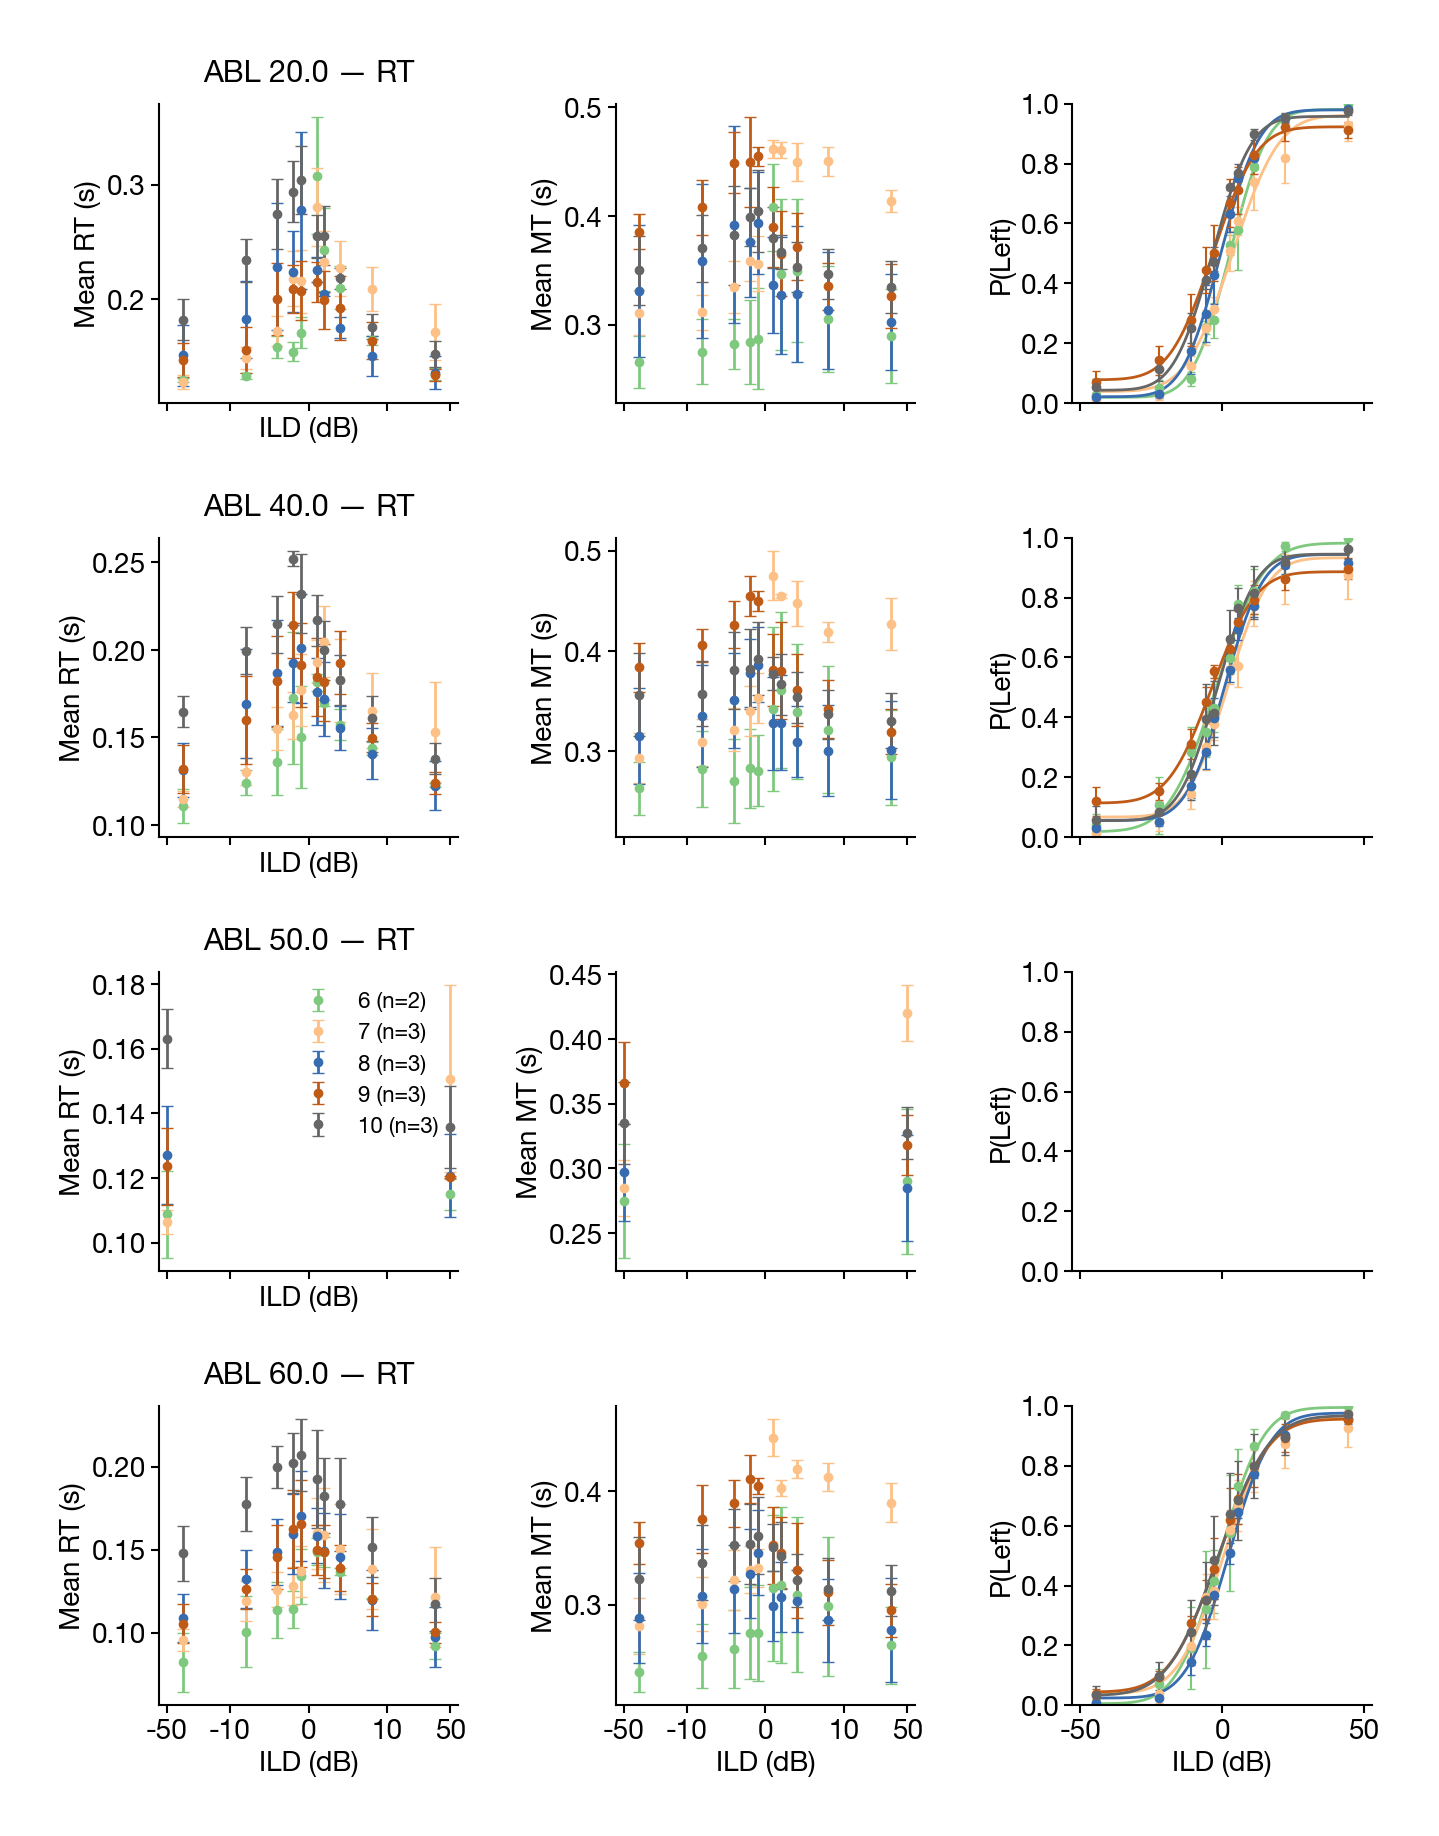

In [ ]:
"""

                                                d8P
                                             d888888P
?88,.d88b, d8888b  88bd88b     .d888b, d8888b  ?88'  ?88   d8P?88,.d88b,
`?88'  ?88d8b_,dP  88P'  `     ?8b,   d8b_,dP  88P   d88   88 `?88'  ?88
  88b  d8P88b     d88            `?8b 88b      88b   ?8(  d88   88b  d8P
  888888P'`?888P'd88'         `?888P' `?888P'  `?8b  `?88P'?8b  888888P'
  88P'                                                          88P'
 d88                                                           d88
 ?8P                                                           ?8P
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import Psychometric
import DataHelpers

"""
=============================================================
 Group-by-Setup Summary — with GroupComparison Aesthetics
=============================================================
"""


# ----- choose a palette -----
# Good categorical options: "Set2", "tab10", "Dark2", "Accent", "tab20", "Paired"
# (continuous but nice: "viridis", "plasma", "turbo")


# ==============================================================
# === CONFIG ===================================================
# ==============================================================
SETUP_COL = "box"
PALETTE = "Accent"
SKIP_PSY_FITS = {50}

TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 20
TICK_FONTSIZE  = 20
LEGEND_FONTSIZE = 16
TITLE_PAD = 16
LINEWIDTH = 2.0

mpl.rcParams.update({
    "savefig.pad_inches": 0.6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ==============================================================
# === STYLE HELPERS ============================================
# ==============================================================
def _style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent formatting."""
    if title:
        ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, color="black")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color="black")

    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE,
                   colors="black", width=1.5, length=6)
    for s in ["left", "bottom", "right", "top"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_box_aspect(1)



def sem(series):
    n = series.count()
    return series.std(ddof=1) / np.sqrt(n) if n > 0 else np.nan


# ==============================================================
# === LOAD & FILTER DATA =======================================
# ==============================================================
os.chdir("/Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/ASD_cohort2")
cohort_file = "merged_all_subjects.csv"
df = pd.read_csv(cohort_file)

df = df[df["training_level"] == 16]
df.loc[df["ABL"] == 59, "ABL"] = 60
df.loc[(df["training_level"] == 16) & (df["ABL"] == 25), "ABL"] = 50
df = df[df["session"] >= 13]

if SETUP_COL not in df.columns:
    raise KeyError(f"'{SETUP_COL}' column not found in dataframe.")

mask_false = (
    df["repeated_trial"].astype(str)
      .str.strip()
      .str.upper()
      .eq("FALSE")
)
df = df[mask_false]

ABLs = sorted(df["ABL"].unique())
setups = sorted(df[SETUP_COL].dropna().unique())

# Color map per setup
cmap = plt.cm.get_cmap(PALETTE)
color_for_setup = {s: cmap(i / max(len(setups) - 1, 1)) for i, s in enumerate(setups)}


# ==============================================================
# === COMPUTE STATS ============================================
# ==============================================================
# --- RT ---
meanRT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_rt"]
    .mean()
    .reset_index(name="mean_rt")
)
meanRT_setup = (
    meanRT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_rt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
rt_counts = meanRT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- MT ---
meanMT_per_subject = (
    df[df["success"] == 1]
    .groupby([SETUP_COL, "animal", "ABL", "ILD"])["timed_mt"]
    .mean()
    .reset_index(name="mean_mt")
)
meanMT_setup = (
    meanMT_per_subject
    .groupby([SETUP_COL, "ABL", "ILD"])["mean_mt"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
mt_counts = meanMT_per_subject.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()

# --- Psychometric ---
all_points = []
for (setup, subject), df_ss in df.groupby([SETUP_COL, "animal"]):
    results = Psychometric.compute_psychometrics_by_ABL(df_ss, model="erf_psycho")
    for abl, res in results.items():
        for ild, pleft in zip(res["ILDs"], res["PropLeft"]):
            all_points.append({
                SETUP_COL: setup,
                "animal": subject,
                "ABL": abl,
                "ILD": ild,
                "PropLeft": pleft
            })

points_df = pd.DataFrame(all_points)
agg_points_setup = (
    points_df
    .groupby([SETUP_COL, "ABL", "ILD"])["PropLeft"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
psy_counts = points_df.groupby([SETUP_COL, "ABL"])["animal"].nunique().to_dict()


# --- Fit curves per ABL × setup ---
group_fits = {abl: {} for abl in ABLs}
for abl in ABLs:
    for setup in setups:
        sub = agg_points_setup[(agg_points_setup["ABL"] == abl) & (agg_points_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        ILDs =sub["ILD"]
        PropLeft_mean = sub["mean"].values
        n_trials = np.full_like(ILDs, 50, dtype=float)
        pars, L, xx, yy = Psychometric.fit_and_plot_psychometric(
            ILDs, PropLeft_mean, model="erf_psycho", n_trials=n_trials, show_plot=False
        )
        xx = np.linspace(np.min(ILDs), np.max(ILDs), 200)
        group_fits[abl][setup] = {
            "ILDs": ILDs, "mean": PropLeft_mean, "sem": sub["sem"].values,
            "xx": xx, "yy": yy
        }
# ==============================================================
# === PLOTTING ==================================================
# ==============================================================
# Keep each panel compact: ~5.5×3.2 inches per panel
panel_w, panel_h = 5.5, 5.2
fig_height = panel_h * len(ABLs)
fig_width = panel_w * 3
fig, axes = plt.subplots(len(ABLs), 3, figsize=(fig_width, fig_height), sharex="col")

if len(ABLs) == 1:
    axes = np.array([axes])  # ensure 2D for single row

for r, abl in enumerate(ABLs):
    # --- RT ---
    ax = axes[r, 0]
    for setup in setups:
        sub = meanRT_setup[(meanRT_setup["ABL"] == abl) & (meanRT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = rt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, f"ABL {abl} — RT", "ILD (dB)", "Mean RT (s)")

    # --- MT ---
    ax = axes[r, 1]
    for setup in setups:
        sub = meanMT_setup[(meanMT_setup["ABL"] == abl) & (meanMT_setup[SETUP_COL] == setup)]
        if sub.empty:
            continue
        n_subs = mt_counts.get((setup, abl), 0)
        sub = sub.sort_values("ILD")
        ax.errorbar(
            DataHelpers.shift_ILD_for_ABL50(sub["ILD"]), sub["mean"], yerr=sub["sem"],
            label=f"{setup} (n={n_subs})",
            color=color_for_setup[setup], linestyle="none",
            marker="o", capsize=4, linewidth=LINEWIDTH
        )
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "Mean MT (s)")


    # --- Psychometric ---
    ax = axes[r, 2]
    for setup in setups:
        res = group_fits.get(abl, {}).get(setup, None)
        if res is None:
            continue
        n_subs = psy_counts.get((setup, abl), 0)
        order = np.argsort(res["ILDs"])
        ax.errorbar(
            np.array(res["ILDs"])[order], np.array(res["mean"])[order],
            yerr=np.array(res["sem"])[order],
            fmt="o", color=color_for_setup[setup], capsize=3,
            label=f"{setup} (n={n_subs})" if r == 0 else None
        )
        if abl not in SKIP_PSY_FITS and "xx" in res and "yy" in res:
            ax.plot(res["xx"], res["yy"], color=color_for_setup[setup], linewidth=LINEWIDTH)
    ax.set_ylim(0, 1)
    _style_axes(ax, None, "ILD (dB)" if r == len(ABLs) - 1 else None, "P(Left)")

# --- Shared formatting ---
for ax in axes.flatten():
    xticks = sorted(set(ax.get_xticks()) | {-18, 18})
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        "-50" if x == -18 else "50" if x == 18 else str(int(x))
        for x in xticks
    ])
    ax.set_xlim(-19, 19)

# --- Legend only for ABL = 50 (on RT panel) ---
for r, abl in enumerate(ABLs):
    if abl == 50:
        axes[r, 0].legend(fontsize=LEGEND_FONTSIZE, ncol=1, frameon=False)
    else:
        if axes[r, 0].get_legend(): axes[r, 0].get_legend().remove()
    if axes[r, 1].get_legend(): axes[r, 1].get_legend().remove()
    if axes[r, 2].get_legend(): axes[r, 2].get_legend().remove()


# Adjust spacing between subplot rows and columns
plt.subplots_adjust(
    hspace=0.45,  # vertical space between rows (↑ this to increase separation)
    wspace=0.25   # horizontal spacing between columns
)
plt.show()


plt.show()